In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
#    (used only to generate synthetic data)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)  # 4 points per day over 24 days
#  observation times
t_obs = torch.linspace(0.0, 6.0, numpts, device=device)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Differentiable RK4 ODE solver
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    """
    Integrate y' = f(t,y) over time grid t using RK4.
    y0 shape: (batch, dim) or (dim,)
    returns: tensor of shape (len(t), ...) matching y0
    """
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


# ============================================================
# 3. Simulate observed data from the true system
# ============================================================
with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)  # (1,1)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs)         # (T,1,1)
    y_true = y_true.squeeze(1)                                           # (T,1)

# Synthetic observation noise
torch.manual_seed(2)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true 

# ------------------------------------------------------------
# Enforce the initial condition: first data point is exact truth
# ------------------------------------------------------------
y0_fixed = y_data[0:1].detach().clone()   # shape (1,1), fixed IC


# ============================================================
# 4. UDE model: FULL NN RHS ONLY
#    dN/dt = NN(N)
# ============================================================
class ResidualNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, y):
        return self.net(y)


class UDEFunc(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.rhs_net = ResidualNet(hidden_dim=hidden_dim)

    def forward(self, t, y):
        return self.rhs_net(y)


# ============================================================
# 5. Helpers
# ============================================================
def mean_and_ci(arr, ci=1.96):
    """
    arr shape: (n_runs, n_points)
    returns mean, lower, upper
    """
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lower = mean.copy()
        upper = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lower = mean - ci * sem
        upper = mean + ci * sem
    return mean, lower, upper


def detach_numpy(x):
    return x.detach().cpu().numpy()


def mse_loss(y_pred, y_obs):
    return torch.mean((y_pred - y_obs) ** 2)


# ============================================================
# 6. Multi-split experiment settings
# ============================================================
n_splits = 3
val_fraction = 0.2

n_epochs = 1000
learning_rate = 1e-3

lambda_mon = 0.0   # set >0 only if you want monotonicity regularization
lambda_reg = 1e-4

hidden_dim = 4

n_obs = len(t_obs)

# ------------------------------------------------------------
# Exclude index 0 from fitting because it is now an exact IC
# ------------------------------------------------------------
all_idx = torch.arange(1, n_obs, device=device)
n_fit = len(all_idx)
n_val = int(round(val_fraction * n_fit))
n_train = n_fit - n_val

# evaluation grids
t_plot = torch.linspace(0.0, 6.0, 200, device=device)
N_grid = torch.linspace(
    0.0,
    1.4,
    200,
    device=device
).unsqueeze(1)

# storage across splits
train_total_histories = []
train_data_histories = []
train_mon_histories = []
train_reg_histories = []

val_total_histories = []
val_data_histories = []
val_mon_histories = []
val_reg_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []
rhs_fit_histories = []

best_val_losses = []
best_epochs = []
best_y0s = []

train_indices_all = []
val_indices_all = []


# ============================================================
# 7. Loop over train/validation splits
# ============================================================
for split in range(n_splits):
    # -------------------------
    # Split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm_local = torch.randperm(n_fit, generator=g, device=device)
    perm = all_idx[perm_local]

    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    train_indices_all.append(train_idx.cpu().numpy())
    val_indices_all.append(val_idx.cpu().numpy())

    y_train = y_data[train_idx]
    y_val = y_data[val_idx]

    # -------------------------
    # Fresh model for this split
    # -------------------------
    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    func = UDEFunc(hidden_dim=hidden_dim).to(device)

    # Fixed initial condition
    def get_y0():
        return y0_fixed

    params = list(func.parameters())
    optimizer = torch.optim.Adam(params, lr=learning_rate)

    # per-split histories
    train_total_history = []
    train_data_history = []
    train_mon_history = []
    train_reg_history = []

    val_total_history = []
    val_data_history = []
    val_mon_history = []
    val_reg_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    # -------------------------
    # Training
    # -------------------------
    for epoch in range(n_epochs):
        optimizer.zero_grad()

        y0_est = get_y0()

        # Predict full trajectory from the common initial time t_obs[0]
        y_pred_full = odeint_rk4(func, y0_est, t_obs).squeeze(1)   # (T_obs,1)

        # Restrict to train points for train loss
        y_pred_train = y_pred_full[train_idx]

        # Standard data loss
        train_data_loss = mse_loss(y_pred_train, y_train)

        # Optional monotonicity penalty
        rhs_pred_full = func(t_obs.unsqueeze(1), y_pred_full)
        rhs_pred_train = rhs_pred_full[train_idx]
        train_mon_violation = torch.relu(-rhs_pred_train)
        train_mon_loss = torch.mean(train_mon_violation ** 2)

        # Regularization on neural RHS
        train_reg_loss = sum((p ** 2).sum() for p in func.parameters())

        train_loss = (
            train_data_loss
            #+ lambda_mon * train_mon_loss
            #+ lambda_reg * train_reg_loss
        )

        train_loss.backward()
        optimizer.step()

        # -------------------------
        # Validation loss
        # -------------------------
        with torch.no_grad():
            y0_est = get_y0()

            y_pred_full = odeint_rk4(func, y0_est, t_obs).squeeze(1)
            y_pred_val = y_pred_full[val_idx]

            val_data_loss = mse_loss(y_pred_val, y_val)

            rhs_pred_full = func(t_obs.unsqueeze(1), y_pred_full)
            rhs_pred_val = rhs_pred_full[val_idx]
            val_mon_violation = torch.relu(-rhs_pred_val)
            val_mon_loss = torch.mean(val_mon_violation ** 2)

            val_reg_loss = sum((p ** 2).sum() for p in func.parameters())

            val_loss = (
                val_data_loss
               # + lambda_mon * val_mon_loss
               # + lambda_reg * val_reg_loss
            )

        # record histories
        train_total_history.append(train_loss.item())
        train_data_history.append(train_data_loss.item())
        train_mon_history.append(train_mon_loss.item())
        train_reg_history.append((lambda_reg * train_reg_loss).item())

        val_total_history.append(val_loss.item())
        val_data_history.append(val_data_loss.item())
        val_mon_history.append(val_mon_loss.item())
        val_reg_history.append((lambda_reg * val_reg_loss).item())

        # save best model based on minimum validation loss
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "func": copy.deepcopy(func.state_dict()),
            }

        if epoch % 500 == 0:
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch:5d} | "
                f"TrainTot {train_loss.item():.6e} | "
                f"ValTot {val_loss.item():.6e} | "
                f"TrainMSE {train_data_loss.item():.6e} | "
                f"ValMSE {val_data_loss.item():.6e} | "
                f"y0 {get_y0().item():.5f}",
                end="\r"
            )

    print(
        f"Split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best val loss = {best_val_loss:.6e} | "
        f"Fixed y0 = {y0_fixed.item():.5f}"
    )

    # restore best model
    func.load_state_dict(best_state["func"])

    # evaluate best model from this split
    with torch.no_grad():
        y0_est = get_y0()

        y_fit_plot = odeint_rk4(func, y0_est, t_plot).squeeze(1)      # (200,1)
        y_fit_obs = odeint_rk4(func, y0_est, t_obs).squeeze(1)        # (12,1)

        G_grid_total = func(torch.tensor(0.0, device=device), N_grid)
        rhs_fit_obs = func(t_obs.unsqueeze(1), y_fit_obs)

    # save split results
    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_mon_histories.append(train_mon_history)
    train_reg_histories.append(train_reg_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_mon_histories.append(val_mon_history)
    val_reg_histories.append(val_reg_history)

    traj_histories.append(detach_numpy(y_fit_plot.squeeze(1)))
    rhs_histories.append(detach_numpy(G_grid_total.squeeze(1)))
    obs_fit_histories.append(detach_numpy(y_fit_obs.squeeze(1)))
    rhs_fit_histories.append(detach_numpy(rhs_fit_obs.squeeze(1)))

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_y0s.append(y0_est.item())


# ============================================================
# 8. Aggregate across splits
# ============================================================
train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_mon_histories = np.array(train_mon_histories)
train_reg_histories = np.array(train_reg_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_mon_histories = np.array(val_mon_histories)
val_reg_histories = np.array(val_reg_histories)

traj_histories = np.array(traj_histories)
rhs_histories = np.array(rhs_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_fit_histories = np.array(rhs_fit_histories)

best_val_losses = np.array(best_val_losses)
best_epochs = np.array(best_epochs)
best_y0s = np.array(best_y0s)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
train_mon_mean, train_mon_lo, train_mon_hi = mean_and_ci(train_mon_histories)

val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)
val_mon_mean, val_mon_lo, val_mon_hi = mean_and_ci(val_mon_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)
rhs_fit_mean, rhs_fit_lo, rhs_fit_hi = mean_and_ci(rhs_fit_histories)


# ============================================================
# 9. Plot aggregate results with mean and CI bands
# ============================================================
epochs = np.arange(n_epochs)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Trajectory with CI
axes[0].plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0].scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
axes[0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="UDE mean fit",
)
axes[0].fill_between(
    t_plot.cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="95% CI",
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("N(t)")
axes[0].set_title("UDE trajectory fit across splits")
axes[0].legend()

# Learned RHS with CI
axes[1].plot(
    N_grid.cpu().numpy(),
    G_true(N_grid).squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[1].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="UDE RHS mean",
)
axes[1].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.25,
    label="95% CI",
)
axes[1].set_xlabel("N")
axes[1].set_ylabel("dN/dt")
axes[1].set_title("Recovered vector field across splits")
axes[1].legend()

# Total/data losses with CI
axes[2].plot(epochs, train_total_mean, label="train total")
axes[2].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[2].plot(epochs, val_total_mean, label="val total")
axes[2].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[2].plot(epochs, train_data_mean, label="train data loss")
axes[2].fill_between(epochs, train_data_lo, train_data_hi, alpha=0.20)

axes[2].plot(epochs, val_data_mean, label="val data loss")
axes[2].fill_between(epochs, val_data_lo, val_data_hi, alpha=0.20)

axes[2].set_xlabel("epoch")
axes[2].set_ylabel("loss")
axes[2].set_title("Mean train/validation losses with CI")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Additional detailed plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# Total + data losses
axes[0].plot(epochs, train_total_mean, label="train total")
axes[0].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[0].plot(epochs, val_total_mean, label="val total")
axes[0].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[0].plot(epochs, train_data_mean, label="train data loss")
axes[0].fill_between(epochs, train_data_lo, train_data_hi, alpha=0.20)

axes[0].plot(epochs, val_data_mean, label="val data loss")
axes[0].fill_between(epochs, val_data_lo, val_data_hi, alpha=0.20)

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Total and data losses")
axes[0].legend()

# Monotonicity loss
axes[1].plot(epochs, train_mon_mean, label="train monotonicity")
axes[1].fill_between(epochs, train_mon_lo, train_mon_hi, alpha=0.20)

axes[1].plot(epochs, val_mon_mean, label="val monotonicity")
axes[1].fill_between(epochs, val_mon_lo, val_mon_hi, alpha=0.20)

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Constraint losses")
axes[1].legend()

# RHS plot
axes[2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned RHS mean",
)
axes[2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.25,
    label="95% CI",
)
axes[2].axhline(0.0, linestyle=":", linewidth=1)
axes[2].set_xlabel("N")
axes[2].set_ylabel("dN/dt")
axes[2].set_title("Learned NN RHS across splits")
axes[2].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 11. Observation-time fit with CI
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="UDE mean at obs times",
)
plt.fill_between(
    t_obs.cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.25,
    label="95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("UDE fit at observation times across split-best models")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 12. Late-epoch loss plot
# ============================================================
warmup = min(3500, n_epochs - 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs[warmup:], train_total_mean[warmup:], label="train total mean")
plt.fill_between(
    epochs[warmup:],
    train_total_lo[warmup:],
    train_total_hi[warmup:],
    alpha=0.20,
)
plt.plot(epochs[warmup:], val_total_mean[warmup:], label="val total mean")
plt.fill_between(
    epochs[warmup:],
    val_total_lo[warmup:],
    val_total_hi[warmup:],
    alpha=0.20,
)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("UDE loss after warmup")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 13. Summary prints
# ============================================================
print("\nSummary across splits")
print("---------------------")
print(f"Number of splits: {n_splits}")
print(f"Fixed initial condition y0 = first data point = {y0_fixed.item():.6f}")
print(f"Mean best validation loss: {best_val_losses.mean():.6e}")
print(f"Std  best validation loss: {best_val_losses.std(ddof=1):.6e}")
print(f"Mean best epoch: {best_epochs.mean():.2f}")
print(f"Std  best epoch: {best_epochs.std(ddof=1):.2f}")
print(f"Mean fixed y0 across splits: {best_y0s.mean():.6f}")
print(f"Std  fixed y0 across splits: {best_y0s.std(ddof=1):.6f}")

print("\nPer-split best validation losses:")
for i, (ve, ep, y0i) in enumerate(zip(best_val_losses, best_epochs, best_y0s), start=1):
    print(
        f"Split {i:2d} | "
        f"best val loss = {ve:.6e} | "
        f"best epoch = {ep:5d} | "
        f"fixed y0 = {y0i:.6f}"
    )

print("\nObserved time points: mean prediction and 95% CI across split-best UDE models")
for ti, yt, yd, mu, lo, hi, gp, gplo, gphi in zip(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    obs_fit_mean,
    obs_fit_lo,
    obs_fit_hi,
    rhs_fit_mean,
    rhs_fit_lo,
    rhs_fit_hi,
):
    print(
        f"t = {ti:6.3f} | "
        f"true = {yt:8.5f} | "
        f"data = {yd:8.5f} | "
        f"UDE mean = {mu:8.5f} | "
        f"95% CI = [{lo:8.5f}, {hi:8.5f}] | "
        f"learned dN/dt mean = {gp:8.5f} | "
        f"95% CI = [{gplo:8.5f}, {gphi:8.5f}]"
    )

Split  1/10 done | Best epoch =  4999 | Best val loss = 2.443380e-03 | Fixed y0 = 0.0895993e-03 | ValMSE 2.797761e-03 | y0 0.08959
Split  2/10 done | Best epoch =  2302 | Best val loss = 3.839287e-03 | Fixed y0 = 0.0895913e-03 | ValMSE 5.474890e-03 | y0 0.08959
Split  3/10 done | Best epoch =  4999 | Best val loss = 6.609946e-03 | Fixed y0 = 0.0895965e-03 | ValMSE 6.856324e-03 | y0 0.08959


KeyboardInterrupt: 

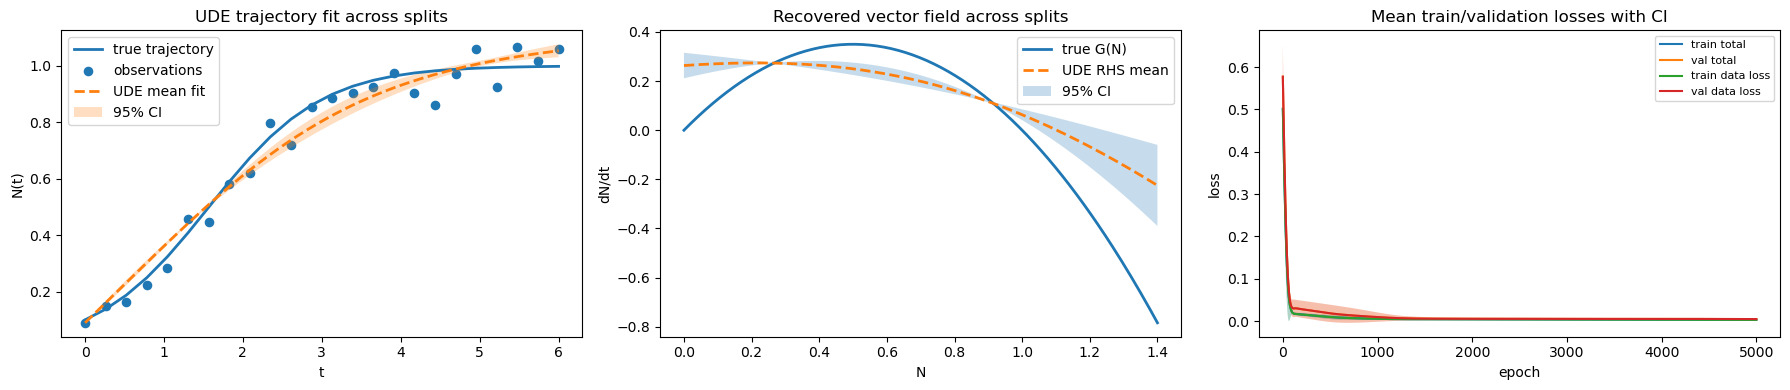

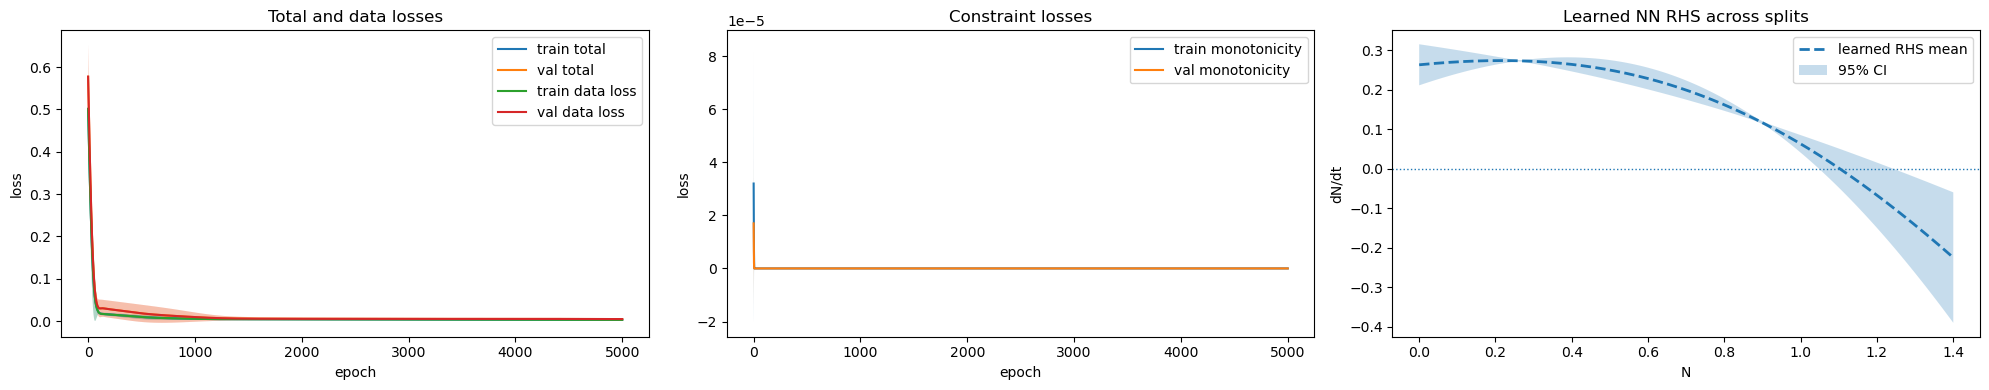

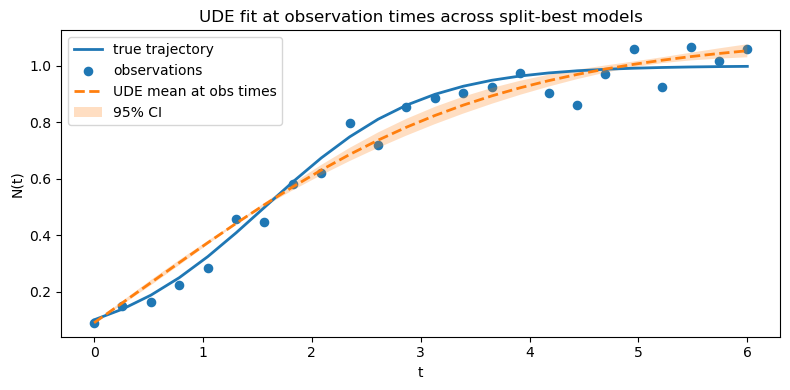

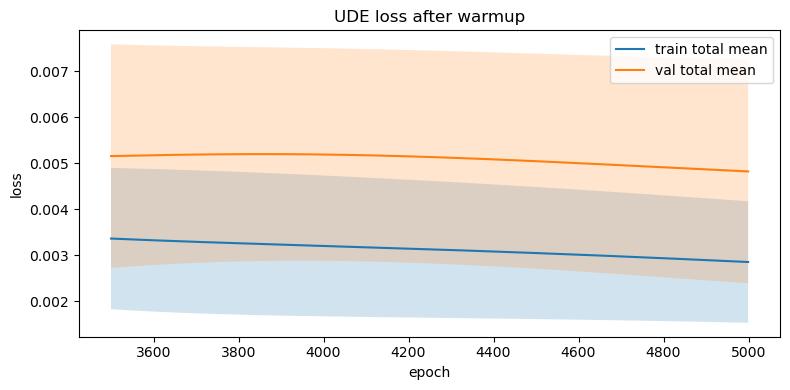


Summary across splits
---------------------
Number of splits: 10
Fixed initial condition y0 = first data point = 0.089592
Mean best validation loss: 4.297538e-03
Std  best validation loss: 2.120746e-03
Mean best epoch: 4100.00
Std  best epoch: 1557.11
Mean fixed y0 across splits: 0.089592
Std  fixed y0 across splits: 0.000000

Per-split best validation losses:
Split  1 | best val loss = 2.443380e-03 | best epoch =  4999 | fixed y0 = 0.089592
Split  2 | best val loss = 3.839287e-03 | best epoch =  2302 | fixed y0 = 0.089592
Split  3 | best val loss = 6.609946e-03 | best epoch =  4999 | fixed y0 = 0.089592

Observed time points: mean prediction and 95% CI across split-best UDE models
t =  0.000 | true =  0.10000 | data =  0.08959 | UDE mean =  0.08959 | 95% CI = [ 0.08959,  0.08959] | learned dN/dt mean =  0.27022 | 95% CI = [ 0.23832,  0.30212]
t =  0.261 | true =  0.13800 | data =  0.15065 | UDE mean =  0.16044 | 95% CI = [ 0.15399,  0.16688] | learned dN/dt mean =  0.27265 | 95% CI =

Split  1/10 done | Best epoch =  9859 | Best val loss = 6.389331e-03-03
Split  2/10 done | Best epoch =   531 | Best val loss = 2.785424e-03-03
Split  3/10 done | Best epoch =  2738 | Best val loss = 2.466674e-03-03
Split  4/10 done | Best epoch =  5600 | Best val loss = 8.812888e-04-03
Split  5/10 done | Best epoch =  1872 | Best val loss = 2.519854e-03-03
Split  6/10 done | Best epoch =  6187 | Best val loss = 1.209747e-03-03
Split  7/10 done | Best epoch =  3680 | Best val loss = 1.458376e-03-03
Split  8/10 done | Best epoch =  1521 | Best val loss = 2.524545e-03-03
Split  9/10 done | Best epoch =  1221 | Best val loss = 3.042620e-03-03
Split 10/10 done | Best epoch =  7624 | Best val loss = 7.358064e-04-04


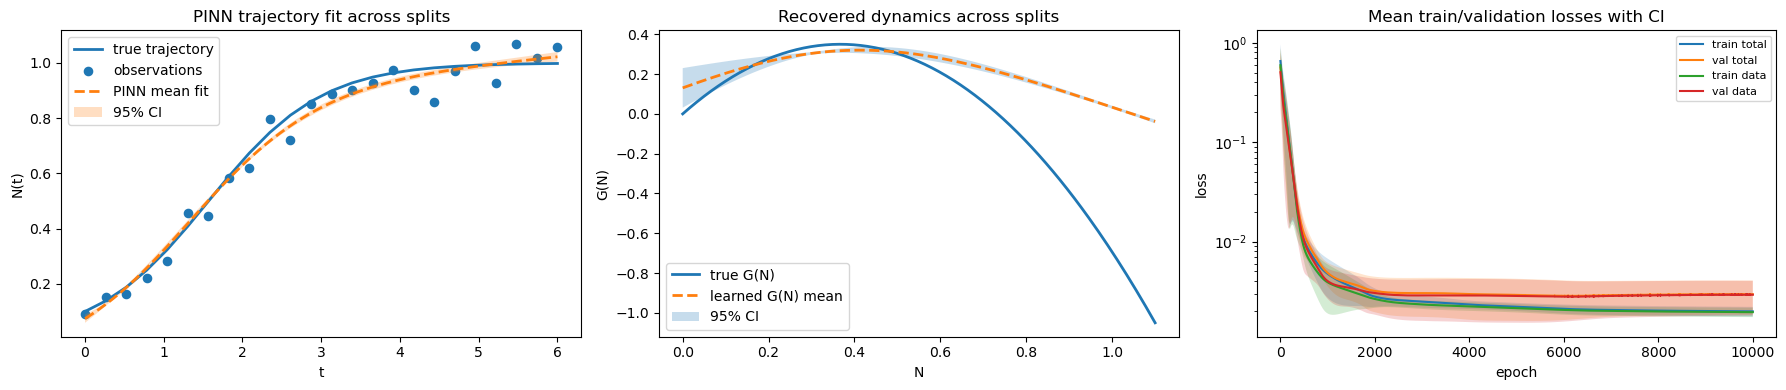

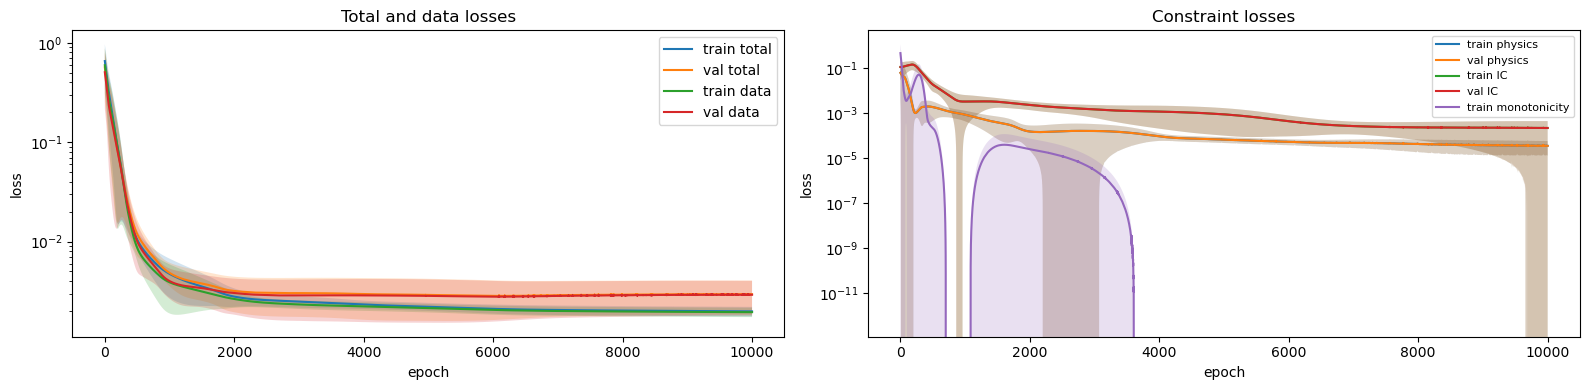

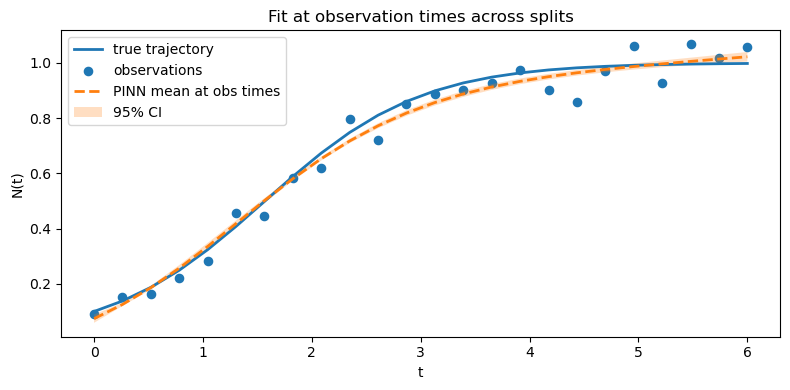


Summary across splits
---------------------
Number of splits: 10
Mean best validation loss: 2.401367e-03
Std  best validation loss: 1.629245e-03
Mean best epoch: 4083.30
Std  best epoch: 3106.63

Per-split best validation losses:
Split  1 | best val loss = 6.389331e-03 | best epoch = 9859
Split  2 | best val loss = 2.785424e-03 | best epoch = 531
Split  3 | best val loss = 2.466674e-03 | best epoch = 2738
Split  4 | best val loss = 8.812888e-04 | best epoch = 5600
Split  5 | best val loss = 2.519854e-03 | best epoch = 1872
Split  6 | best val loss = 1.209747e-03 | best epoch = 6187
Split  7 | best val loss = 1.458376e-03 | best epoch = 3680
Split  8 | best val loss = 2.524545e-03 | best epoch = 1521
Split  9 | best val loss = 3.042620e-03 | best epoch = 1221
Split 10 | best val loss = 7.358064e-04 | best epoch = 7624

Observed time points: mean prediction and 95% CI across split-best models
t =  0.000 | true =  0.10000 | data =  0.08959 | PINN mean =  0.07401 | 95% CI = [ 0.05904,  0.

In [299]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4*(24//4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)  # (numpts,1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)  # (12,1)

noise_std = 0.05
torch.manual_seed(2)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true #+ noise_std * torch.randn_like(y_true)


# ============================================================
# 3. PINN components
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
            
        )

    def forward(self, N):
        return self.net(N)


# ============================================================
# 4. Helpers
# ============================================================
def mean_and_ci(arr, ci=1.96):
    """
    arr shape: (n_runs, n_points)
    returns mean, lower, upper
    """
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lower = mean.copy()
        upper = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lower = mean - ci * sem
        upper = mean + ci * sem
    return mean, lower, upper


# ============================================================
# 5. Experiment settings
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 10000
n_splits = 10

val_fraction = 0.2
n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_ic = 1.0
lambda_mon = 1.0

learning_rate = 1e-3
hidden_dim_sol = 4
hidden_dim_dyn = 4

# evaluation grids
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
#N_grid = torch.linspace(y_true.min().item(), y_true.max().item(), 200, device=device).view(-1, 1)
N_grid = torch.linspace(0, 1.1, 200, device=device).view(-1, 1)

# containers across splits
train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_ic_histories = []
train_mon_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []
val_ic_histories = []
val_mon_histories = []

traj_histories = []        # N(t_plot)
rhs_histories = []         # G(N_grid)
obs_fit_histories = []     # N(t_obs)

best_val_losses = []
best_epochs = []

train_indices_all = []
val_indices_all = []


# ============================================================
# 6. Loop over train/validation splits
# ============================================================
for split in range(n_splits):
    # -------------------------
    # Split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    train_indices_all.append(train_idx.cpu().numpy())
    val_indices_all.append(val_idx.cpu().numpy())

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    # -------------------------
    # Fresh model for this split
    # -------------------------
    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    optimizer = torch.optim.Adam(
        list(sol_net.parameters()) + list(dyn_net.parameters()),
        lr=learning_rate
    )

    # histories for this split
    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_ic_history = []
    train_mon_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []
    val_ic_history = []
    val_mon_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    # -------------------------
    # Training
    # -------------------------
    for epoch in range(n_epochs):
        optimizer.zero_grad()

        # Train data loss
        N_pred_train = sol_net(t_train)
        train_data_loss = torch.mean((N_pred_train - y_train) ** 2)

        # IC loss
        t0 = torch.zeros((1, 1), device=device)
        N0_pred = sol_net(t0)
        ic_loss = torch.mean((N0_pred - torch.tensor([[N0]], dtype=torch.float32, device=device)) ** 2)

        # Physics + monotonicity
        t_col = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col = sol_net(t_col)

        dN_dt = torch.autograd.grad(
            outputs=N_pred_col,
            inputs=t_col,
            grad_outputs=torch.ones_like(N_pred_col),
            create_graph=True,
            retain_graph=True,
        )[0]

        rhs_pred = dyn_net(N_pred_col)
        phys_res = dN_dt - rhs_pred
        phys_loss = torch.mean(phys_res ** 2)

        mon_violation = torch.relu(-dN_dt)
        mon_loss = torch.sum(mon_violation ** 2)

        #reg_loss = 1e-5 * sum((p ** 2).sum() for p in dyn_net.parameters())

        train_loss = (
            train_data_loss
            + lambda_phys * phys_loss
            #+ lambda_ic * ic_loss
            #+ lambda_mon * mon_loss
            #+ reg_loss
        )

        train_loss.backward()
        optimizer.step()

        # Validation losses
        with torch.no_grad():
            N_pred_val = sol_net(t_val)
            val_data_loss = torch.mean((N_pred_val - y_val) ** 2)

            N0_pred_val = sol_net(t0)
            val_ic_loss = torch.mean(
                (N0_pred_val - torch.tensor([[N0]], dtype=torch.float32, device=device)) ** 2
            )

            #val_reg_loss = 1e-5 * sum((p ** 2).sum() for p in dyn_net.parameters())

        t_col_val = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col_val = sol_net(t_col_val)

        dN_dt_val = torch.autograd.grad(
            outputs=N_pred_col_val,
            inputs=t_col_val,
            grad_outputs=torch.ones_like(N_pred_col_val),
            create_graph=False,
            retain_graph=False,
        )[0]

        rhs_pred_val = dyn_net(N_pred_col_val)
        val_phys_res = dN_dt_val - rhs_pred_val
        val_phys_loss = torch.mean(val_phys_res ** 2)

        #val_mon_violation = torch.relu(-dN_dt_val)
        #val_mon_loss = torch.mean(val_mon_violation ** 2)

        val_loss = (
            val_data_loss
            + lambda_phys * val_phys_loss
           # + lambda_ic * val_ic_loss
            #+ lambda_mon * val_mon_loss
           # + val_reg_loss
        )

        # record
        train_total_history.append(train_loss.item())
        train_data_history.append(train_data_loss.item())
        train_phys_history.append(phys_loss.item())
        train_ic_history.append(ic_loss.item())
        train_mon_history.append(mon_loss.item())

        val_total_history.append(val_loss.item())
        val_data_history.append(val_data_loss.item())
        val_phys_history.append(val_phys_loss.item())
        val_ic_history.append(val_ic_loss.item())
        #val_mon_history.append(val_mon_loss.item())

        # save best model on validation loss
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
            }

        if epoch % 1000 == 0:
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch:5d} | "
                f"TrainTot {train_loss.item():.6e} | "
                f"ValTot {val_loss.item():.6e}",
                end="\r"
            )

    print(
        f"Split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best val loss = {best_val_loss:.6e}"
    )

    # restore best model for this split
    sol_net.load_state_dict(best_state["sol_net"])
    dyn_net.load_state_dict(best_state["dyn_net"])

    # evaluate best model for this split
    with torch.no_grad():
        N_pinn = sol_net(t_plot)
        G_grid_learned = dyn_net(N_grid)
        N_fit_obs = sol_net(t_obs)

    # store
    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_ic_histories.append(train_ic_history)
    train_mon_histories.append(train_mon_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)
    val_ic_histories.append(val_ic_history)
    #val_mon_histories.append(val_mon_history)

    traj_histories.append(N_pinn.squeeze(1).cpu().numpy())
    rhs_histories.append(G_grid_learned.squeeze(1).cpu().numpy())
    obs_fit_histories.append(N_fit_obs.squeeze(1).cpu().numpy())

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)


# ============================================================
# 7. Aggregate across splits
# ============================================================
train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_ic_histories = np.array(train_ic_histories)
train_mon_histories = np.array(train_mon_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)
val_ic_histories = np.array(val_ic_histories)
#val_mon_histories = np.array(val_mon_histories)

traj_histories = np.array(traj_histories)      # (n_splits, n_tplot)
rhs_histories = np.array(rhs_histories)        # (n_splits, n_Ngrid)
obs_fit_histories = np.array(obs_fit_histories)# (n_splits, n_obs)

best_val_losses = np.array(best_val_losses)
best_epochs = np.array(best_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
train_phys_mean, train_phys_lo, train_phys_hi = mean_and_ci(train_phys_histories)
train_ic_mean, train_ic_lo, train_ic_hi = mean_and_ci(train_ic_histories)
train_mon_mean, train_mon_lo, train_mon_hi = mean_and_ci(train_mon_histories)

val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)
val_phys_mean, val_phys_lo, val_phys_hi = mean_and_ci(val_phys_histories)
val_ic_mean, val_ic_lo, val_ic_hi = mean_and_ci(val_ic_histories)
#val_mon_mean, val_mon_lo, val_mon_hi = mean_and_ci(val_mon_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)


# ============================================================
# 8. Plot aggregate results with mean and CI bands
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# -------------------------
# Trajectory with CI
# -------------------------
axes[0].plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0].scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
axes[0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="PINN mean fit",
)
axes[0].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="95% CI",
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("N(t)")
axes[0].set_title("PINN trajectory fit across splits")
axes[0].legend()

# -------------------------
# Learned RHS with CI
# -------------------------
axes[1].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[1].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[1].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.25,
    label="95% CI",
)
axes[1].set_xlabel("N")
axes[1].set_ylabel("G(N)")
axes[1].set_title("Recovered dynamics across splits")
axes[1].legend()

# -------------------------
# Total/data losses with CI
# -------------------------
epochs = np.arange(n_epochs)

axes[2].plot(epochs, train_total_mean, label="train total")
axes[2].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[2].plot(epochs, val_total_mean, label="val total")
axes[2].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[2].plot(epochs, train_data_mean, label="train data")
axes[2].fill_between(epochs, train_data_lo, train_data_hi, alpha=0.20)

axes[2].plot(epochs, val_data_mean, label="val data")
axes[2].fill_between(epochs, val_data_lo, val_data_hi, alpha=0.20)

axes[2].set_yscale("log")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("loss")
axes[2].set_title("Mean train/validation losses with CI")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 9. Additional detailed loss plots with CI
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Total + data
axes[0].plot(epochs, train_total_mean, label="train total")
axes[0].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[0].plot(epochs, val_total_mean, label="val total")
axes[0].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[0].plot(epochs, train_data_mean, label="train data")
axes[0].fill_between(epochs, train_data_lo, train_data_hi, alpha=0.20)

axes[0].plot(epochs, val_data_mean, label="val data")
axes[0].fill_between(epochs, val_data_lo, val_data_hi, alpha=0.20)

axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Total and data losses")
axes[0].legend()

# Constraint losses
axes[1].plot(epochs, train_phys_mean, label="train physics")
axes[1].fill_between(epochs, train_phys_lo, train_phys_hi, alpha=0.20)

axes[1].plot(epochs, val_phys_mean, label="val physics")
axes[1].fill_between(epochs, val_phys_lo, val_phys_hi, alpha=0.20)

axes[1].plot(epochs, train_ic_mean, label="train IC")
axes[1].fill_between(epochs, train_ic_lo, train_ic_hi, alpha=0.20)

axes[1].plot(epochs, val_ic_mean, label="val IC")
axes[1].fill_between(epochs, val_ic_lo, val_ic_hi, alpha=0.20)

axes[1].plot(epochs, train_mon_mean, label="train monotonicity")
axes[1].fill_between(epochs, train_mon_lo, train_mon_hi, alpha=0.20)

# axes[1].plot(epochs, val_mon_mean, label="val monotonicity")
# axes[1].fill_between(epochs, val_mon_lo, val_mon_hi, alpha=0.20)

axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Constraint losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time fit with CI
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="PINN mean at obs times",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.25,
    label="95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("Fit at observation times across splits")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 11. Summary prints
# ============================================================
print("\nSummary across splits")
print("---------------------")
print(f"Number of splits: {n_splits}")
print(f"Mean best validation loss: {best_val_losses.mean():.6e}")
print(f"Std  best validation loss: {best_val_losses.std(ddof=1):.6e}")
print(f"Mean best epoch: {best_epochs.mean():.2f}")
print(f"Std  best epoch: {best_epochs.std(ddof=1):.2f}")

print("\nPer-split best validation losses:")
for i, (ve, ep) in enumerate(zip(best_val_losses, best_epochs), start=1):
    print(f"Split {i:2d} | best val loss = {ve:.6e} | best epoch = {ep}")

print("\nObserved time points: mean prediction and 95% CI across split-best models")
for ti, yt, yd, mu, lo, hi in zip(
    t_obs.squeeze(1).cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    obs_fit_mean,
    obs_fit_lo,
    obs_fit_hi,
):
    print(
        f"t = {ti:6.3f} | "
        f"true = {yt:8.5f} | "
        f"data = {yd:8.5f} | "
        f"PINN mean = {mu:8.5f} | "
        f"95% CI = [{lo:8.5f}, {hi:8.5f}]"
    )

PINN-sigma repeat  1/5 done | Best epoch =  554 | Best val loss = -5.095240e+00e+00
PINN-sigma repeat  2/5 done | Best epoch = 1999 | Best val loss = -5.045576e+00e+00
PINN-sigma repeat  3/5 done | Best epoch = 1071 | Best val loss = -4.920296e+00e+00
PINN-sigma repeat  4/5 done | Best epoch =  630 | Best val loss = -5.152238e+00e+00
PINN-sigma repeat  5/5 done | Best epoch = 1997 | Best val loss = -5.079166e+00e+00
TRUE-sigma repeat  1/5 done | Best epoch = 1999 | Best val loss = -5.386497e+00e+00
TRUE-sigma repeat  2/5 done | Best epoch =  758 | Best val loss = -5.137558e+00e+00
TRUE-sigma repeat  3/5 done | Best epoch = 1999 | Best val loss = -5.722540e+00e+00
TRUE-sigma repeat  4/5 done | Best epoch =  243 | Best val loss = -4.287629e+00e+00
TRUE-sigma repeat  5/5 done | Best epoch = 1342 | Best val loss = -5.515135e+00e+00


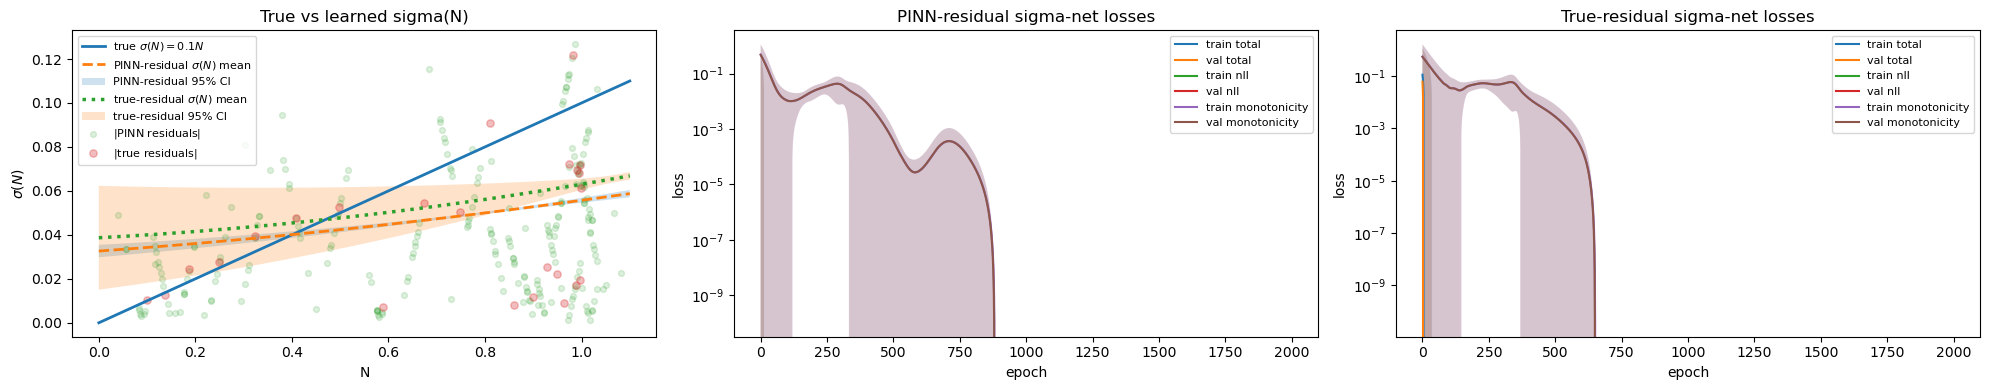


PINN-residual sigma summary across repeats
------------------------------------------
Number of repeats: 5
Mean best validation loss: -5.058503e+00
Std  best validation loss: 8.635844e-02
Mean best epoch: 1250.20
Std  best epoch: 710.61

TRUE-residual sigma summary across repeats
------------------------------------------
Number of repeats: 5
Mean best validation loss: -5.209872e+00
Std  best validation loss: 5.574435e-01
Mean best epoch: 1268.20
Std  best epoch: 772.16

Min numerical gradient of PINN-residual mean sigma curve: 1.551542e-02
Min numerical gradient of TRUE-residual mean sigma curve: 1.169553e-02


In [324]:
# ============================================================
# 12. Post-training sigma(N):
#     (a) train/val split + 10 repeats on PINN residuals
#     (b) train/val split + 10 repeats on TRUE residuals
#     (c) plot all sigma curves on the same plot with CI bands
# ============================================================

class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),  # sigma(N) > 0
        )

    def forward(self, N):
        return self.net(N) + 1e-4


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=10,
    val_fraction=0.2,
    n_epochs=4000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []

    train_indices_all = []
    val_indices_all = []

    for repeat in range(n_repeats):
        # -------------------------
        # split
        # -------------------------
        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        train_indices_all.append(train_idx.cpu().numpy())
        val_indices_all.append(val_idx.cpu().numpy())

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]

        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        # -------------------------
        # fresh model
        # -------------------------
        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        sigma_opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        # -------------------------
        # training
        # -------------------------
        for epoch in range(n_epochs):
            sigma_opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon #+ reg
            train_total.backward()
            sigma_opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

            if epoch % 500 == 0:
                print(
                    f"{label} repeat {repeat + 1:2d}/{n_repeats} | "
                    f"Epoch {epoch:4d} | "
                    f"TrainTot {train_total.item():.6e} | "
                    f"ValTot {val_total.item():.6e}",
                    end="\r"
                )

        print(
            f"{label} repeat {repeat + 1:2d}/{n_repeats} done | "
            f"Best epoch = {best_epoch:4d} | "
            f"Best val loss = {best_val_loss:.6e}"
        )

        sigma_net.load_state_dict(best_state)

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

    results = {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "train_indices_all": train_indices_all,
        "val_indices_all": val_indices_all,
    }
    return results


# ------------------------------------------------------------
# Build sigma dataset from PINN residuals
# ------------------------------------------------------------
with torch.no_grad():
    y_rep = y_data.squeeze(1).cpu().numpy()[None, :]      # (1, n_obs)
    resid_pinn_all_np = y_rep - obs_fit_histories         # (n_splits, n_obs)

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

# ------------------------------------------------------------
# Build sigma dataset from TRUE residuals
# ------------------------------------------------------------
with torch.no_grad():
    N_true_sigma_np = y_true.squeeze(1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data - y_true).squeeze(1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
n_sigma_repeats = 5
sigma_val_fraction = 0.2

n_sigma_epochs = 2000
n_sigma_epochs_true = 2000
sigma_lr = 2e-3
lambda_sigma_mon = 1.0
lambda_sigma_reg = 1e-5
hidden_dim_sigma = 4

N_sigma_min = 0.0
N_sigma_max = max(
    1.1,
    float(N_pinn_sigma_all.max().item()),
    float(N_true_sigma.max().item()),
)
N_sigma_col_base = torch.linspace(N_sigma_min, N_sigma_max, 200, device=device).view(-1, 1)

# ------------------------------------------------------------
# Repeated train/val fits on PINN residuals
# ------------------------------------------------------------
pinn_sigma_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=n_sigma_repeats,
    val_fraction=sigma_val_fraction,
    n_epochs=n_sigma_epochs,
    lr=sigma_lr,
    hidden_dim=hidden_dim_sigma,
    lambda_mon=lambda_sigma_mon,
    lambda_reg=lambda_sigma_reg,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
)

# ------------------------------------------------------------
# Repeated train/val fits on TRUE residuals
# ------------------------------------------------------------
true_sigma_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=n_sigma_repeats,
    val_fraction=sigma_val_fraction,
    n_epochs=n_sigma_epochs_true,
    lr=sigma_lr,
    hidden_dim=hidden_dim_sigma,
    lambda_mon=lambda_sigma_mon,
    lambda_reg=lambda_sigma_reg,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
)

# ------------------------------------------------------------
# Aggregate repeated PINN-residual sigma fits
# ------------------------------------------------------------
pinn_train_total_mean, pinn_train_total_lo, pinn_train_total_hi = mean_and_ci(
    pinn_sigma_results["train_total_histories"]
)
pinn_train_nll_mean, pinn_train_nll_lo, pinn_train_nll_hi = mean_and_ci(
    pinn_sigma_results["train_nll_histories"]
)
pinn_train_mon_mean, pinn_train_mon_lo, pinn_train_mon_hi = mean_and_ci(
    pinn_sigma_results["train_mon_histories"]
)

pinn_val_total_mean, pinn_val_total_lo, pinn_val_total_hi = mean_and_ci(
    pinn_sigma_results["val_total_histories"]
)
pinn_val_nll_mean, pinn_val_nll_lo, pinn_val_nll_hi = mean_and_ci(
    pinn_sigma_results["val_nll_histories"]
)
pinn_val_mon_mean, pinn_val_mon_lo, pinn_val_mon_hi = mean_and_ci(
    pinn_sigma_results["val_mon_histories"]
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    pinn_sigma_results["curve_histories"]
)

# ------------------------------------------------------------
# Aggregate repeated TRUE-residual sigma fits
# ------------------------------------------------------------
true_train_total_mean, true_train_total_lo, true_train_total_hi = mean_and_ci(
    true_sigma_results["train_total_histories"]
)
true_train_nll_mean, true_train_nll_lo, true_train_nll_hi = mean_and_ci(
    true_sigma_results["train_nll_histories"]
)
true_train_mon_mean, true_train_mon_lo, true_train_mon_hi = mean_and_ci(
    true_sigma_results["train_mon_histories"]
)

true_val_total_mean, true_val_total_lo, true_val_total_hi = mean_and_ci(
    true_sigma_results["val_total_histories"]
)
true_val_nll_mean, true_val_nll_lo, true_val_nll_hi = mean_and_ci(
    true_sigma_results["val_nll_histories"]
)
true_val_mon_mean, true_val_mon_lo, true_val_mon_hi = mean_and_ci(
    true_sigma_results["val_mon_histories"]
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    true_sigma_results["curve_histories"]
)

# ------------------------------------------------------------
# Ground-truth sigma(N)
# ------------------------------------------------------------
sigma_true_curve = 0.1 * N_grid.squeeze(1).cpu().numpy()

# ------------------------------------------------------------
# Plot all sigma curves together
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# -------------------------
# Sigma curves
# -------------------------
axes[0].plot(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_true_curve,
    linewidth=2,
    label=r"true $\sigma(N)=0.1N$",
)

axes[0].plot(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)

axes[0].plot(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)

axes[0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=18,
    alpha=0.16,
    label=r"$|$PINN residuals$|$",
)
axes[0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=28,
    alpha=0.30,
    label=r"$|$true residuals$|$",
)

axes[0].set_xlabel("N")
axes[0].set_ylabel(r"$\sigma(N)$")
axes[0].set_title("True vs learned sigma(N)")
axes[0].legend(fontsize=8)

# -------------------------
# PINN-sigma losses
# -------------------------
sigma_epochs = np.arange(n_sigma_epochs)

axes[1].plot(sigma_epochs, pinn_train_total_mean, label="train total")
axes[1].fill_between(sigma_epochs, pinn_train_total_lo, pinn_train_total_hi, alpha=0.20)

axes[1].plot(sigma_epochs, pinn_val_total_mean, label="val total")
axes[1].fill_between(sigma_epochs, pinn_val_total_lo, pinn_val_total_hi, alpha=0.20)

axes[1].plot(sigma_epochs, pinn_train_nll_mean, label="train nll")
axes[1].fill_between(sigma_epochs, pinn_train_nll_lo, pinn_train_nll_hi, alpha=0.20)

axes[1].plot(sigma_epochs, pinn_val_nll_mean, label="val nll")
axes[1].fill_between(sigma_epochs, pinn_val_nll_lo, pinn_val_nll_hi, alpha=0.20)

axes[1].plot(sigma_epochs, pinn_train_mon_mean, label="train monotonicity")
axes[1].fill_between(sigma_epochs, pinn_train_mon_lo, pinn_train_mon_hi, alpha=0.20)

axes[1].plot(sigma_epochs, pinn_val_mon_mean, label="val monotonicity")
axes[1].fill_between(sigma_epochs, pinn_val_mon_lo, pinn_val_mon_hi, alpha=0.20)

axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("PINN-residual sigma-net losses")
axes[1].legend(fontsize=8)

# -------------------------
# TRUE-sigma losses
# -------------------------
axes[2].plot(sigma_epochs, true_train_total_mean, label="train total")
axes[2].fill_between(sigma_epochs, true_train_total_lo, true_train_total_hi, alpha=0.20)

axes[2].plot(sigma_epochs, true_val_total_mean, label="val total")
axes[2].fill_between(sigma_epochs, true_val_total_lo, true_val_total_hi, alpha=0.20)

axes[2].plot(sigma_epochs, true_train_nll_mean, label="train nll")
axes[2].fill_between(sigma_epochs, true_train_nll_lo, true_train_nll_hi, alpha=0.20)

axes[2].plot(sigma_epochs, true_val_nll_mean, label="val nll")
axes[2].fill_between(sigma_epochs, true_val_nll_lo, true_val_nll_hi, alpha=0.20)

axes[2].plot(sigma_epochs, true_train_mon_mean, label="train monotonicity")
axes[2].fill_between(sigma_epochs, true_train_mon_lo, true_train_mon_hi, alpha=0.20)

axes[2].plot(sigma_epochs, true_val_mon_mean, label="val monotonicity")
axes[2].fill_between(sigma_epochs, true_val_mon_lo, true_val_mon_hi, alpha=0.20)

axes[2].set_yscale("log")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("loss")
axes[2].set_title("True-residual sigma-net losses")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\nPINN-residual sigma summary across repeats")
print("------------------------------------------")
print(f"Number of repeats: {n_sigma_repeats}")
print(f"Mean best validation loss: {pinn_sigma_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {pinn_sigma_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {pinn_sigma_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {pinn_sigma_results['best_epochs'].std(ddof=1):.2f}")

print("\nTRUE-residual sigma summary across repeats")
print("------------------------------------------")
print(f"Number of repeats: {n_sigma_repeats}")
print(f"Mean best validation loss: {true_sigma_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {true_sigma_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {true_sigma_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {true_sigma_results['best_epochs'].std(ddof=1):.2f}")

# optional numerical gradient checks
sigma_pinn_mean_grad = np.gradient(sigma_pinn_mean, N_grid.squeeze(1).cpu().numpy())
sigma_truefit_mean_grad = np.gradient(sigma_truefit_mean, N_grid.squeeze(1).cpu().numpy())

print(f"\nMin numerical gradient of PINN-residual mean sigma curve: {sigma_pinn_mean_grad.min():.6e}")
print(f"Min numerical gradient of TRUE-residual mean sigma curve: {sigma_truefit_mean_grad.min():.6e}")

## Initi

In [311]:
y_train[0]

tensor([0.1506])

Split  1/10 done | PINN-init val = 6.857151e-03 | UDE best val = 6.242943e-03 | UDE best epoch =     0 | PINN IC target = 0.086766 | UDE best y0 = 0.085767 | y0 true = 0.100000
Split  2/10 done | PINN-init val = 3.254194e-03 | UDE best val = 3.194330e-03 | UDE best epoch =     0 | PINN IC target = 0.087675 | UDE best y0 = 0.086675 | y0 true = 0.100000
Split  3/10 done | PINN-init val = 2.466711e-03 | UDE best val = 2.536741e-03 | UDE best epoch =    52 | PINN IC target = 0.082254 | UDE best y0 = 0.082725 | y0 true = 0.100000
Split  4/10 done | PINN-init val = 8.043497e-04 | UDE best val = 7.170938e-04 | UDE best epoch =    95 | PINN IC target = 0.083305 | UDE best y0 = 0.083568 | y0 true = 0.100000
Split  5/10 done | PINN-init val = 2.552407e-03 | UDE best val = 2.096422e-03 | UDE best epoch =     0 | PINN IC target = 0.057070 | UDE best y0 = 0.056070 | y0 true = 0.100000
Split  6/10 done | PINN-init val = 1.272385e-03 | UDE best val = 1.161099e-03 | UDE best epoch =     0 | PINN IC ta

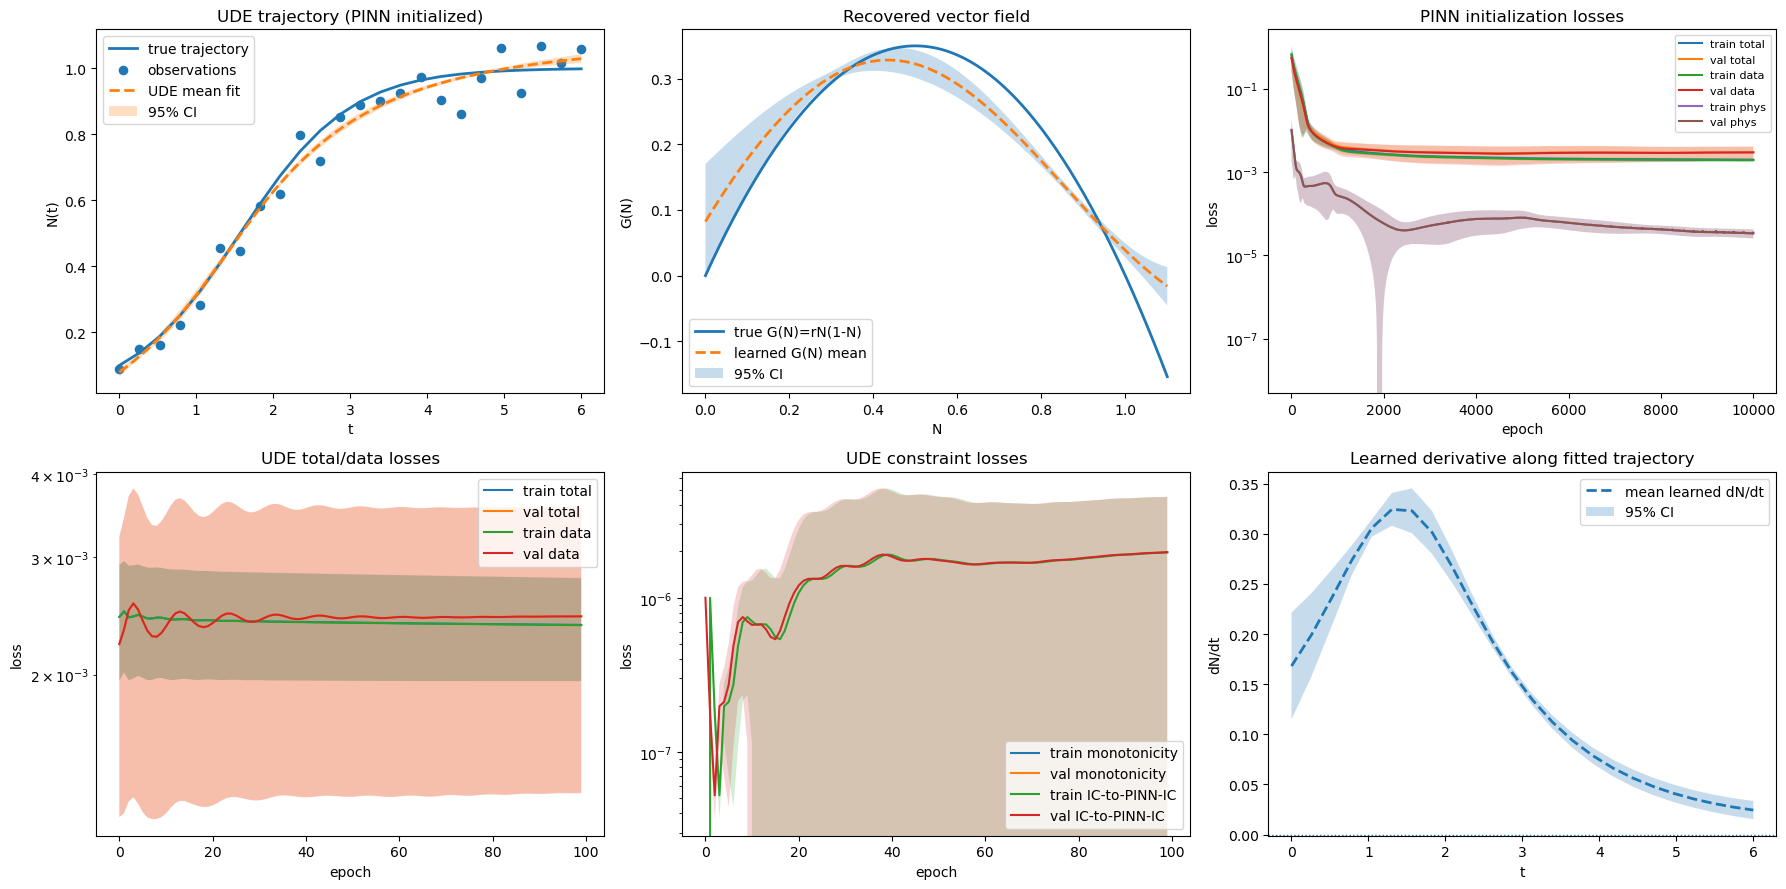

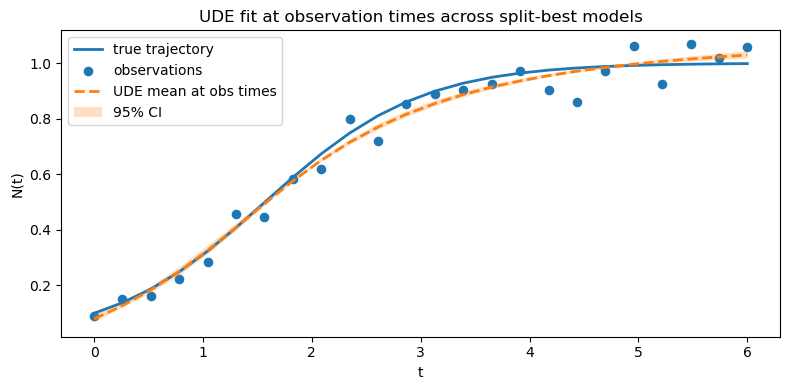


Observed time points: mean prediction and 95% CI across split-best UDE models
t =  0.000 | true N(t) =  0.100000 | data =  0.089592 | UDE mean fit =  0.079658 | 95% CI = [ 0.065758,  0.093558] | mean learned dN/dt =  0.168133 | dN/dt CI = [ 0.114830,  0.221437]
t =  0.261 | true N(t) =  0.137997 | data =  0.150645 | UDE mean fit =  0.127469 | 95% CI = [ 0.120573,  0.134364] | mean learned dN/dt =  0.199466 | dN/dt CI = [ 0.157966,  0.240965]
t =  0.522 | true N(t) =  0.187425 | data =  0.162981 | UDE mean fit =  0.184177 | 95% CI = [ 0.173151,  0.195203] | mean learned dN/dt =  0.235947 | dN/dt CI = [ 0.207788,  0.264106]
t =  0.783 | true N(t) =  0.249435 | data =  0.221756 | UDE mean fit =  0.250682 | 95% CI = [ 0.235630,  0.265734] | mean learned dN/dt =  0.273660 | dN/dt CI = [ 0.258790,  0.288530]
t =  1.043 | true N(t) =  0.323788 | data =  0.284325 | UDE mean fit =  0.326477 | 95% CI = [ 0.310710,  0.342244] | mean learned dN/dt =  0.305862 | dN/dt CI = [ 0.297204,  0.314521]
t

In [323]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
#    NOTE:
#    - N0_true is used ONLY to generate synthetic data.
#    - It is NOT used in any training/validation loss.
# ============================================================
r_true = 1.4
N0_true = 0.1
numpts = 4*(24//4)

# 12 observation times
t_obs = torch.linspace(0.0, 6.0, numpts, device=device)          # (T,)
t_obs_col = t_obs.view(-1, 1)                                # (T,1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Differentiable RK4 ODE solver
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    """
    Integrate y' = f(t,y) over time grid t using RK4.
    y0 shape: (batch, dim) or (dim,)
    returns: tensor of shape (len(t), ...) matching y0
    """
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


# ============================================================
# 3. Simulate observed data
# ============================================================
with torch.no_grad():
    y0_true = torch.tensor([[N0_true]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs).squeeze(1)   # (T,1)


noise_std = 0.05
torch.manual_seed(2)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true #+ noise_std * torch.randn_like(y_true)


# ============================================================
# 4. PINN pretraining models
#    We use these to initialize the UDE.
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, N):
        return self.net(N)


# ============================================================
# 5. UDE model
#    Same architecture as DynamicsNet so weights can be copied
# ============================================================
class ODEFunc(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, t, y):
        return self.net(y)


# ============================================================
# 6. Helpers
# ============================================================
def mean_and_ci(arr, ci=1.96):
    """
    arr shape: (n_runs, n_points)
    returns mean, lower, upper
    """
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lower = mean.copy()
        upper = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lower = mean - ci * sem
        upper = mean + ci * sem
    return mean, lower, upper

def compute_pinn_time_derivative(sol_net, t):
    """
    t shape: (n,1), requires_grad=True
    returns:
      N_pred: shape (n,1)
      dN_dt:  shape (n,1)
    """
    N_pred = sol_net(t)
    dN_dt = torch.autograd.grad(
        outputs=N_pred,
        inputs=t,
        grad_outputs=torch.ones_like(N_pred),
        create_graph=True,
        retain_graph=True,
    )[0]
    return N_pred, dN_dt


# ============================================================
# 7. Settings
# ============================================================
n_splits = 10
val_fraction = 0.2

n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_train = n_obs - n_val

# ---- PINN pretraining settings (used only for initialization)
pinn_n_epochs = 10000
pinn_n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, pinn_n_col, device=device).view(-1, 1)

lambda_phys_pinn = 1.0
lambda_ic_pinn = 0.0     # no true IC in losses
lambda_mon_pinn = 0.0
pinn_learning_rate = 1e-3
hidden_dim_sol = 4
hidden_dim_dyn = 4

# ---- UDE training settings
ude_n_epochs = 100
lambda_mon_ude = 1.0
lambda_reg_ude = 0.0     # regularization intentionally not used
lambda_ic_ude = 1.0
ude_learning_rate = 1e-3
hidden_dim_ude = 4

# evaluation grids
t_plot = torch.linspace(0.0, 6.0, 200, device=device)
#N_grid = torch.linspace(y_true.min().item(), y_true.max().item(), 200, device=device).unsqueeze(1)
N_grid = torch.linspace(0, 1.1, 200, device=device).view(-1, 1)

# ============================================================
# 8. Containers across splits
# ============================================================
# PINN-pretraining histories
pinn_train_total_histories = []
pinn_train_data_histories = []
pinn_train_phys_histories = []
pinn_train_ic_histories = []
pinn_train_mon_histories = []

pinn_val_total_histories = []
pinn_val_data_histories = []
pinn_val_phys_histories = []
pinn_val_ic_histories = []
pinn_val_mon_histories = []

pinn_init_y0s = []
pinn_best_val_losses = []
pinn_best_epochs = []

# UDE histories
ude_train_total_histories = []
ude_train_data_histories = []
ude_train_mon_histories = []
ude_train_ic_histories = []
ude_train_reg_histories = []

ude_val_total_histories = []
ude_val_data_histories = []
ude_val_mon_histories = []
ude_val_ic_histories = []
ude_val_reg_histories = []

# predictions
traj_histories = []
rhs_histories = []
obs_fit_histories = []
rhs_fit_histories = []

# model-selection summaries
ude_best_val_losses = []
ude_best_epochs = []
ude_best_y0_values = []

train_indices_all = []
val_indices_all = []


# ============================================================
# 9. Loop over splits
#    For each split:
#      (A) PINN pretraining of dyn_net + sol_net
#      (B) Use pretrained dyn_net + sol_net(0) to initialize UDE
#      (C) Train UDE and keep best validation model
#
#    IMPORTANT:
#    - No true IC is used anywhere in the losses.
#    - The PINN-estimated IC is used as the UDE initialization target.
# ============================================================
for split in range(n_splits):
    # -------------------------
    # Split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    train_indices_all.append(train_idx.cpu().numpy())
    val_indices_all.append(val_idx.cpu().numpy())

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    # ========================================================
    # 9A. PINN pretraining
    # ========================================================
    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    pinn_optimizer = torch.optim.Adam(
        list(sol_net.parameters()) + list(dyn_net.parameters()),
        lr=pinn_learning_rate
    )

    pinn_train_total_history = []
    pinn_train_data_history = []
    pinn_train_phys_history = []
    pinn_train_ic_history = []
    pinn_train_mon_history = []

    pinn_val_total_history = []
    pinn_val_data_history = []
    pinn_val_phys_history = []
    pinn_val_ic_history = []
    pinn_val_mon_history = []

    pinn_best_val_loss = float("inf")
    pinn_best_epoch = -1
    pinn_best_state = None

    for epoch in range(pinn_n_epochs):
        pinn_optimizer.zero_grad()

        # Train data loss
        N_pred_train = sol_net(t_train.view(-1, 1))
        train_data_loss = torch.mean((N_pred_train - y_train) ** 2)

        # IC loss placeholder: intentionally not used
        ic_loss = torch.tensor(0.0, device=device)

        # Physics + monotonicity
        t_col = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col = sol_net(t_col)

        dN_dt = torch.autograd.grad(
            outputs=N_pred_col,
            inputs=t_col,
            grad_outputs=torch.ones_like(N_pred_col),
            create_graph=True,
            retain_graph=True,
        )[0]

        rhs_pred = dyn_net(N_pred_col)
        phys_res = dN_dt - rhs_pred
        phys_loss = torch.mean(phys_res ** 2)

        mon_violation = torch.relu(-dN_dt)
        mon_loss = torch.sum(mon_violation ** 2)

        train_loss = (
            train_data_loss
            + lambda_phys_pinn * phys_loss
            #+ lambda_ic_pinn * ic_loss
            + lambda_mon_pinn * mon_loss
        )

        train_loss.backward()
        pinn_optimizer.step()

        # Validation losses
        with torch.no_grad():
            N_pred_val = sol_net(t_val.view(-1, 1))
            val_data_loss = torch.mean((N_pred_val - y_val) ** 2)

            val_ic_loss = torch.tensor(0.0, device=device)

        t_col_val = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col_val = sol_net(t_col_val)

        dN_dt_val = torch.autograd.grad(
            outputs=N_pred_col_val,
            inputs=t_col_val,
            grad_outputs=torch.ones_like(N_pred_col_val),
            create_graph=False,
            retain_graph=False,
        )[0]

        rhs_pred_val = dyn_net(N_pred_col_val)
        val_phys_res = dN_dt_val - rhs_pred_val
        val_phys_loss = torch.mean(val_phys_res ** 2)

        val_mon_violation = torch.relu(-dN_dt_val)
        val_mon_loss = torch.sum(val_mon_violation ** 2)

        val_loss = (
            val_data_loss
            + lambda_phys_pinn * val_phys_loss
            #+ lambda_ic_pinn * val_ic_loss
            + lambda_mon_pinn * val_mon_loss
        )

        pinn_train_total_history.append(train_loss.item())
        pinn_train_data_history.append(train_data_loss.item())
        pinn_train_phys_history.append(phys_loss.item())
        pinn_train_ic_history.append(ic_loss.item())
        pinn_train_mon_history.append(mon_loss.item())

        pinn_val_total_history.append(val_loss.item())
        pinn_val_data_history.append(val_data_loss.item())
        pinn_val_phys_history.append(val_phys_loss.item())
        pinn_val_ic_history.append(val_ic_loss.item())
        pinn_val_mon_history.append(val_mon_loss.item())

        if val_loss.item() < pinn_best_val_loss:
            pinn_best_val_loss = val_loss.item()
            pinn_best_epoch = epoch
            pinn_best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
            }

        if epoch % 1000 == 0:
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"[PINN init] Epoch {epoch:5d} | "
                f"TrainTot {train_loss.item():.6e} | "
                f"ValTot {val_loss.item():.6e}",
                end="\r",
            )

    sol_net.load_state_dict(pinn_best_state["sol_net"])
    dyn_net.load_state_dict(pinn_best_state["dyn_net"])

    with torch.no_grad():
        # PINN-estimated IC used to initialize the UDE
        y0_init_from_pinn = sol_net(torch.zeros((1, 1), device=device)).detach().clone()

    pinn_init_y0s.append(y0_init_from_pinn.item())
    pinn_best_val_losses.append(pinn_best_val_loss)
    pinn_best_epochs.append(pinn_best_epoch)

    pinn_train_total_histories.append(pinn_train_total_history)
    pinn_train_data_histories.append(pinn_train_data_history)
    pinn_train_phys_histories.append(pinn_train_phys_history)
    pinn_train_ic_histories.append(pinn_train_ic_history)
    pinn_train_mon_histories.append(pinn_train_mon_history)

    pinn_val_total_histories.append(pinn_val_total_history)
    pinn_val_data_histories.append(pinn_val_data_history)
    pinn_val_phys_histories.append(pinn_val_phys_history)
    pinn_val_ic_histories.append(pinn_val_ic_history)
    pinn_val_mon_histories.append(pinn_val_mon_history)

    # ========================================================
    # 9B. Initialize UDE from pretrained PINN dynamics
    # ========================================================
    func = ODEFunc(hidden_dim=hidden_dim_ude).to(device)

    # copy dynamics weights
    func.net.load_state_dict(copy.deepcopy(dyn_net.net.state_dict()))

    # initialize UDE IC from PINN IC
    y0_est = nn.Parameter(y0_init_from_pinn.clone())

    # use PINN IC as the UDE "true" IC target in losses
    y0_target_for_ude = y0_init_from_pinn.detach().clone()

    ude_params = list(func.parameters()) + [y0_est]
    ude_optimizer = torch.optim.Adam(ude_params, lr=ude_learning_rate)

    ude_train_total_history = []
    ude_train_data_history = []
    ude_train_mon_history = []
    ude_train_ic_history = []
    ude_train_reg_history = []

    ude_val_total_history = []
    ude_val_data_history = []
    ude_val_mon_history = []
    ude_val_ic_history = []
    ude_val_reg_history = []

    ude_best_val_loss = float("inf")
    ude_best_epoch = -1
    ude_best_state = None

    # ========================================================
    # 9C. Train UDE
    # ========================================================
    for epoch in range(ude_n_epochs):
        ude_optimizer.zero_grad()

        # Predict full trajectory, then slice
        y_pred_full = odeint_rk4(func, y0_est, t_obs).squeeze(1)  # (T,1)
        y_pred_train = y_pred_full[train_idx]

        # Train data loss
        train_data_loss = torch.mean((y_pred_train - y_train) ** 2)

        # Monotonicity on train points
        rhs_train = func(t_train.view(-1, 1), y_pred_train)
        train_mon_violation = torch.relu(-rhs_train)
        train_mon_loss = torch.sum(train_mon_violation ** 2)

        # IC loss: target is the PINN-estimated IC, not the true IC
        train_ic_loss = torch.mean((y0_est - y0_target_for_ude) ** 2) #y0_target_for_ude

        # Reg loss placeholder: intentionally not used / commented out
        # reg_loss = sum((p ** 2).sum() for p in func.parameters())
        reg_loss = torch.tensor(0.0, device=device)

        train_loss = (
            train_data_loss
            #+ lambda_mon_ude * train_mon_loss
            #+ lambda_reg_ude * reg_loss
            + lambda_ic_ude * train_ic_loss
        )

        train_loss.backward()
        ude_optimizer.step()

        # Validation
        with torch.no_grad():
            y_pred_full_val = odeint_rk4(func, y0_est, t_obs).squeeze(1)
            y_pred_val = y_pred_full_val[val_idx]

            val_data_loss = torch.mean((y_pred_val - y_val) ** 2)

            rhs_val = func(t_val.view(-1, 1), y_pred_val)
            val_mon_violation = torch.relu(-rhs_val)
            val_mon_loss = torch.sum(val_mon_violation ** 2)

            # Again use PINN IC as the target
            val_ic_loss = torch.mean((y0_est - y0_target_for_ude) ** 2)

            # val_reg_loss = sum((p ** 2).sum() for p in func.parameters())
            val_reg_loss = torch.tensor(0.0, device=device)

            val_loss = (
                val_data_loss
                #+ lambda_mon_ude * val_mon_loss
                #+ lambda_reg_ude * val_reg_loss
                + lambda_ic_ude * val_ic_loss
            )

        ude_train_total_history.append(train_loss.item())
        ude_train_data_history.append(train_data_loss.item())
        ude_train_mon_history.append(train_mon_loss.item())
        ude_train_ic_history.append(train_ic_loss.item())
        ude_train_reg_history.append((lambda_reg_ude * reg_loss).item())

        ude_val_total_history.append(val_loss.item())
        ude_val_data_history.append(val_data_loss.item())
        ude_val_mon_history.append(val_mon_loss.item())
        ude_val_ic_history.append(val_ic_loss.item())
        ude_val_reg_history.append((lambda_reg_ude * val_reg_loss).item())

        if val_loss.item() < ude_best_val_loss:
            ude_best_val_loss = val_loss.item()
            ude_best_epoch = epoch
            ude_best_state = {
                "func": copy.deepcopy(func.state_dict()),
                "y0_est": y0_est.detach().clone(),
                "y0_target_for_ude": y0_target_for_ude.detach().clone(),
            }

        if epoch % 1000 == 0:
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"[UDE] Epoch {epoch:5d} | "
                f"TrainTot {train_loss.item():.6e} | "
                f"ValTot {val_loss.item():.6e}",
                end="\r",
            )

    print(
        f"Split {split + 1:2d}/{n_splits} done | "
        f"PINN-init val = {pinn_best_val_loss:.6e} | "
        f"UDE best val = {ude_best_val_loss:.6e} | "
        f"UDE best epoch = {ude_best_epoch:5d} | "
        f"PINN IC target = {y0_target_for_ude.item():.6f} | "
        f"UDE best y0 = {ude_best_state['y0_est'].item():.6f} | "
        f"y0 true = {y0_true.item():.6f}"
    )

    # restore best UDE
    func.load_state_dict(ude_best_state["func"])
    y0_est = nn.Parameter(ude_best_state["y0_est"].clone())
    y0_target_for_ude = ude_best_state["y0_target_for_ude"].clone()

    # evaluate best UDE
    with torch.no_grad():
        y_fit_plot = odeint_rk4(func, y0_est, t_plot).squeeze(1)
        y_fit_obs = odeint_rk4(func, y0_est, t_obs).squeeze(1)

        G_grid_learned = func(torch.tensor(0.0, device=device), N_grid)
        rhs_fit = func(t_obs_col, y_fit_obs)

    ude_train_total_histories.append(ude_train_total_history)
    ude_train_data_histories.append(ude_train_data_history)
    ude_train_mon_histories.append(ude_train_mon_history)
    ude_train_ic_histories.append(ude_train_ic_history)
    ude_train_reg_histories.append(ude_train_reg_history)

    ude_val_total_histories.append(ude_val_total_history)
    ude_val_data_histories.append(ude_val_data_history)
    ude_val_mon_histories.append(ude_val_mon_history)
    ude_val_ic_histories.append(ude_val_ic_history)
    ude_val_reg_histories.append(ude_val_reg_history)

    traj_histories.append(y_fit_plot.squeeze(1).cpu().numpy())
    rhs_histories.append(G_grid_learned.squeeze(1).cpu().numpy())
    obs_fit_histories.append(y_fit_obs.squeeze(1).cpu().numpy())
    rhs_fit_histories.append(rhs_fit.squeeze(1).cpu().numpy())

    ude_best_val_losses.append(ude_best_val_loss)
    ude_best_epochs.append(ude_best_epoch)
    ude_best_y0_values.append(ude_best_state["y0_est"].item())


# ============================================================
# 10. Aggregate across splits
# ============================================================
# PINN init
pinn_train_total_histories = np.array(pinn_train_total_histories)
pinn_train_data_histories = np.array(pinn_train_data_histories)
pinn_train_phys_histories = np.array(pinn_train_phys_histories)
pinn_train_ic_histories = np.array(pinn_train_ic_histories)
pinn_train_mon_histories = np.array(pinn_train_mon_histories)

pinn_val_total_histories = np.array(pinn_val_total_histories)
pinn_val_data_histories = np.array(pinn_val_data_histories)
pinn_val_phys_histories = np.array(pinn_val_phys_histories)
pinn_val_ic_histories = np.array(pinn_val_ic_histories)
pinn_val_mon_histories = np.array(pinn_val_mon_histories)

pinn_best_val_losses = np.array(pinn_best_val_losses)
pinn_best_epochs = np.array(pinn_best_epochs)
pinn_init_y0s = np.array(pinn_init_y0s)

# UDE
ude_train_total_histories = np.array(ude_train_total_histories)
ude_train_data_histories = np.array(ude_train_data_histories)
ude_train_mon_histories = np.array(ude_train_mon_histories)
ude_train_ic_histories = np.array(ude_train_ic_histories)
ude_train_reg_histories = np.array(ude_train_reg_histories)

ude_val_total_histories = np.array(ude_val_total_histories)
ude_val_data_histories = np.array(ude_val_data_histories)
ude_val_mon_histories = np.array(ude_val_mon_histories)
ude_val_ic_histories = np.array(ude_val_ic_histories)
ude_val_reg_histories = np.array(ude_val_reg_histories)

traj_histories = np.array(traj_histories)
rhs_histories = np.array(rhs_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_fit_histories = np.array(rhs_fit_histories)

ude_best_val_losses = np.array(ude_best_val_losses)
ude_best_epochs = np.array(ude_best_epochs)
ude_best_y0_values = np.array(ude_best_y0_values)

# PINN stats
pinn_train_total_mean, pinn_train_total_lo, pinn_train_total_hi = mean_and_ci(pinn_train_total_histories)
pinn_train_data_mean, pinn_train_data_lo, pinn_train_data_hi = mean_and_ci(pinn_train_data_histories)
pinn_train_phys_mean, pinn_train_phys_lo, pinn_train_phys_hi = mean_and_ci(pinn_train_phys_histories)

pinn_val_total_mean, pinn_val_total_lo, pinn_val_total_hi = mean_and_ci(pinn_val_total_histories)
pinn_val_data_mean, pinn_val_data_lo, pinn_val_data_hi = mean_and_ci(pinn_val_data_histories)
pinn_val_phys_mean, pinn_val_phys_lo, pinn_val_phys_hi = mean_and_ci(pinn_val_phys_histories)

# UDE stats
ude_train_total_mean, ude_train_total_lo, ude_train_total_hi = mean_and_ci(ude_train_total_histories)
ude_train_data_mean, ude_train_data_lo, ude_train_data_hi = mean_and_ci(ude_train_data_histories)
ude_train_mon_mean, ude_train_mon_lo, ude_train_mon_hi = mean_and_ci(ude_train_mon_histories)
ude_train_ic_mean, ude_train_ic_lo, ude_train_ic_hi = mean_and_ci(ude_train_ic_histories)

ude_val_total_mean, ude_val_total_lo, ude_val_total_hi = mean_and_ci(ude_val_total_histories)
ude_val_data_mean, ude_val_data_lo, ude_val_data_hi = mean_and_ci(ude_val_data_histories)
ude_val_mon_mean, ude_val_mon_lo, ude_val_mon_hi = mean_and_ci(ude_val_mon_histories)
ude_val_ic_mean, ude_val_ic_lo, ude_val_ic_hi = mean_and_ci(ude_val_ic_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)
rhs_fit_mean, rhs_fit_lo, rhs_fit_hi = mean_and_ci(rhs_fit_histories)


# ============================================================
# 11. Summary
# ============================================================
print("\nPINN initialization summary across splits")
print("-----------------------------------------")
print(f"Mean PINN best validation loss: {pinn_best_val_losses.mean():.6e}")
print(f"Std  PINN best validation loss: {pinn_best_val_losses.std(ddof=1):.6e}")
print(f"Mean PINN best epoch: {pinn_best_epochs.mean():.2f}")
print(f"Std  PINN best epoch: {pinn_best_epochs.std(ddof=1):.2f}")
print(f"Mean UDE init y0 from PINN: {pinn_init_y0s.mean():.6f}")
print(f"Std  UDE init y0 from PINN: {pinn_init_y0s.std(ddof=1):.6f}")

print("\nUDE summary across splits")
print("------------------------")
print(f"Mean UDE best validation loss: {ude_best_val_losses.mean():.6e}")
print(f"Std  UDE best validation loss: {ude_best_val_losses.std(ddof=1):.6e}")
print(f"Mean UDE best epoch: {ude_best_epochs.mean():.2f}")
print(f"Std  UDE best epoch: {ude_best_epochs.std(ddof=1):.2f}")
print(f"Mean learned UDE y0: {ude_best_y0_values.mean():.6f}")
print(f"Std  learned UDE y0: {ude_best_y0_values.std(ddof=1):.6f}")

print("\nPer-split initialization and UDE results:")
for i, (pvl, pep, py0, uvl, uep, uy0) in enumerate(
    zip(
        pinn_best_val_losses,
        pinn_best_epochs,
        pinn_init_y0s,
        ude_best_val_losses,
        ude_best_epochs,
        ude_best_y0_values,
    ),
    start=1,
):
    print(
        f"Split {i:2d} | "
        f"PINN best val = {pvl:.6e} @ {pep:4d} | "
        f"PINN IC = {py0:.6f} | "
        f"UDE best val = {uvl:.6e} @ {uep:4d} | "
        f"final UDE y0 = {uy0:.6f}"
    )


# ============================================================
# 12. Plots
# ============================================================
epochs_pinn = np.arange(pinn_n_epochs)
epochs_ude = np.arange(ude_n_epochs)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# ------------------------------------------------
# (a) UDE trajectory with CI
# ------------------------------------------------
axes[0, 0].plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0, 0].scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
axes[0, 0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="UDE mean fit",
)
axes[0, 0].fill_between(
    t_plot.cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="95% CI",
)
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("UDE trajectory (PINN initialized)")
axes[0, 0].legend()

# ------------------------------------------------
# (b) Learned RHS with CI
# ------------------------------------------------
axes[0, 1].plot(
    N_grid.cpu().numpy(),
    G_true(N_grid).cpu().numpy(),
    label="true G(N)=rN(1-N)",
    linewidth=2,
)
axes[0, 1].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 1].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.25,
    label="95% CI",
)
axes[0, 1].set_xlabel("N")
axes[0, 1].set_ylabel("G(N)")
axes[0, 1].set_title("Recovered vector field")
axes[0, 1].legend()

# ------------------------------------------------
# (c) PINN-pretraining losses
# ------------------------------------------------
axes[0, 2].plot(epochs_pinn, pinn_train_total_mean, label="train total")
axes[0, 2].fill_between(epochs_pinn, pinn_train_total_lo, pinn_train_total_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_val_total_mean, label="val total")
axes[0, 2].fill_between(epochs_pinn, pinn_val_total_lo, pinn_val_total_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_train_data_mean, label="train data")
axes[0, 2].fill_between(epochs_pinn, pinn_train_data_lo, pinn_train_data_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_val_data_mean, label="val data")
axes[0, 2].fill_between(epochs_pinn, pinn_val_data_lo, pinn_val_data_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_train_phys_mean, label="train phys")
axes[0, 2].fill_between(epochs_pinn, pinn_train_phys_lo, pinn_train_phys_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_val_phys_mean, label="val phys")
axes[0, 2].fill_between(epochs_pinn, pinn_val_phys_lo, pinn_val_phys_hi, alpha=0.20)

axes[0, 2].set_yscale("log")
axes[0, 2].set_xlabel("epoch")
axes[0, 2].set_ylabel("loss")
axes[0, 2].set_title("PINN initialization losses")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------
# (d) UDE train/validation total + data
# ------------------------------------------------
axes[1, 0].plot(epochs_ude, ude_train_total_mean, label="train total")
axes[1, 0].fill_between(epochs_ude, ude_train_total_lo, ude_train_total_hi, alpha=0.20)

axes[1, 0].plot(epochs_ude, ude_val_total_mean, label="val total")
axes[1, 0].fill_between(epochs_ude, ude_val_total_lo, ude_val_total_hi, alpha=0.20)

axes[1, 0].plot(epochs_ude, ude_train_data_mean, label="train data")
axes[1, 0].fill_between(epochs_ude, ude_train_data_lo, ude_train_data_hi, alpha=0.20)

axes[1, 0].plot(epochs_ude, ude_val_data_mean, label="val data")
axes[1, 0].fill_between(epochs_ude, ude_val_data_lo, ude_val_data_hi, alpha=0.20)

axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].set_ylabel("loss")
axes[1, 0].set_title("UDE total/data losses")
axes[1, 0].legend()

# ------------------------------------------------
# (e) UDE constraint losses
# ------------------------------------------------
axes[1, 1].plot(epochs_ude, ude_train_mon_mean, label="train monotonicity")
axes[1, 1].fill_between(epochs_ude, ude_train_mon_lo, ude_train_mon_hi, alpha=0.20)

axes[1, 1].plot(epochs_ude, ude_val_mon_mean, label="val monotonicity")
axes[1, 1].fill_between(epochs_ude, ude_val_mon_lo, ude_val_mon_hi, alpha=0.20)

axes[1, 1].plot(epochs_ude, ude_train_ic_mean, label="train IC-to-PINN-IC")
axes[1, 1].fill_between(epochs_ude, ude_train_ic_lo, ude_train_ic_hi, alpha=0.20)

axes[1, 1].plot(epochs_ude, ude_val_ic_mean, label="val IC-to-PINN-IC")
axes[1, 1].fill_between(epochs_ude, ude_val_ic_lo, ude_val_ic_hi, alpha=0.20)

axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("UDE constraint losses")
axes[1, 1].legend()

# ------------------------------------------------
# (f) Learned derivative along fitted trajectory
# ------------------------------------------------
axes[1, 2].plot(
    t_obs.cpu().numpy(),
    rhs_fit_mean,
    "--",
    linewidth=2,
    label="mean learned dN/dt",
)
axes[1, 2].fill_between(
    t_obs.cpu().numpy(),
    rhs_fit_lo,
    rhs_fit_hi,
    alpha=0.25,
    label="95% CI",
)
axes[1, 2].axhline(0.0, linestyle=":", linewidth=1)
axes[1, 2].set_xlabel("t")
axes[1, 2].set_ylabel("dN/dt")
axes[1, 2].set_title("Learned derivative along fitted trajectory")
axes[1, 2].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 13. Observation-time fit with CI
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="UDE mean at obs times",
)
plt.fill_between(
    t_obs.cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.25,
    label="95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("UDE fit at observation times across split-best models")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 14. Print observed time points
# ============================================================
print("\nObserved time points: mean prediction and 95% CI across split-best UDE models")
for ti, yt, yd, mu, lo, hi, gp_mu, gp_lo, gp_hi in zip(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    obs_fit_mean,
    obs_fit_lo,
    obs_fit_hi,
    rhs_fit_mean,
    rhs_fit_lo,
    rhs_fit_hi,
):
    print(
        f"t = {ti: .3f} | "
        f"true N(t) = {yt: .6f} | "
        f"data = {yd: .6f} | "
        f"UDE mean fit = {mu: .6f} | "
        f"95% CI = [{lo: .6f}, {hi: .6f}] | "
        f"mean learned dN/dt = {gp_mu: .6f} | "
        f"dN/dt CI = [{gp_lo: .6f}, {gp_hi: .6f}]"
    )

# Combo

Split  1/2 done | best stage = joint    | best epoch =   384 | best val loss = 1.299475e-01
Split  2/2 done | best stage = joint    | best epoch =   481 | best val loss = 8.105037e-02

Summary across splits
---------------------
Number of splits: 2
Mean best validation loss: 1.054989e-01
Std  best validation loss: 3.457548e-02
Mean best epoch: 432.50
Std  best epoch: 68.59
Mean learned rollout IC: 0.191010
Std  learned rollout IC: 0.045636
Best-model stage counts:
  joint: 2

Per-split best validation results:
Split  1 | best val = 1.299475e-01 | best epoch =   384 | stage = joint    | N0 = 0.223279
Split  2 | best val = 8.105037e-02 | best epoch =   481 | stage = joint    | N0 = 0.158740


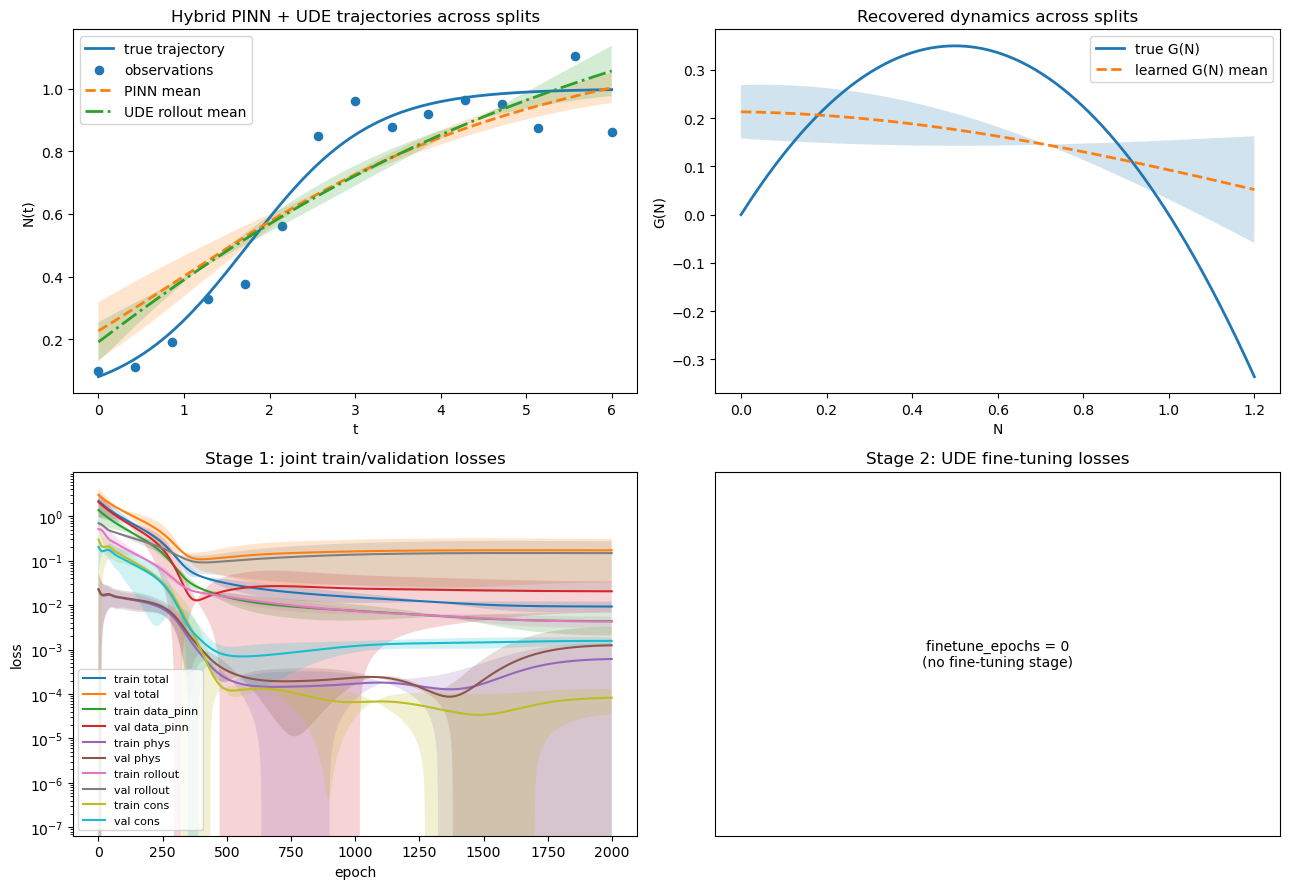

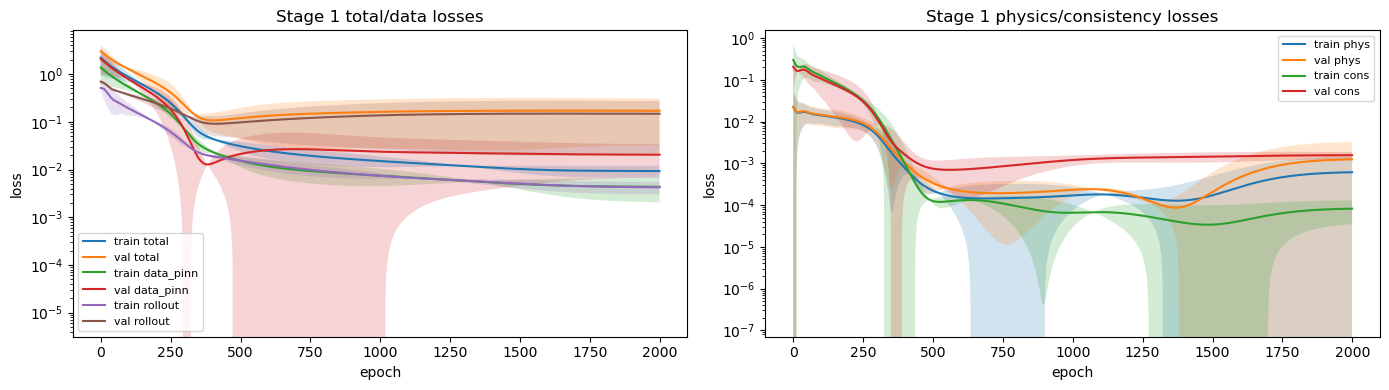

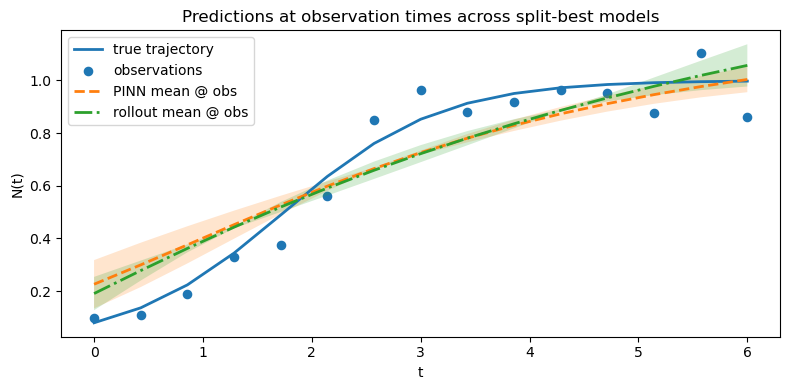


Comparison at observation times (mean and 95% CI across split-best models):
t        true       noisy_data   pinn_mean    pinn_CI_low  pinn_CI_high  roll_mean    roll_CI_low  roll_CI_high
 0.00    0.08000      0.09724     0.22637       0.13474       0.31799     0.19101       0.12776       0.25426
 0.43    0.13674      0.11008     0.29985       0.21568       0.38401     0.27821       0.24032       0.31611
 0.86    0.22395      0.19008     0.37590       0.30531       0.44649     0.36244       0.34742       0.37746
 1.29    0.34459      0.32850     0.45247       0.39917       0.50577     0.44301       0.43883       0.44718
 1.71    0.48926      0.37584     0.52739       0.49241       0.56238     0.51944       0.50060       0.53827
 2.14    0.63576      0.56166     0.59878       0.58087       0.61669     0.59146       0.56298       0.61993
 2.57    0.76077      0.84971     0.66525       0.66171       0.66879     0.65898       0.62602       0.69193
 3.00    0.85278      0.96184     0.72602

In [171]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# 0. Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. True system: logistic growth
#    dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0_true = 0.08

t0 = 0.0
t1 = 6.0
n_obs = 15

t_obs = torch.linspace(t0, t1, n_obs, device=device)          # (T,)
t_obs_col = t_obs.view(-1, 1)                                  # (T,1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Differentiable RK4 solver
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def odeint_rk4(f, y0, t):
    """
    y0: shape (batch, dim) or (dim,)
    t : shape (T,)
    returns: shape (T, ...) matching y0
    """
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


# ============================================================
# 3. Generate synthetic observations
# ============================================================
with torch.no_grad():
    y0 = torch.tensor([[N0_true]], dtype=torch.float32, device=device)  # (1,1)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0, t_obs).squeeze(1)   # (T,1)

noise_std = 0.04
torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true + noise_std * torch.randn_like(y_true)


# ============================================================
# 4. Networks
#    - SolutionNet: PINN-style approximation N_theta(t)
#    - DynamicsNet: UDE RHS G_phi(N)
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, N):
        return self.net(N)


# ============================================================
# 5. Helper functions
# ============================================================
def rollout_with_dynnet(dyn_net, N0, t_grid):
    """
    Integrate dN/dt = dyn_net(N)
    N0 shape: (1,1)
    returns: (T,1)
    """
    y = odeint_rk4(lambda t, y: dyn_net(y), N0, t_grid).squeeze(1)
    return y

def compute_pinn_time_derivative(sol_net, t):
    """
    t shape: (n,1), requires_grad=True
    returns:
      N_pred: shape (n,1)
      dN_dt:  shape (n,1)
    """
    N_pred = sol_net(t)
    dN_dt = torch.autograd.grad(
        outputs=N_pred,
        inputs=t,
        grad_outputs=torch.ones_like(N_pred),
        create_graph=True,
        retain_graph=True,
    )[0]
    return N_pred, dN_dt

def mean_and_ci(arr, z=1.96):
    """
    arr: numpy array of shape (n_runs, n_points)
    returns mean, lower, upper
    """
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        return mean, mean.copy(), mean.copy()
    sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
    lo = mean - z * sem
    hi = mean + z * sem
    return mean, lo, hi

def make_split_indices(n_obs, val_fraction, seed, device):
    n_val = int(round(val_fraction * n_obs))
    n_train = n_obs - n_val
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values
    return train_idx, val_idx


# ============================================================
# 6. Global settings
# ============================================================
n_col = 200
joint_epochs = 2000
finetune_epochs = 0

lr_joint = 1e-3
lr_finetune = 1e-3

hidden_dim_sol = 4
hidden_dim_dyn = 4

w_data_pinn   = 1.0
w_phys        = 1.0
w_rollout     = 1.0
w_cons        = 1.0
w_ic          = 0.0
w_reg         = 0.0

w_rollout_ft  = 1.0
w_phys_ft     = 1.0
w_ic_ft       = 0.0
w_reg_ft      = 0.0

n_splits = 2
val_fraction = 0.25


# ============================================================
# 7. Containers across splits
# ============================================================
# Stage 1 histories
joint_total_histories = []
joint_data_histories = []
joint_phys_histories = []
joint_rollout_histories = []
joint_cons_histories = []
joint_ic_histories = []

val_joint_total_histories = []
val_joint_data_histories = []
val_joint_phys_histories = []
val_joint_rollout_histories = []
val_joint_cons_histories = []
val_joint_ic_histories = []

# Stage 2 histories
ft_total_histories = []
ft_rollout_histories = []
ft_phys_histories = []
ft_ic_histories = []

val_ft_total_histories = []
val_ft_rollout_histories = []
val_ft_phys_histories = []
val_ft_ic_histories = []

# Predictions from best models
pinn_plot_histories = []
roll_plot_histories = []
g_grid_histories = []
pinn_obs_histories = []
roll_obs_histories = []
n0_histories = []

best_val_losses = []
best_epochs = []
best_stage_labels = []

train_indices_all = []
val_indices_all = []


# ============================================================
# 8. Loop over 10 train/validation splits
# ============================================================
for split in range(n_splits):
    # -------------------------
    # Train/validation split
    # -------------------------
    train_idx, val_idx = make_split_indices(
        n_obs=n_obs,
        val_fraction=val_fraction,
        seed=1000 + split,
        device=device,
    )

    train_indices_all.append(train_idx.cpu().numpy())
    val_indices_all.append(val_idx.cpu().numpy())

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]
    t_train_col = t_train.view(-1, 1)

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]
    t_val_col = t_val.view(-1, 1)

    # Dense grids for train/val consistency terms
    t_dense = torch.linspace(t0, t1, 100, device=device)
    dense_train_idx, dense_val_idx = make_split_indices(
        n_obs=len(t_dense),
        val_fraction=val_fraction,
        seed=2000 + split,
        device=device,
    )
    t_dense_train = t_dense[dense_train_idx]
    t_dense_val = t_dense[dense_val_idx]

    # Collocation grids for train/val physics terms
    t_col_all = torch.linspace(t0, t1, n_col, device=device)
    col_train_idx, col_val_idx = make_split_indices(
        n_obs=n_col,
        val_fraction=val_fraction,
        seed=3000 + split,
        device=device,
    )
    t_col_train_base = t_col_all[col_train_idx].sort().values.view(-1, 1)
    t_col_val_base = t_col_all[col_val_idx].sort().values.view(-1, 1)

    # -------------------------
    # Fresh model for this split
    # -------------------------
    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)
    N0_param = nn.Parameter(torch.tensor([[0.0]], dtype=torch.float32, device=device))

    optimizer_joint = torch.optim.Adam(
        list(sol_net.parameters()) + list(dyn_net.parameters()) + [N0_param],
        lr=lr_joint
    )

    optimizer_finetune = torch.optim.Adam(
        list(dyn_net.parameters()) + [N0_param],
        lr=lr_finetune
    )

    # -------------------------
    # Per-split histories
    # -------------------------
    history = {
        "total_joint": [],
        "data_pinn": [],
        "phys": [],
        "rollout": [],
        "cons": [],
        "ic": [],

        "val_total_joint": [],
        "val_data_pinn": [],
        "val_phys": [],
        "val_rollout": [],
        "val_cons": [],
        "val_ic": [],

        "total_ft": [],
        "rollout_ft": [],
        "phys_ft": [],
        "ic_ft": [],

        "val_total_ft": [],
        "val_rollout_ft": [],
        "val_phys_ft": [],
        "val_ic_ft": [],
    }

    best_val_loss = float("inf")
    best_epoch = -1
    best_stage = "joint"
    best_state = None

    # ========================================================
    # 8A. Stage 1: joint hybrid training
    # ========================================================
    for epoch in range(joint_epochs):
        optimizer_joint.zero_grad()

        # -------------------------
        # Train losses
        # -------------------------
        N_pinn_train = sol_net(t_train_col)
        loss_data_pinn = torch.mean((N_pinn_train - y_train) ** 2)

        t_col_train = t_col_train_base.clone().detach().requires_grad_(True)
        N_col_train, dNdt_col_train = compute_pinn_time_derivative(sol_net, t_col_train)
        rhs_col_train = dyn_net(N_col_train)
        residual_train = dNdt_col_train - rhs_col_train
        loss_phys = torch.mean(residual_train ** 2)

        N_roll_train = rollout_with_dynnet(dyn_net, N0_param, t_train)
        loss_rollout = torch.mean((N_roll_train - y_train) ** 2)

        N_roll_dense_train = rollout_with_dynnet(dyn_net, N0_param, t_dense_train)
        N_pinn_dense_train = sol_net(t_dense_train.view(-1, 1))
        loss_cons = torch.mean((N_roll_dense_train - N_pinn_dense_train) ** 2)

        loss_ic = (
            torch.mean((sol_net(torch.zeros((1, 1), device=device)) - torch.tensor([[N0_true]], device=device)) ** 2)
            + torch.mean((N0_param - torch.tensor([[N0_true]], device=device)) ** 2)
        )

        reg = sum((p ** 2).sum() for p in sol_net.parameters())
        reg = reg + sum((p ** 2).sum() for p in dyn_net.parameters())
        loss_reg = w_reg * reg

        loss = (
            w_data_pinn * loss_data_pinn
            + w_phys * loss_phys
            + w_rollout * loss_rollout
            + w_cons * loss_cons
          #  + w_ic * loss_ic
          #  + loss_reg
        )

        loss.backward()
        optimizer_joint.step()

        # -------------------------
        # Validation losses
        # -------------------------
        with torch.no_grad():
            N_pinn_val = sol_net(t_val_col)
            val_loss_data_pinn = torch.mean((N_pinn_val - y_val) ** 2)

            N_roll_val = rollout_with_dynnet(dyn_net, N0_param, t_val)
            val_loss_rollout = torch.mean((N_roll_val - y_val) ** 2)

            N_roll_dense_val = rollout_with_dynnet(dyn_net, N0_param, t_dense_val)
            N_pinn_dense_val = sol_net(t_dense_val.view(-1, 1))
            val_loss_cons = torch.mean((N_roll_dense_val - N_pinn_dense_val) ** 2)

            val_loss_ic = (
                torch.mean((sol_net(torch.zeros((1, 1), device=device)) - torch.tensor([[N0_true]], device=device)) ** 2)
                + torch.mean((N0_param - torch.tensor([[N0_true]], device=device)) ** 2)
            )

            val_reg = sum((p ** 2).sum() for p in sol_net.parameters())
            val_reg = val_reg + sum((p ** 2).sum() for p in dyn_net.parameters())
            val_loss_reg = w_reg * val_reg

        t_col_val = t_col_val_base.clone().detach().requires_grad_(True)
        N_col_val, dNdt_col_val = compute_pinn_time_derivative(sol_net, t_col_val)
        rhs_col_val = dyn_net(N_col_val)
        residual_val = dNdt_col_val - rhs_col_val
        val_loss_phys = torch.mean(residual_val ** 2)

        val_total_loss = (
            w_data_pinn * val_loss_data_pinn
            + w_phys * val_loss_phys
            + w_rollout * val_loss_rollout
            + w_cons * val_loss_cons
          #  + w_ic * val_loss_ic
          #  + val_loss_reg
        )

        # Save histories
        history["total_joint"].append(loss.item())
        history["data_pinn"].append(loss_data_pinn.item())
        history["phys"].append(loss_phys.item())
        history["rollout"].append(loss_rollout.item())
        history["cons"].append(loss_cons.item())
        history["ic"].append(loss_ic.item())

        history["val_total_joint"].append(val_total_loss.item())
        history["val_data_pinn"].append(val_loss_data_pinn.item())
        history["val_phys"].append(val_loss_phys.item())
        history["val_rollout"].append(val_loss_rollout.item())
        history["val_cons"].append(val_loss_cons.item())
        history["val_ic"].append(val_loss_ic.item())

        if val_total_loss.item() < best_val_loss:
            best_val_loss = val_total_loss.item()
            best_epoch = epoch
            best_stage = "joint"
            best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "N0_param": N0_param.detach().clone(),
            }

        if epoch % 500 == 0:
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"[Joint] Epoch {epoch:5d} | "
                f"TrainTot {loss.item():.6e} | "
                f"ValTot {val_total_loss.item():.6e}",
                end="\r"
            )

    # ========================================================
    # 8B. Stage 2: UDE-focused fine-tuning
    # ========================================================
    for p in sol_net.parameters():
        p.requires_grad = False

    for epoch in range(finetune_epochs):
        optimizer_finetune.zero_grad()

        # Train losses
        N_roll_train = rollout_with_dynnet(dyn_net, N0_param, t_train)
        loss_rollout = torch.mean((N_roll_train - y_train) ** 2)

        t_col_train = t_col_train_base.clone().detach().requires_grad_(True)
        N_col = sol_net(t_col_train)
        dNdt_col = torch.autograd.grad(
            outputs=N_col,
            inputs=t_col_train,
            grad_outputs=torch.ones_like(N_col),
            create_graph=True,
            retain_graph=True,
        )[0]
        rhs_col = dyn_net(N_col)
        residual = dNdt_col - rhs_col
        loss_phys = torch.mean(residual ** 2)

        loss_ic = torch.mean((N0_param - torch.tensor([[N0_true]], device=device)) ** 2)

        reg = sum((p ** 2).sum() for p in dyn_net.parameters())
        loss_reg = w_reg_ft * reg

        loss = (
            w_rollout_ft * loss_rollout
            + w_phys_ft * loss_phys
            #+ w_ic_ft * loss_ic
            #+ loss_reg
        )

        loss.backward()
        optimizer_finetune.step()

        # Validation losses
        with torch.no_grad():
            N_roll_val = rollout_with_dynnet(dyn_net, N0_param, t_val)
            val_loss_rollout = torch.mean((N_roll_val - y_val) ** 2)
            val_loss_ic = torch.mean((N0_param - torch.tensor([[N0_true]], device=device)) ** 2)
            val_reg = sum((p ** 2).sum() for p in dyn_net.parameters())
            val_loss_reg = w_reg_ft * val_reg

        t_col_val = t_col_val_base.clone().detach().requires_grad_(True)
        N_col_val = sol_net(t_col_val)
        dNdt_col_val = torch.autograd.grad(
            outputs=N_col_val,
            inputs=t_col_val,
            grad_outputs=torch.ones_like(N_col_val),
            create_graph=False,
            retain_graph=False,
        )[0]
        rhs_col_val = dyn_net(N_col_val)
        residual_val = dNdt_col_val - rhs_col_val
        val_loss_phys = torch.mean(residual_val ** 2)

        val_total_loss = (
            w_rollout_ft * val_loss_rollout
            + w_phys_ft * val_loss_phys
           # + w_ic_ft * val_loss_ic
           # + val_loss_reg
        )

        history["total_ft"].append(loss.item())
        history["rollout_ft"].append(loss_rollout.item())
        history["phys_ft"].append(loss_phys.item())
        history["ic_ft"].append(loss_ic.item())

        history["val_total_ft"].append(val_total_loss.item())
        history["val_rollout_ft"].append(val_loss_rollout.item())
        history["val_phys_ft"].append(val_loss_phys.item())
        history["val_ic_ft"].append(val_loss_ic.item())

        if val_total_loss.item() < best_val_loss:
            best_val_loss = val_total_loss.item()
            best_epoch = epoch
            best_stage = "finetune"
            best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "N0_param": N0_param.detach().clone(),
            }

        if epoch % 500 == 0 and finetune_epochs > 0:
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"[FineTune] Epoch {epoch:5d} | "
                f"TrainTot {loss.item():.6e} | "
                f"ValTot {val_total_loss.item():.6e}",
                end="\r"
            )

    print(
        f"Split {split + 1:2d}/{n_splits} done | "
        f"best stage = {best_stage:8s} | "
        f"best epoch = {best_epoch:5d} | "
        f"best val loss = {best_val_loss:.6e}"
    )

    # -------------------------
    # Restore best model
    # -------------------------
    sol_net.load_state_dict(best_state["sol_net"])
    dyn_net.load_state_dict(best_state["dyn_net"])
    N0_param = nn.Parameter(best_state["N0_param"].clone())

    # -------------------------
    # Evaluation on dense plot grid
    # -------------------------
    with torch.no_grad():
        t_plot = torch.linspace(t0, t1, 300, device=device)
        t_plot_col = t_plot.view(-1, 1)

        N_pinn_plot = sol_net(t_plot_col)
        N_roll_plot = rollout_with_dynnet(dyn_net, N0_param, t_plot)

        N_grid = torch.linspace(0.0, 1.2, 300, device=device).view(-1, 1)
        G_learned_grid = dyn_net(N_grid)

        N_pinn_obs = sol_net(t_obs_col)
        N_roll_obs = rollout_with_dynnet(dyn_net, N0_param, t_obs)

    # Store split results
    joint_total_histories.append(history["total_joint"])
    joint_data_histories.append(history["data_pinn"])
    joint_phys_histories.append(history["phys"])
    joint_rollout_histories.append(history["rollout"])
    joint_cons_histories.append(history["cons"])
    joint_ic_histories.append(history["ic"])

    val_joint_total_histories.append(history["val_total_joint"])
    val_joint_data_histories.append(history["val_data_pinn"])
    val_joint_phys_histories.append(history["val_phys"])
    val_joint_rollout_histories.append(history["val_rollout"])
    val_joint_cons_histories.append(history["val_cons"])
    val_joint_ic_histories.append(history["val_ic"])

    ft_total_histories.append(history["total_ft"])
    ft_rollout_histories.append(history["rollout_ft"])
    ft_phys_histories.append(history["phys_ft"])
    ft_ic_histories.append(history["ic_ft"])

    val_ft_total_histories.append(history["val_total_ft"])
    val_ft_rollout_histories.append(history["val_rollout_ft"])
    val_ft_phys_histories.append(history["val_phys_ft"])
    val_ft_ic_histories.append(history["val_ic_ft"])

    pinn_plot_histories.append(N_pinn_plot.squeeze(1).cpu().numpy())
    roll_plot_histories.append(N_roll_plot.squeeze(1).cpu().numpy())
    g_grid_histories.append(G_learned_grid.squeeze(1).cpu().numpy())
    pinn_obs_histories.append(N_pinn_obs.squeeze(1).cpu().numpy())
    roll_obs_histories.append(N_roll_obs.squeeze(1).cpu().numpy())
    n0_histories.append(N0_param.item())

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_stage_labels.append(best_stage)


# ============================================================
# 9. Convert to numpy and aggregate
# ============================================================
joint_total_histories = np.array(joint_total_histories)
joint_data_histories = np.array(joint_data_histories)
joint_phys_histories = np.array(joint_phys_histories)
joint_rollout_histories = np.array(joint_rollout_histories)
joint_cons_histories = np.array(joint_cons_histories)
joint_ic_histories = np.array(joint_ic_histories)

val_joint_total_histories = np.array(val_joint_total_histories)
val_joint_data_histories = np.array(val_joint_data_histories)
val_joint_phys_histories = np.array(val_joint_phys_histories)
val_joint_rollout_histories = np.array(val_joint_rollout_histories)
val_joint_cons_histories = np.array(val_joint_cons_histories)
val_joint_ic_histories = np.array(val_joint_ic_histories)

pinn_plot_histories = np.array(pinn_plot_histories)
roll_plot_histories = np.array(roll_plot_histories)
g_grid_histories = np.array(g_grid_histories)
pinn_obs_histories = np.array(pinn_obs_histories)
roll_obs_histories = np.array(roll_obs_histories)

best_val_losses = np.array(best_val_losses)
best_epochs = np.array(best_epochs)
n0_histories = np.array(n0_histories)

joint_total_mean, joint_total_lo, joint_total_hi = mean_and_ci(joint_total_histories)
joint_data_mean, joint_data_lo, joint_data_hi = mean_and_ci(joint_data_histories)
joint_phys_mean, joint_phys_lo, joint_phys_hi = mean_and_ci(joint_phys_histories)
joint_roll_mean, joint_roll_lo, joint_roll_hi = mean_and_ci(joint_rollout_histories)
joint_cons_mean, joint_cons_lo, joint_cons_hi = mean_and_ci(joint_cons_histories)
joint_ic_mean, joint_ic_lo, joint_ic_hi = mean_and_ci(joint_ic_histories)

val_joint_total_mean, val_joint_total_lo, val_joint_total_hi = mean_and_ci(val_joint_total_histories)
val_joint_data_mean, val_joint_data_lo, val_joint_data_hi = mean_and_ci(val_joint_data_histories)
val_joint_phys_mean, val_joint_phys_lo, val_joint_phys_hi = mean_and_ci(val_joint_phys_histories)
val_joint_roll_mean, val_joint_roll_lo, val_joint_roll_hi = mean_and_ci(val_joint_rollout_histories)
val_joint_cons_mean, val_joint_cons_lo, val_joint_cons_hi = mean_and_ci(val_joint_cons_histories)
val_joint_ic_mean, val_joint_ic_lo, val_joint_ic_hi = mean_and_ci(val_joint_ic_histories)

pinn_plot_mean, pinn_plot_lo, pinn_plot_hi = mean_and_ci(pinn_plot_histories)
roll_plot_mean, roll_plot_lo, roll_plot_hi = mean_and_ci(roll_plot_histories)
g_grid_mean, g_grid_lo, g_grid_hi = mean_and_ci(g_grid_histories)
pinn_obs_mean, pinn_obs_lo, pinn_obs_hi = mean_and_ci(pinn_obs_histories)
roll_obs_mean, roll_obs_lo, roll_obs_hi = mean_and_ci(roll_obs_histories)

# Handle fine-tune histories only if used
have_ft = finetune_epochs > 0
if have_ft:
    ft_total_histories = np.array(ft_total_histories)
    ft_rollout_histories = np.array(ft_rollout_histories)
    ft_phys_histories = np.array(ft_phys_histories)
    ft_ic_histories = np.array(ft_ic_histories)

    val_ft_total_histories = np.array(val_ft_total_histories)
    val_ft_rollout_histories = np.array(val_ft_rollout_histories)
    val_ft_phys_histories = np.array(val_ft_phys_histories)
    val_ft_ic_histories = np.array(val_ft_ic_histories)

    ft_total_mean, ft_total_lo, ft_total_hi = mean_and_ci(ft_total_histories)
    ft_roll_mean, ft_roll_lo, ft_roll_hi = mean_and_ci(ft_rollout_histories)
    ft_phys_mean, ft_phys_lo, ft_phys_hi = mean_and_ci(ft_phys_histories)
    ft_ic_mean, ft_ic_lo, ft_ic_hi = mean_and_ci(ft_ic_histories)

    val_ft_total_mean, val_ft_total_lo, val_ft_total_hi = mean_and_ci(val_ft_total_histories)
    val_ft_roll_mean, val_ft_roll_lo, val_ft_roll_hi = mean_and_ci(val_ft_rollout_histories)
    val_ft_phys_mean, val_ft_phys_lo, val_ft_phys_hi = mean_and_ci(val_ft_phys_histories)
    val_ft_ic_mean, val_ft_ic_lo, val_ft_ic_hi = mean_and_ci(val_ft_ic_histories)


# ============================================================
# 10. Reference true curves
# ============================================================
with torch.no_grad():
    t_plot = torch.linspace(t0, t1, 300, device=device)
    t_plot_col = t_plot.view(-1, 1)

    N_true_plot = odeint_rk4(
        lambda t, y: G_true(y),
        torch.tensor([[N0_true]], dtype=torch.float32, device=device),
        t_plot
    ).squeeze(1)

    N_grid = torch.linspace(0.0, 1.2, 300, device=device).view(-1, 1)
    G_true_grid = G_true(N_grid)


# ============================================================
# 11. Summary prints
# ============================================================
print("\nSummary across splits")
print("---------------------")
print(f"Number of splits: {n_splits}")
print(f"Mean best validation loss: {best_val_losses.mean():.6e}")
print(f"Std  best validation loss: {best_val_losses.std(ddof=1):.6e}")
print(f"Mean best epoch: {best_epochs.mean():.2f}")
print(f"Std  best epoch: {best_epochs.std(ddof=1):.2f}")
print(f"Mean learned rollout IC: {n0_histories.mean():.6f}")
print(f"Std  learned rollout IC: {n0_histories.std(ddof=1):.6f}")

unique_stages, counts = np.unique(np.array(best_stage_labels), return_counts=True)
print("Best-model stage counts:")
for s, c in zip(unique_stages, counts):
    print(f"  {s}: {c}")

print("\nPer-split best validation results:")
for i, (v, e, s, n0v) in enumerate(zip(best_val_losses, best_epochs, best_stage_labels, n0_histories), start=1):
    print(
        f"Split {i:2d} | best val = {v:.6e} | best epoch = {e:5d} | "
        f"stage = {s:8s} | N0 = {n0v:.6f}"
    )


# ============================================================
# 12. Plots: trajectories, vector field, stage-1 losses, stage-2 losses
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Trajectories
axes[0, 0].plot(t_plot.cpu(), N_true_plot[:, 0].cpu(), label="true trajectory", linewidth=2)
axes[0, 0].scatter(t_obs.cpu(), y_data[:, 0].cpu(), label="observations", s=35)
axes[0, 0].plot(t_plot.cpu(), pinn_plot_mean, "--", label="PINN mean", linewidth=2)
axes[0, 0].fill_between(t_plot.cpu().numpy(), pinn_plot_lo, pinn_plot_hi, alpha=0.20)
axes[0, 0].plot(t_plot.cpu(), roll_plot_mean, "-.", label="UDE rollout mean", linewidth=2)
axes[0, 0].fill_between(t_plot.cpu().numpy(), roll_plot_lo, roll_plot_hi, alpha=0.20)
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Hybrid PINN + UDE trajectories across splits")
axes[0, 0].legend()

# (b) Learned vector field
axes[0, 1].plot(N_grid.cpu(), G_true_grid.cpu(), label="true G(N)", linewidth=2)
axes[0, 1].plot(N_grid.cpu(), g_grid_mean, "--", label="learned G(N) mean", linewidth=2)
axes[0, 1].fill_between(N_grid.squeeze(1).cpu().numpy(), g_grid_lo, g_grid_hi, alpha=0.20)
axes[0, 1].set_xlabel("N")
axes[0, 1].set_ylabel("G(N)")
axes[0, 1].set_title("Recovered dynamics across splits")
axes[0, 1].legend()

# (c) Joint stage losses
epochs_joint = np.arange(joint_epochs)
axes[1, 0].plot(epochs_joint, joint_total_mean, label="train total")
axes[1, 0].fill_between(epochs_joint, joint_total_lo, joint_total_hi, alpha=0.20)
axes[1, 0].plot(epochs_joint, val_joint_total_mean, label="val total")
axes[1, 0].fill_between(epochs_joint, val_joint_total_lo, val_joint_total_hi, alpha=0.20)

axes[1, 0].plot(epochs_joint, joint_data_mean, label="train data_pinn")
axes[1, 0].fill_between(epochs_joint, joint_data_lo, joint_data_hi, alpha=0.20)
axes[1, 0].plot(epochs_joint, val_joint_data_mean, label="val data_pinn")
axes[1, 0].fill_between(epochs_joint, val_joint_data_lo, val_joint_data_hi, alpha=0.20)

axes[1, 0].plot(epochs_joint, joint_phys_mean, label="train phys")
axes[1, 0].fill_between(epochs_joint, joint_phys_lo, joint_phys_hi, alpha=0.20)
axes[1, 0].plot(epochs_joint, val_joint_phys_mean, label="val phys")
axes[1, 0].fill_between(epochs_joint, val_joint_phys_lo, val_joint_phys_hi, alpha=0.20)

axes[1, 0].plot(epochs_joint, joint_roll_mean, label="train rollout")
axes[1, 0].fill_between(epochs_joint, joint_roll_lo, joint_roll_hi, alpha=0.20)
axes[1, 0].plot(epochs_joint, val_joint_roll_mean, label="val rollout")
axes[1, 0].fill_between(epochs_joint, val_joint_roll_lo, val_joint_roll_hi, alpha=0.20)

axes[1, 0].plot(epochs_joint, joint_cons_mean, label="train cons")
axes[1, 0].fill_between(epochs_joint, joint_cons_lo, joint_cons_hi, alpha=0.20)
axes[1, 0].plot(epochs_joint, val_joint_cons_mean, label="val cons")
axes[1, 0].fill_between(epochs_joint, val_joint_cons_lo, val_joint_cons_hi, alpha=0.20)

axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].set_ylabel("loss")
axes[1, 0].set_title("Stage 1: joint train/validation losses")
axes[1, 0].legend(fontsize=8)

# (d) Fine-tuning stage losses
if have_ft:
    epochs_ft = np.arange(finetune_epochs)
    axes[1, 1].plot(epochs_ft, ft_total_mean, label="train total_ft")
    axes[1, 1].fill_between(epochs_ft, ft_total_lo, ft_total_hi, alpha=0.20)
    axes[1, 1].plot(epochs_ft, val_ft_total_mean, label="val total_ft")
    axes[1, 1].fill_between(epochs_ft, val_ft_total_lo, val_ft_total_hi, alpha=0.20)

    axes[1, 1].plot(epochs_ft, ft_roll_mean, label="train rollout_ft")
    axes[1, 1].fill_between(epochs_ft, ft_roll_lo, ft_roll_hi, alpha=0.20)
    axes[1, 1].plot(epochs_ft, val_ft_roll_mean, label="val rollout_ft")
    axes[1, 1].fill_between(epochs_ft, val_ft_roll_lo, val_ft_roll_hi, alpha=0.20)

    axes[1, 1].plot(epochs_ft, ft_phys_mean, label="train phys_ft")
    axes[1, 1].fill_between(epochs_ft, ft_phys_lo, ft_phys_hi, alpha=0.20)
    axes[1, 1].plot(epochs_ft, val_ft_phys_mean, label="val phys_ft")
    axes[1, 1].fill_between(epochs_ft, val_ft_phys_lo, val_ft_phys_hi, alpha=0.20)

    axes[1, 1].set_yscale("log")
    axes[1, 1].set_xlabel("epoch")
    axes[1, 1].set_ylabel("loss")
    axes[1, 1].set_title("Stage 2: UDE fine-tuning train/validation losses")
    axes[1, 1].legend(fontsize=8)
else:
    axes[1, 1].text(0.5, 0.5, "finetune_epochs = 0\n(no fine-tuning stage)", ha="center", va="center")
    axes[1, 1].set_title("Stage 2: UDE fine-tuning losses")
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()


# ============================================================
# 13. Extra plots: cleaner loss summaries
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Joint total/data
axes[0].plot(epochs_joint, joint_total_mean, label="train total")
axes[0].fill_between(epochs_joint, joint_total_lo, joint_total_hi, alpha=0.20)
axes[0].plot(epochs_joint, val_joint_total_mean, label="val total")
axes[0].fill_between(epochs_joint, val_joint_total_lo, val_joint_total_hi, alpha=0.20)

axes[0].plot(epochs_joint, joint_data_mean, label="train data_pinn")
axes[0].fill_between(epochs_joint, joint_data_lo, joint_data_hi, alpha=0.20)
axes[0].plot(epochs_joint, val_joint_data_mean, label="val data_pinn")
axes[0].fill_between(epochs_joint, val_joint_data_lo, val_joint_data_hi, alpha=0.20)

axes[0].plot(epochs_joint, joint_roll_mean, label="train rollout")
axes[0].fill_between(epochs_joint, joint_roll_lo, joint_roll_hi, alpha=0.20)
axes[0].plot(epochs_joint, val_joint_roll_mean, label="val rollout")
axes[0].fill_between(epochs_joint, val_joint_roll_lo, val_joint_roll_hi, alpha=0.20)

axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Stage 1 total/data losses")
axes[0].legend(fontsize=8)

# Joint physics/consistency
axes[1].plot(epochs_joint, joint_phys_mean, label="train phys")
axes[1].fill_between(epochs_joint, joint_phys_lo, joint_phys_hi, alpha=0.20)
axes[1].plot(epochs_joint, val_joint_phys_mean, label="val phys")
axes[1].fill_between(epochs_joint, val_joint_phys_lo, val_joint_phys_hi, alpha=0.20)

axes[1].plot(epochs_joint, joint_cons_mean, label="train cons")
axes[1].fill_between(epochs_joint, joint_cons_lo, joint_cons_hi, alpha=0.20)
axes[1].plot(epochs_joint, val_joint_cons_mean, label="val cons")
axes[1].fill_between(epochs_joint, val_joint_cons_lo, val_joint_cons_hi, alpha=0.20)

axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Stage 1 physics/consistency losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 14. Observation-time predictions with CI
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(t_obs.cpu(), y_true[:, 0].cpu(), label="true trajectory", linewidth=2)
plt.scatter(t_obs.cpu(), y_data[:, 0].cpu(), label="observations", s=35)

plt.plot(t_obs.cpu(), pinn_obs_mean, "--", linewidth=2, label="PINN mean @ obs")
plt.fill_between(t_obs.cpu().numpy(), pinn_obs_lo, pinn_obs_hi, alpha=0.20)

plt.plot(t_obs.cpu(), roll_obs_mean, "-.", linewidth=2, label="rollout mean @ obs")
plt.fill_between(t_obs.cpu().numpy(), roll_obs_lo, roll_obs_hi, alpha=0.20)

plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("Predictions at observation times across split-best models")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 15. Print values at the observed time points
# ============================================================
print("\nComparison at observation times (mean and 95% CI across split-best models):")
print("t        true       noisy_data   pinn_mean    pinn_CI_low  pinn_CI_high  roll_mean    roll_CI_low  roll_CI_high")
for ti, yt, yd, pm, plo, phi, rm, rlo, rhi in zip(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    pinn_obs_mean,
    pinn_obs_lo,
    pinn_obs_hi,
    roll_obs_mean,
    roll_obs_lo,
    roll_obs_hi,
):
    print(
        f"{ti:5.2f}   {yt:8.5f}   {yd:10.5f}   "
        f"{pm:9.5f}   {plo:11.5f}  {phi:12.5f}   "
        f"{rm:9.5f}   {rlo:11.5f}  {rhi:12.5f}"
    )

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.08

# 12 observation times
t_obs = torch.linspace(0.0, 6.0, 12, device=device)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Differentiable RK4 ODE solver
#    This is the "neural ODE" engine we train through
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    """
    Integrate y' = f(t,y) over time grid t using RK4.
    y0 shape: (batch, dim) or (dim,)
    returns: tensor of shape (len(t), ...) matching y0
    """
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


# ============================================================
# 3. Simulate training data from the true logistic system
# ============================================================
with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)  # shape (1,1)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs)         # (T,1,1)
    y_true = y_true.squeeze(1)                                           # (T,1)

# Add observation noise
noise_std = 0.05
y_data = y_true + noise_std * torch.randn_like(y_true)


# ============================================================
# 4. Neural ODE model: NN parameterizes G(N)
# ============================================================
class ODEFunc(nn.Module):
    def __init__(self, hidden_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

        # Mild initialization
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, t, y):
        return self.net(y)


func = ODEFunc(hidden_dim=4).to(device)

# Learn initial condition
y0_est = nn.Parameter(torch.tensor([[0.05]], dtype=torch.float32, device=device))

# Learn observation noise sigma through log_sigma for positivity
log_sigma = nn.Parameter(torch.tensor(np.log(0.1), dtype=torch.float32, device=device))

params = list(func.parameters()) + [y0_est, log_sigma]
optimizer = torch.optim.Adam(params, lr=1e-2)


# ============================================================
# 5. Training loop
# ============================================================
n_epochs = 10000
loss_history = []
sigma_history = []
data_loss_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Predict trajectory from neural ODE
    y_pred = odeint_rk4(func, y0_est, t_obs).squeeze(1)   # (T,1)

    # Positive noise scale
    sigma = torch.exp(log_sigma) + 1e-6

    # Gaussian negative log-likelihood
    resid = y_data - y_pred
    data_loss = 0.5 * torch.mean((resid / sigma) ** 2 + 2.0 * torch.log(sigma))

    # Small smoothness/weight regularization
    reg_loss = 1e-5 * sum((p ** 2).sum() for p in func.parameters())

    loss = data_loss + reg_loss
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    data_loss_history.append(data_loss.item())
    sigma_history.append(sigma.item())

    if epoch % 300 == 0:
        print(
            f"Epoch {epoch:4d} | Loss = {loss.item():.6f} | "
            f"Data NLL = {data_loss.item():.6f} | sigma = {sigma.item():.4f}",
            end="\r"
        )


# ============================================================
# 6. Evaluate learned dynamics
# ============================================================
with torch.no_grad():
    y_fit = odeint_rk4(func, y0_est, t_obs).squeeze(1)

    # Compare true G(N) vs learned G(N)
    N_grid = torch.linspace(0.0, 1.2, 200, device=device).unsqueeze(1)
    G_grid_true = G_true(N_grid)
    G_grid_learned = func(torch.tensor(0.0, device=device), N_grid)

    sigma_est = torch.exp(log_sigma).item()

print("\nEstimated initial condition:", y0_est.item())
print("Estimated observation noise sigma:", sigma_est)
print("True observation noise sigma:", noise_std)


# ============================================================
# 7. Plot results
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Trajectory fit
axes[0].plot(t_obs.cpu(), y_true[:, 0].cpu(), label="true trajectory", linewidth=2)
axes[0].scatter(t_obs.cpu(), y_data[:, 0].cpu(), label="observations", s=35)
axes[0].plot(t_obs.cpu(), y_fit[:, 0].cpu(), "--", label="neural ODE fit", linewidth=2)
axes[0].set_xlabel("t")
axes[0].set_ylabel("N(t)")
axes[0].set_title("Trajectory")
axes[0].legend()

# Learned RHS
axes[1].plot(N_grid.cpu(), G_grid_true.cpu(), label="true G(N)=rN(1-N)", linewidth=2)
axes[1].plot(N_grid.cpu(), G_grid_learned.cpu(), "--", label="learned G(N)", linewidth=2)
axes[1].set_xlabel("N")
axes[1].set_ylabel("G(N)")
axes[1].set_title("Recovered vector field")
axes[1].legend()

# Loss
axes[2].plot(loss_history)
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("loss")
axes[2].set_title("Training loss")

# Learned sigma
axes[3].plot(sigma_history, label="estimated sigma")
axes[3].axhline(noise_std, linestyle="--", label="true sigma")
axes[3].set_xlabel("epoch")
axes[3].set_ylabel("sigma")
axes[3].set_title("Learned observation noise")
axes[3].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 8. Print the simulated 12 time points
# ============================================================
print("\nSimulated noiseless data (12 time points):")
for ti, yi in zip(t_obs.cpu().numpy(), y_true[:, 0].cpu().numpy()):
    print(f"t = {ti: .3f}, N(t) = {yi: .6f}")

print("\nNoisy observations used for training:")
for ti, yi in zip(t_obs.cpu().numpy(), y_data[:, 0].cpu().numpy()):
    print(f"t = {ti: .3f}, y_obs = {yi: .6f}")

Split  1/3 done | Best epoch =   273 | Best val loss = 1.666394e-02 | Best sigma_abs = 5.4345e-02 | Best sigma_rel = 6.3209e-02abs 5.5252e-02 | sigma_rel 6.9428e-02
Split  2/3 done | Best epoch =   476 | Best val loss = 1.042135e-05 | Best sigma_abs = 5.7573e-02 | Best sigma_rel = 5.3806e-02abs 5.7720e-02 | sigma_rel 5.4269e-02
Split  3/3 done | Best epoch =   733 | Best val loss = 5.621465e-07 | Best sigma_abs = 6.0411e-02 | Best sigma_rel = 6.4661e-02abs 6.2464e-02 | sigma_rel 6.8696e-02


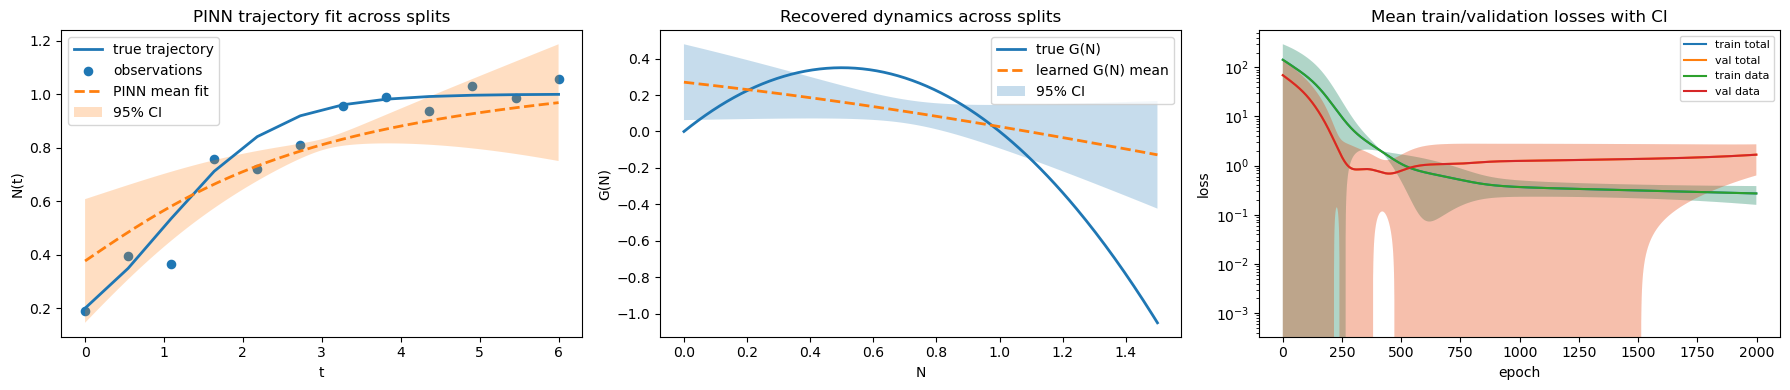

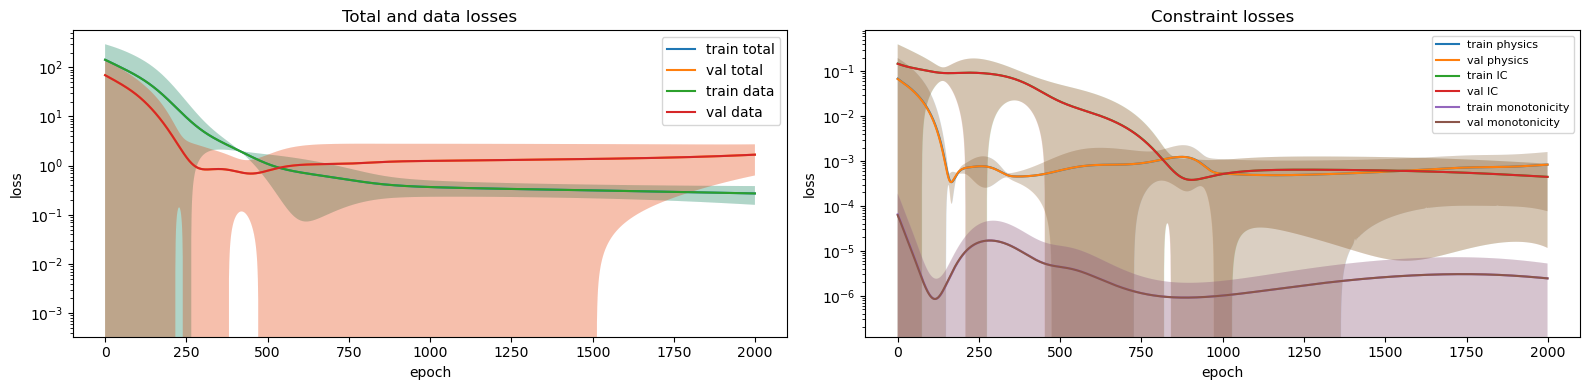

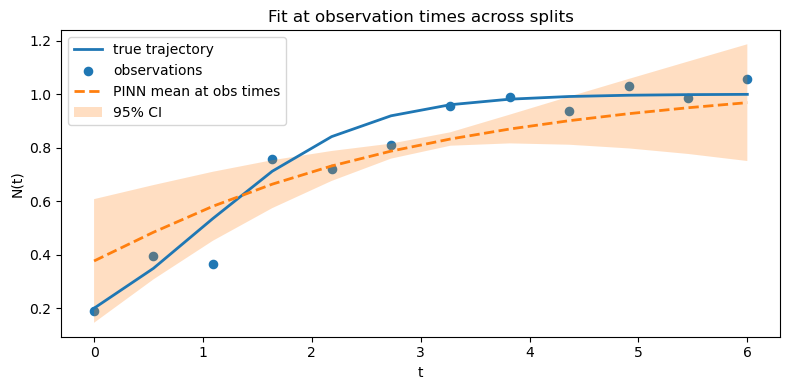


Summary across splits
---------------------
Number of splits: 3
Mean best validation loss: 5.558307e-03
Std  best validation loss: 9.617759e-03
Mean best epoch: 494.00
Std  best epoch: 230.53
Mean learned sigma_abs: 5.744315e-02
Std  learned sigma_abs: 3.034785e-03
Mean learned sigma_rel: 6.055900e-02
Std  learned sigma_rel: 5.892786e-03

Per-split best validation losses:
Split  1 | best val loss = 1.666394e-02 | best epoch = 273 | sigma_abs = 5.434538e-02 | sigma_rel = 6.320906e-02
Split  2 | best val loss = 1.042135e-05 | best epoch = 476 | sigma_abs = 5.757328e-02 | sigma_rel = 5.380646e-02
Split  3 | best val loss = 5.621465e-07 | best epoch = 733 | sigma_abs = 6.041077e-02 | sigma_rel = 6.466147e-02

Observed time points: mean prediction and 95% CI across split-best models
t =  0.000 | true =  0.20000 | data =  0.18799 | PINN mean =  0.37659 | 95% CI = [ 0.14561,  0.60757]
t =  0.545 | true =  0.34909 | data =  0.39388 | PINN mean =  0.48392 | 95% CI = [ 0.30769,  0.66015]
t =  1

In [221]:
import copy
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.2

t_obs = torch.linspace(0.0, 6.0, 12, device=device).view(-1, 1)  # (12,1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)  # (12,1)

noise_std = 0.05
torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true + noise_std * torch.randn_like(y_true)


# ============================================================
# 3. PINN components
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


# ============================================================
# 4. Helpers
# ============================================================
def mean_and_ci(arr, ci=1.96):
    """
    arr shape: (n_runs, n_points)
    returns mean, lower, upper
    """
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lower = mean.copy()
        upper = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lower = mean - ci * sem
        upper = mean + ci * sem
    return mean, lower, upper


def get_positive_scale(raw, eps=1e-6):
    return torch.nn.functional.softplus(raw) + eps


def hetero_gaussian_nll(y_pred, y_obs, raw_sigma_abs, raw_sigma_rel, eps=1e-6, detach_scale=False):
    """
    Heteroscedastic Gaussian NLL for additive + relative noise:

        Var(y | y_pred) = sigma_abs^2 + (sigma_rel * scale_base)^2

    where scale_base is y_pred by default. If detach_scale=True, then the variance
    uses y_pred.detach() to reduce the tendency to game the variance term.

    Returns mean NLL up to an additive constant:
        0.5 * [ (resid^2 / var) + log(var) ]
    """
    sigma_abs = get_positive_scale(raw_sigma_abs, eps=eps)
    sigma_rel = get_positive_scale(raw_sigma_rel, eps=eps)

    scale_base = y_pred.detach() if detach_scale else y_pred
    var = sigma_abs**2 + (sigma_rel * scale_base) ** 2 + eps
    resid2 = (y_obs - y_pred) ** 2

    return 0.5 * torch.mean(resid2 / var)# + torch.log(var))


# ============================================================
# 5. Experiment settings
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 2000
n_splits = 3

val_fraction = 0.1
n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_train = n_obs - n_val

lambda_phys = 1e-3
lambda_ic = 1.0
lambda_mon = 1.0

learning_rate = 1e-3
hidden_dim_sol = 4
hidden_dim_dyn = 4

# If True, the variance model uses y_pred.detach() rather than y_pred
detach_scale_in_nll = False

# evaluation grids
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.5, 200, device=device).view(-1, 1)

with torch.no_grad():
    G_grid_true = G_true(N_grid)

# containers across splits
train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_ic_histories = []
train_mon_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []
val_ic_histories = []
val_mon_histories = []

traj_histories = []        # N(t_plot)
rhs_histories = []         # G(N_grid)
obs_fit_histories = []     # N(t_obs)

best_val_losses = []
best_epochs = []
best_sigma_abs = []
best_sigma_rel = []

train_indices_all = []
val_indices_all = []


# ============================================================
# 6. Loop over train/validation splits
# ============================================================
for split in range(n_splits):
    # -------------------------
    # Split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    train_indices_all.append(train_idx.cpu().numpy())
    val_indices_all.append(val_idx.cpu().numpy())

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    # -------------------------
    # Fresh model for this split
    # -------------------------
    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    # Learn additive and relative noise scales
    raw_sigma_abs = nn.Parameter(torch.tensor(-3.0, dtype=torch.float32, device=device))
    raw_sigma_rel = nn.Parameter(torch.tensor(-3.0, dtype=torch.float32, device=device))

    optimizer = torch.optim.Adam(
        list(sol_net.parameters()) +
        list(dyn_net.parameters()) +
        [raw_sigma_abs, raw_sigma_rel],
        lr=learning_rate
    )

    # histories for this split
    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_ic_history = []
    train_mon_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []
    val_ic_history = []
    val_mon_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    # -------------------------
    # Training
    # -------------------------
    for epoch in range(n_epochs):
        optimizer.zero_grad()

        # Train data loss: learned additive + relative heteroscedastic NLL
        N_pred_train = sol_net(t_train)
        train_data_loss = hetero_gaussian_nll(
            N_pred_train,
            y_train,
            raw_sigma_abs,
            raw_sigma_rel,
            detach_scale=detach_scale_in_nll,
        )

        # IC loss
        t0 = torch.zeros((1, 1), device=device)
        N0_pred = sol_net(t0)
        ic_loss = torch.mean(
            (N0_pred - torch.tensor([[N0]], dtype=torch.float32, device=device)) ** 2
        )

        # Physics + monotonicity
        t_col = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col = sol_net(t_col)

        dN_dt = torch.autograd.grad(
            outputs=N_pred_col,
            inputs=t_col,
            grad_outputs=torch.ones_like(N_pred_col),
            create_graph=True,
            retain_graph=True,
        )[0]

        rhs_pred = dyn_net(N_pred_col)
        phys_res = dN_dt - rhs_pred
        phys_loss = torch.mean(phys_res ** 2)

        mon_violation = torch.relu(-dN_dt)
        mon_loss = torch.mean(mon_violation ** 2)

        # reg_loss = 1e-5 * sum((p ** 2).sum() for p in dyn_net.parameters())

        train_loss = (
            train_data_loss
            + lambda_phys * phys_loss
            # + lambda_ic * ic_loss
            # + lambda_mon * mon_loss
            # + reg_loss
        )

        train_loss.backward()
        optimizer.step()

        # Validation losses
        with torch.no_grad():
            N_pred_val = sol_net(t_val)
            val_data_loss = hetero_gaussian_nll(
                N_pred_val,
                y_val,
                raw_sigma_abs,
                raw_sigma_rel,
                detach_scale=detach_scale_in_nll,
            )

            N0_pred_val = sol_net(t0)
            val_ic_loss = torch.mean(
                (N0_pred_val - torch.tensor([[N0]], dtype=torch.float32, device=device)) ** 2
            )

        t_col_val = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col_val = sol_net(t_col_val)

        dN_dt_val = torch.autograd.grad(
            outputs=N_pred_col_val,
            inputs=t_col_val,
            grad_outputs=torch.ones_like(N_pred_col_val),
            create_graph=False,
            retain_graph=False,
        )[0]

        rhs_pred_val = dyn_net(N_pred_col_val)
        val_phys_res = dN_dt_val - rhs_pred_val
        val_phys_loss = torch.mean(val_phys_res ** 2)

        val_mon_violation = torch.relu(-dN_dt_val)
        val_mon_loss = torch.mean(val_mon_violation ** 2)

        # val_reg_loss = 1e-5 * sum((p ** 2).sum() for p in dyn_net.parameters())

        val_loss = (
            val_data_loss
            + lambda_phys * val_phys_loss
            # + lambda_ic * val_ic_loss
            # + lambda_mon * val_mon_loss
            # + val_reg_loss
        )

        # record
        train_total_history.append(train_loss.item())
        train_data_history.append(train_data_loss.item())
        train_phys_history.append(phys_loss.item())
        train_ic_history.append(ic_loss.item())
        train_mon_history.append(mon_loss.item())

        val_total_history.append(val_loss.item())
        val_data_history.append(val_data_loss.item())
        val_phys_history.append(val_phys_loss.item())
        val_ic_history.append(val_ic_loss.item())
        val_mon_history.append(val_mon_loss.item())

        # save best model on validation loss
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "raw_sigma_abs": raw_sigma_abs.detach().clone(),
                "raw_sigma_rel": raw_sigma_rel.detach().clone(),
            }

        if epoch % 1000 == 0:
            sigma_abs_now = get_positive_scale(raw_sigma_abs).item()
            sigma_rel_now = get_positive_scale(raw_sigma_rel).item()
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch:5d} | "
                f"TrainTot {train_loss.item():.6e} | "
                f"ValTot {val_loss.item():.6e} | "
                f"TrainData {train_data_loss.item():.6e} | "
                f"ValData {val_data_loss.item():.6e} | "
                f"sigma_abs {sigma_abs_now:.4e} | "
                f"sigma_rel {sigma_rel_now:.4e}",
                end="\r"
            )

    print(
        f"Split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best val loss = {best_val_loss:.6e} | "
        f"Best sigma_abs = {get_positive_scale(best_state['raw_sigma_abs']).item():.4e} | "
        f"Best sigma_rel = {get_positive_scale(best_state['raw_sigma_rel']).item():.4e}"
    )

    # restore best model for this split
    sol_net.load_state_dict(best_state["sol_net"])
    dyn_net.load_state_dict(best_state["dyn_net"])
    with torch.no_grad():
        raw_sigma_abs.copy_(best_state["raw_sigma_abs"])
        raw_sigma_rel.copy_(best_state["raw_sigma_rel"])

    # evaluate best model for this split
    with torch.no_grad():
        N_pinn = sol_net(t_plot)
        G_grid_learned = dyn_net(N_grid)
        N_fit_obs = sol_net(t_obs)

        sigma_abs_best = get_positive_scale(raw_sigma_abs).item()
        sigma_rel_best = get_positive_scale(raw_sigma_rel).item()

    # store
    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_ic_histories.append(train_ic_history)
    train_mon_histories.append(train_mon_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)
    val_ic_histories.append(val_ic_history)
    val_mon_histories.append(val_mon_history)

    traj_histories.append(N_pinn.squeeze(1).cpu().numpy())
    rhs_histories.append(G_grid_learned.squeeze(1).cpu().numpy())
    obs_fit_histories.append(N_fit_obs.squeeze(1).cpu().numpy())

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_sigma_abs.append(sigma_abs_best)
    best_sigma_rel.append(sigma_rel_best)


# ============================================================
# 7. Aggregate across splits
# ============================================================
train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_ic_histories = np.array(train_ic_histories)
train_mon_histories = np.array(train_mon_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)
val_ic_histories = np.array(val_ic_histories)
val_mon_histories = np.array(val_mon_histories)

traj_histories = np.array(traj_histories)       # (n_splits, n_tplot)
rhs_histories = np.array(rhs_histories)         # (n_splits, n_Ngrid)
obs_fit_histories = np.array(obs_fit_histories) # (n_splits, n_obs)

best_val_losses = np.array(best_val_losses)
best_epochs = np.array(best_epochs)
best_sigma_abs = np.array(best_sigma_abs)
best_sigma_rel = np.array(best_sigma_rel)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
train_phys_mean, train_phys_lo, train_phys_hi = mean_and_ci(train_phys_histories)
train_ic_mean, train_ic_lo, train_ic_hi = mean_and_ci(train_ic_histories)
train_mon_mean, train_mon_lo, train_mon_hi = mean_and_ci(train_mon_histories)

val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)
val_phys_mean, val_phys_lo, val_phys_hi = mean_and_ci(val_phys_histories)
val_ic_mean, val_ic_lo, val_ic_hi = mean_and_ci(val_ic_histories)
val_mon_mean, val_mon_lo, val_mon_hi = mean_and_ci(val_mon_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)


# ============================================================
# 8. Plot aggregate results with mean and CI bands
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# -------------------------
# Trajectory with CI
# -------------------------
axes[0].plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0].scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
axes[0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="PINN mean fit",
)
axes[0].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="95% CI",
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("N(t)")
axes[0].set_title("PINN trajectory fit across splits")
axes[0].legend()

# -------------------------
# Learned RHS with CI
# -------------------------
axes[1].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[1].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[1].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.25,
    label="95% CI",
)
axes[1].set_xlabel("N")
axes[1].set_ylabel("G(N)")
axes[1].set_title("Recovered dynamics across splits")
axes[1].legend()

# -------------------------
# Total/data losses with CI
# -------------------------
epochs = np.arange(n_epochs)

axes[2].plot(epochs, train_total_mean, label="train total")
axes[2].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[2].plot(epochs, val_total_mean, label="val total")
axes[2].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[2].plot(epochs, train_data_mean, label="train data")
axes[2].fill_between(epochs, train_data_lo, train_data_hi, alpha=0.20)

axes[2].plot(epochs, val_data_mean, label="val data")
axes[2].fill_between(epochs, val_data_lo, val_data_hi, alpha=0.20)

axes[2].set_yscale("log")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("loss")
axes[2].set_title("Mean train/validation losses with CI")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 9. Additional detailed loss plots with CI
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Total + data
axes[0].plot(epochs, train_total_mean, label="train total")
axes[0].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[0].plot(epochs, val_total_mean, label="val total")
axes[0].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[0].plot(epochs, train_data_mean, label="train data")
axes[0].fill_between(epochs, train_data_lo, train_data_hi, alpha=0.20)

axes[0].plot(epochs, val_data_mean, label="val data")
axes[0].fill_between(epochs, val_data_lo, val_data_hi, alpha=0.20)

axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Total and data losses")
axes[0].legend()

# Constraint losses
axes[1].plot(epochs, train_phys_mean, label="train physics")
axes[1].fill_between(epochs, train_phys_lo, train_phys_hi, alpha=0.20)

axes[1].plot(epochs, val_phys_mean, label="val physics")
axes[1].fill_between(epochs, val_phys_lo, val_phys_hi, alpha=0.20)

axes[1].plot(epochs, train_ic_mean, label="train IC")
axes[1].fill_between(epochs, train_ic_lo, train_ic_hi, alpha=0.20)

axes[1].plot(epochs, val_ic_mean, label="val IC")
axes[1].fill_between(epochs, val_ic_lo, val_ic_hi, alpha=0.20)

axes[1].plot(epochs, train_mon_mean, label="train monotonicity")
axes[1].fill_between(epochs, train_mon_lo, train_mon_hi, alpha=0.20)

axes[1].plot(epochs, val_mon_mean, label="val monotonicity")
axes[1].fill_between(epochs, val_mon_lo, val_mon_hi, alpha=0.20)

axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Constraint losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time fit with CI
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="PINN mean at obs times",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.25,
    label="95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("Fit at observation times across splits")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 11. Summary prints
# ============================================================
print("\nSummary across splits")
print("---------------------")
print(f"Number of splits: {n_splits}")
print(f"Mean best validation loss: {best_val_losses.mean():.6e}")
print(f"Std  best validation loss: {best_val_losses.std(ddof=1):.6e}")
print(f"Mean best epoch: {best_epochs.mean():.2f}")
print(f"Std  best epoch: {best_epochs.std(ddof=1):.2f}")
print(f"Mean learned sigma_abs: {best_sigma_abs.mean():.6e}")
print(f"Std  learned sigma_abs: {best_sigma_abs.std(ddof=1):.6e}")
print(f"Mean learned sigma_rel: {best_sigma_rel.mean():.6e}")
print(f"Std  learned sigma_rel: {best_sigma_rel.std(ddof=1):.6e}")

print("\nPer-split best validation losses:")
for i, (ve, ep, sa, sr) in enumerate(zip(best_val_losses, best_epochs, best_sigma_abs, best_sigma_rel), start=1):
    print(
        f"Split {i:2d} | "
        f"best val loss = {ve:.6e} | "
        f"best epoch = {ep} | "
        f"sigma_abs = {sa:.6e} | "
        f"sigma_rel = {sr:.6e}"
    )

print("\nObserved time points: mean prediction and 95% CI across split-best models")
for ti, yt, yd, mu, lo, hi in zip(
    t_obs.squeeze(1).cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    obs_fit_mean,
    obs_fit_lo,
    obs_fit_hi,
):
    print(
        f"t = {ti:6.3f} | "
        f"true = {yt:8.5f} | "
        f"data = {yd:8.5f} | "
        f"PINN mean = {mu:8.5f} | "
        f"95% CI = [{lo:8.5f}, {hi:8.5f}]"
    )

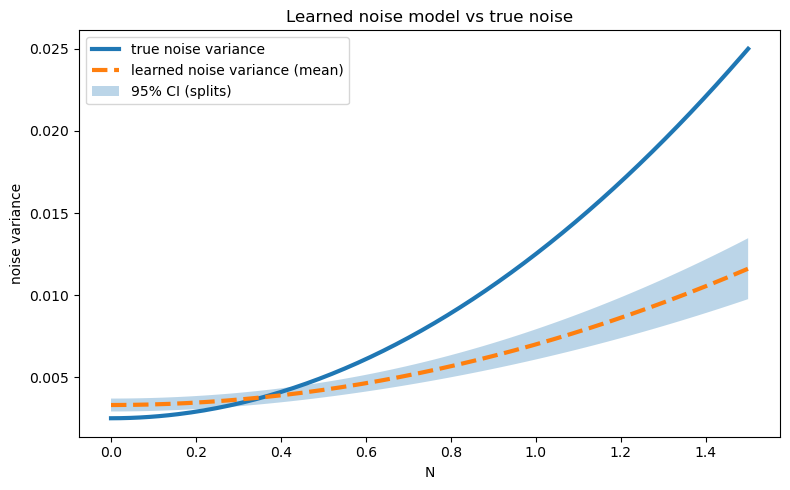

In [ ]:
# ============================================================
# Plot learned noise model vs true noise
# ============================================================

# true noise parameters from data generator
true_sigma_abs = noise_std
true_sigma_rel = 0.1

# compute learned noise curves across splits
learned_var_curves = []

for sa, sr in zip(best_sigma_abs, best_sigma_rel):
    var_curve = sa**2 + (sr * N_grid.squeeze(1).cpu().numpy())**2
    learned_var_curves.append(var_curve)

learned_var_curves = np.array(learned_var_curves)

var_mean, var_lo, var_hi = mean_and_ci(learned_var_curves)

# true variance curve
true_var = true_sigma_abs**2 + (true_sigma_rel * N_grid.squeeze(1).cpu().numpy())**2

plt.figure(figsize=(8,5))

plt.plot(
    N_grid.cpu().numpy(),
    true_var,
    label="true noise variance",
    linewidth=3
)

plt.plot(
    N_grid.cpu().numpy(),
    var_mean,
    "--",
    linewidth=3,
    label="learned noise variance (mean)"
)

plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    var_lo,
    var_hi,
    alpha=0.3,
    label="95% CI (splits)"
)

plt.xlabel("N")
plt.ylabel("noise variance")
plt.title("Learned noise model vs true noise")
plt.legend()
plt.tight_layout()
plt.show()

Split  1/2 done | Best epoch =    83 | Best val loss = 3.718768e-06 | Fixed y0 = 0.18799 | Best sigma_abs = 0.05067 | Best sigma_rel = 0.05203_rel 0.13279 | y0 0.18799
Split  2/2 done | Best epoch =  1232 | Best val loss = 4.755913e-08 | Fixed y0 = 0.18799 | Best sigma_abs = 0.05376 | Best sigma_rel = 0.07333_rel 0.22244 | y0 0.18799


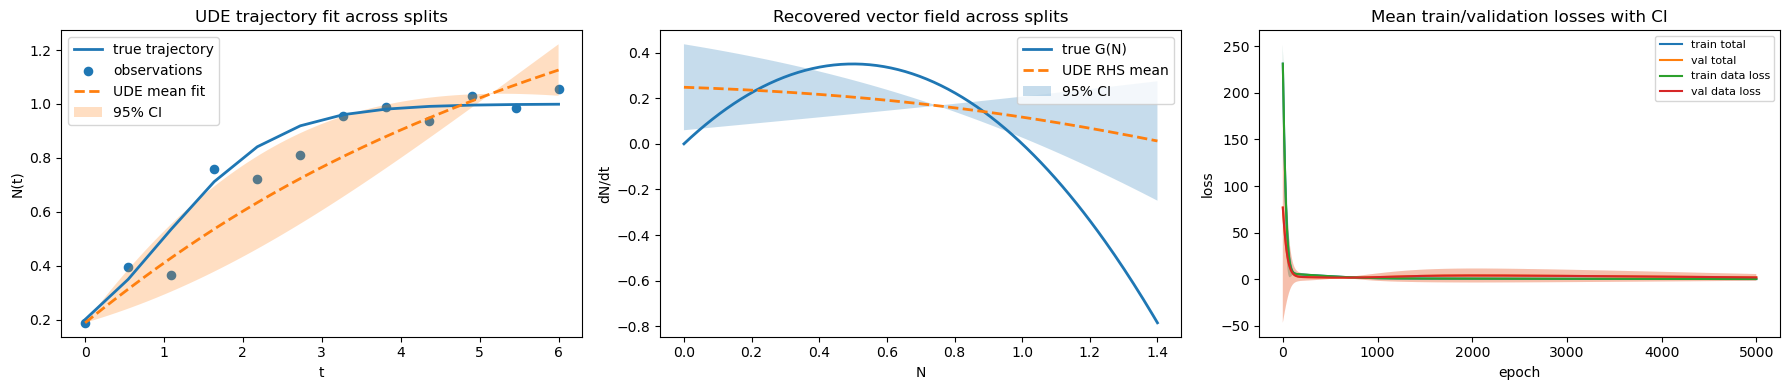

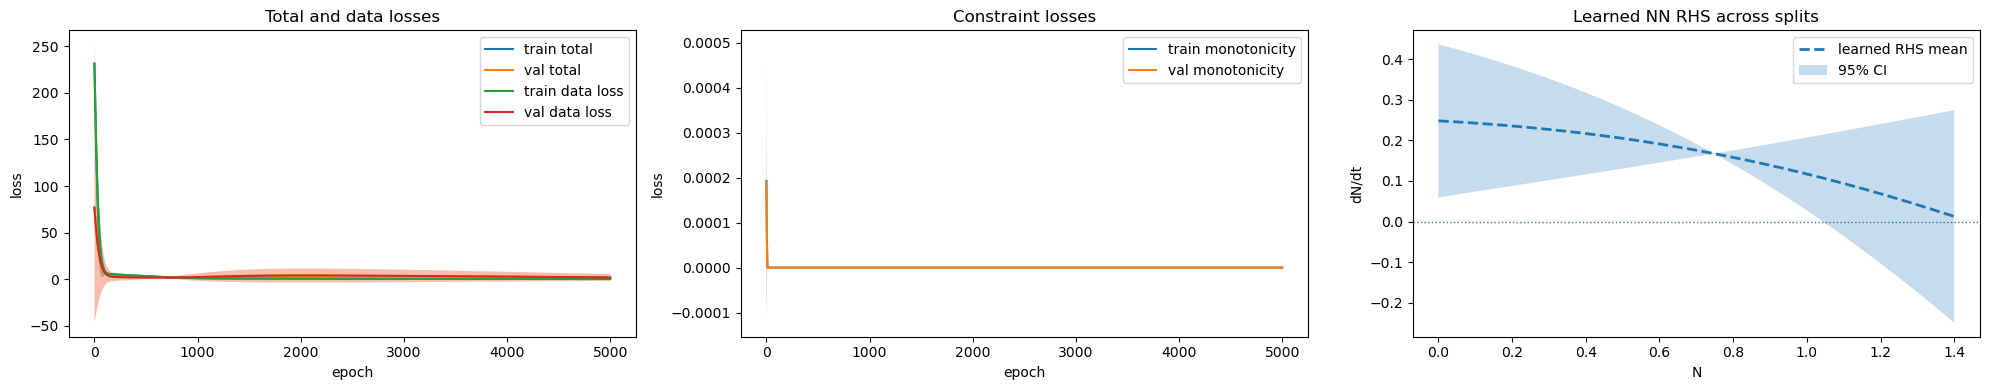

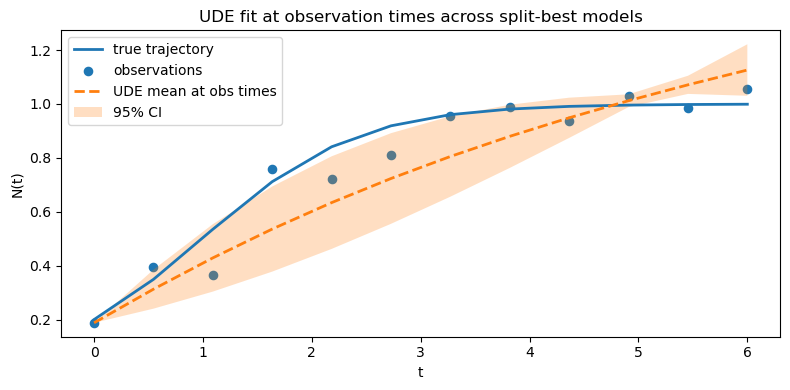

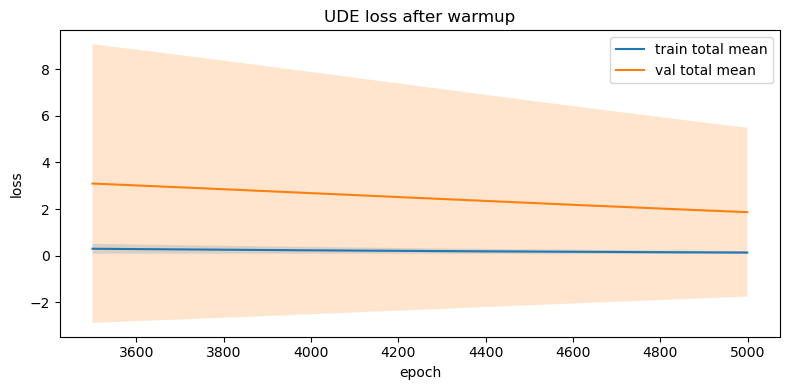

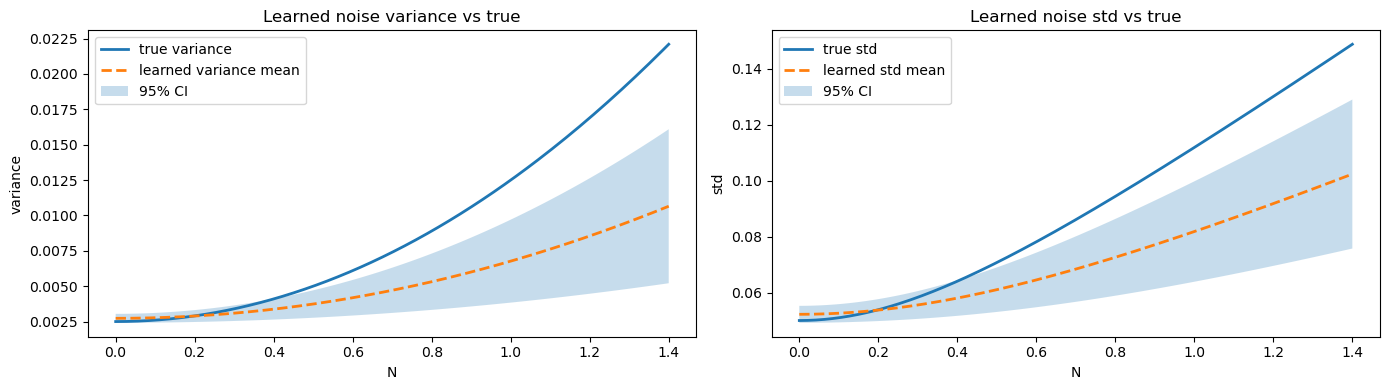

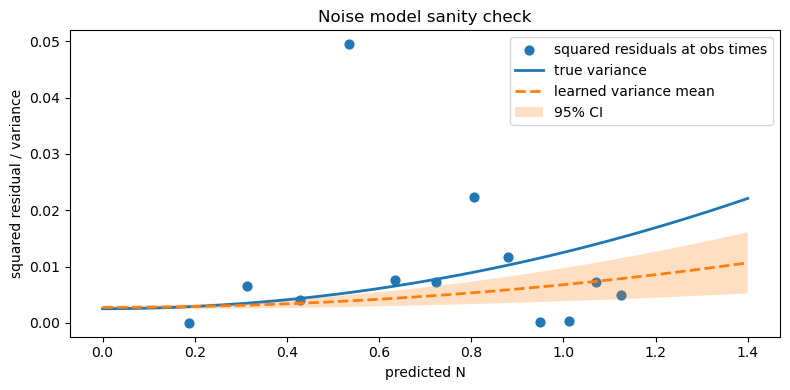


Summary across splits
---------------------
Number of splits: 2
Fixed initial condition y0 = first data point = 0.187986
Mean best validation loss: 1.883164e-06
Std  best validation loss: 2.595937e-06
Mean best epoch: 657.50
Std  best epoch: 812.47
Mean fixed y0 across splits: 0.187986
Std  fixed y0 across splits: 0.000000
Mean learned sigma_abs: 0.052214
Std  learned sigma_abs: 0.002185
Mean learned sigma_rel: 0.062680
Std  learned sigma_rel: 0.015055
True sigma_abs: 0.050000
True sigma_rel: 0.100000

Per-split best validation losses:
Split  1 | best val loss = 3.718768e-06 | best epoch =    83 | fixed y0 = 0.187986 | sigma_abs = 0.050669 | sigma_rel = 0.052035
Split  2 | best val loss = 4.755913e-08 | best epoch =  1232 | fixed y0 = 0.187986 | sigma_abs = 0.053759 | sigma_rel = 0.073325

Observed time points: mean prediction and 95% CI across split-best UDE models
t =  0.000 | true =  0.20000 | data =  0.18799 | UDE mean =  0.18799 | 95% CI = [ 0.18799,  0.18799] | learned dN/dt mea

In [223]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
#    (used only to generate synthetic data)
# ============================================================
r_true = 1.4
N0 = 0.2

# 12 observation times
t_obs = torch.linspace(0.0, 6.0, 12, device=device)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Differentiable RK4 ODE solver
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    """
    Integrate y' = f(t,y) over time grid t using RK4.
    y0 shape: (batch, dim) or (dim,)
    returns: tensor of shape (len(t), ...) matching y0
    """
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


# ============================================================
# 3. Simulate observed data from the true system
# ============================================================
with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)  # (1,1)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs)         # (T,1,1)
    y_true = y_true.squeeze(1)                                           # (T,1)

# Synthetic observation noise
true_sigma_abs = 0.05
true_sigma_rel = 0.10

torch.manual_seed(0)
y_data = y_true + true_sigma_rel * torch.randn_like(y_true) * y_true + true_sigma_abs * torch.randn_like(y_true)

# ------------------------------------------------------------
# Enforce the initial condition: first data point is exact truth
# ------------------------------------------------------------
y0_fixed = y_data[0:1].detach().clone()   # shape (1,1), fixed IC


# ============================================================
# 4. UDE model: FULL NN RHS ONLY
#    dN/dt = NN(N)
# ============================================================
class ResidualNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, y):
        return self.net(y)


class UDEFunc(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.rhs_net = ResidualNet(hidden_dim=hidden_dim)

    def forward(self, t, y):
        return self.rhs_net(y)


# ============================================================
# 5. Helpers
# ============================================================
def mean_and_ci(arr, ci=1.96):
    """
    arr shape: (n_runs, n_points)
    returns mean, lower, upper
    """
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lower = mean.copy()
        upper = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lower = mean - ci * sem
        upper = mean + ci * sem
    return mean, lower, upper


def detach_numpy(x):
    return x.detach().cpu().numpy()


def get_positive_scale(raw, eps=1e-6):
    return torch.nn.functional.softplus(raw) + eps


def weighted_data_loss(y_pred, y_obs, raw_sigma_abs, raw_sigma_rel, eps=1e-6, detach_scale=True):
    """
    Positive weighted least-squares loss for additive + relative noise:
        var(y|pred) = sigma_abs^2 + (sigma_rel * scale_base)^2

    This keeps the data loss positive and analogous to the heteroscedastic
    noise structure used in the PINN example, but without the log(var) term.
    """
    sigma_abs = get_positive_scale(raw_sigma_abs, eps=eps)
    sigma_rel = get_positive_scale(raw_sigma_rel, eps=eps)

    scale_base = y_pred.detach() if detach_scale else y_pred
    var = sigma_abs**2 + (sigma_rel * scale_base) ** 2 + eps
    resid2 = (y_obs - y_pred) ** 2
    return torch.mean(resid2 / var)


# ============================================================
# 6. Multi-split experiment settings
# ============================================================
n_splits = 2
val_fraction = 0.1

n_epochs = 5000
learning_rate = 1e-3

lambda_mon = 0.0   # set >0 only if you want monotonicity regularization
lambda_reg = 1e-4

hidden_dim = 4

n_obs = len(t_obs)

# ------------------------------------------------------------
# Exclude index 0 from fitting because it is now an exact IC
# ------------------------------------------------------------
all_idx = torch.arange(1, n_obs, device=device)
n_fit = len(all_idx)
n_val = int(round(val_fraction * n_fit))
n_train = n_fit - n_val

# evaluation grids
t_plot = torch.linspace(0.0, 6.0, 200, device=device)
N_grid = torch.linspace(
    0.0,
    1.4,
    200,
    device=device
).unsqueeze(1)

# storage across splits
train_total_histories = []
train_data_histories = []
train_mon_histories = []
train_reg_histories = []

val_total_histories = []
val_data_histories = []
val_mon_histories = []
val_reg_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []
rhs_fit_histories = []

best_val_losses = []
best_epochs = []
best_y0s = []
best_sigma_abs = []
best_sigma_rel = []

train_indices_all = []
val_indices_all = []


# ============================================================
# 7. Loop over train/validation splits
# ============================================================
for split in range(n_splits):
    # -------------------------
    # Split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm_local = torch.randperm(n_fit, generator=g, device=device)
    perm = all_idx[perm_local]

    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    train_indices_all.append(train_idx.cpu().numpy())
    val_indices_all.append(val_idx.cpu().numpy())

    y_train = y_data[train_idx]
    y_val = y_data[val_idx]

    # -------------------------
    # Fresh model for this split
    # -------------------------
    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    func = UDEFunc(hidden_dim=hidden_dim).to(device)

    # Fixed initial condition
    def get_y0():
        return y0_fixed

    # Learned additive and relative noise scales
    raw_sigma_abs = nn.Parameter(torch.tensor(-3.0, dtype=torch.float32, device=device))
    raw_sigma_rel = nn.Parameter(torch.tensor(-3.0, dtype=torch.float32, device=device))

    params = list(func.parameters()) + [raw_sigma_abs, raw_sigma_rel]
    optimizer = torch.optim.Adam(params, lr=learning_rate)

    # per-split histories
    train_total_history = []
    train_data_history = []
    train_mon_history = []
    train_reg_history = []

    val_total_history = []
    val_data_history = []
    val_mon_history = []
    val_reg_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    # -------------------------
    # Training
    # -------------------------
    for epoch in range(n_epochs):
        optimizer.zero_grad()

        y0_est = get_y0()

        # Predict full trajectory from the common initial time t_obs[0]
        y_pred_full = odeint_rk4(func, y0_est, t_obs).squeeze(1)   # (T_obs,1)

        # Restrict to train points for train loss
        y_pred_train = y_pred_full[train_idx]

        # Positive heteroscedastic weighted data loss
        train_data_loss = weighted_data_loss(
            y_pred_train, y_train, raw_sigma_abs, raw_sigma_rel, detach_scale=True
        )

        # Optional monotonicity penalty
        rhs_pred_full = func(t_obs.unsqueeze(1), y_pred_full)
        rhs_pred_train = rhs_pred_full[train_idx]
        train_mon_violation = torch.relu(-rhs_pred_train)
        train_mon_loss = torch.mean(train_mon_violation ** 2)

        # Regularization on neural RHS
        train_reg_loss = sum((p ** 2).sum() for p in func.parameters())

        train_loss = (
            train_data_loss
            # + lambda_mon * train_mon_loss
            # + lambda_reg * train_reg_loss
        )

        train_loss.backward()
        optimizer.step()

        # -------------------------
        # Validation loss
        # -------------------------
        with torch.no_grad():
            y0_est = get_y0()

            y_pred_full = odeint_rk4(func, y0_est, t_obs).squeeze(1)
            y_pred_val = y_pred_full[val_idx]

            val_data_loss = weighted_data_loss(
                y_pred_val, y_val, raw_sigma_abs, raw_sigma_rel, detach_scale=True
            )

            rhs_pred_full = func(t_obs.unsqueeze(1), y_pred_full)
            rhs_pred_val = rhs_pred_full[val_idx]
            val_mon_violation = torch.relu(-rhs_pred_val)
            val_mon_loss = torch.mean(val_mon_violation ** 2)

            val_reg_loss = sum((p ** 2).sum() for p in func.parameters())

            val_loss = (
                val_data_loss
                # + lambda_mon * val_mon_loss
                # + lambda_reg * val_reg_loss
            )

        # record histories
        train_total_history.append(train_loss.item())
        train_data_history.append(train_data_loss.item())
        train_mon_history.append(train_mon_loss.item())
        train_reg_history.append((lambda_reg * train_reg_loss).item())

        val_total_history.append(val_loss.item())
        val_data_history.append(val_data_loss.item())
        val_mon_history.append(val_mon_loss.item())
        val_reg_history.append((lambda_reg * val_reg_loss).item())

        # save best model based on minimum validation loss
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "func": copy.deepcopy(func.state_dict()),
                "raw_sigma_abs": raw_sigma_abs.detach().clone(),
                "raw_sigma_rel": raw_sigma_rel.detach().clone(),
            }

        if epoch % 500 == 0:
            sigma_abs_now = get_positive_scale(raw_sigma_abs).item()
            sigma_rel_now = get_positive_scale(raw_sigma_rel).item()
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch:5d} | "
                f"TrainTot {train_loss.item():.6e} | "
                f"ValTot {val_loss.item():.6e} | "
                f"TrainData {train_data_loss.item():.6e} | "
                f"ValData {val_data_loss.item():.6e} | "
                f"sig_abs {sigma_abs_now:.5f} | "
                f"sig_rel {sigma_rel_now:.5f} | "
                f"y0 {get_y0().item():.5f}",
                end="\r"
            )

    print(
        f"Split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best val loss = {best_val_loss:.6e} | "
        f"Fixed y0 = {y0_fixed.item():.5f} | "
        f"Best sigma_abs = {get_positive_scale(best_state['raw_sigma_abs']).item():.5f} | "
        f"Best sigma_rel = {get_positive_scale(best_state['raw_sigma_rel']).item():.5f}"
    )

    # restore best model
    func.load_state_dict(best_state["func"])
    with torch.no_grad():
        raw_sigma_abs.copy_(best_state["raw_sigma_abs"])
        raw_sigma_rel.copy_(best_state["raw_sigma_rel"])

    # evaluate best model from this split
    with torch.no_grad():
        y0_est = get_y0()

        y_fit_plot = odeint_rk4(func, y0_est, t_plot).squeeze(1)      # (200,1)
        y_fit_obs = odeint_rk4(func, y0_est, t_obs).squeeze(1)        # (12,1)

        G_grid_total = func(torch.tensor(0.0, device=device), N_grid)
        rhs_fit_obs = func(t_obs.unsqueeze(1), y_fit_obs)

        sigma_abs_est = get_positive_scale(raw_sigma_abs).item()
        sigma_rel_est = get_positive_scale(raw_sigma_rel).item()

    # save split results
    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_mon_histories.append(train_mon_history)
    train_reg_histories.append(train_reg_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_mon_histories.append(val_mon_history)
    val_reg_histories.append(val_reg_history)

    traj_histories.append(detach_numpy(y_fit_plot.squeeze(1)))
    rhs_histories.append(detach_numpy(G_grid_total.squeeze(1)))
    obs_fit_histories.append(detach_numpy(y_fit_obs.squeeze(1)))
    rhs_fit_histories.append(detach_numpy(rhs_fit_obs.squeeze(1)))

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_y0s.append(y0_est.item())
    best_sigma_abs.append(sigma_abs_est)
    best_sigma_rel.append(sigma_rel_est)


# ============================================================
# 8. Aggregate across splits
# ============================================================
train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_mon_histories = np.array(train_mon_histories)
train_reg_histories = np.array(train_reg_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_mon_histories = np.array(val_mon_histories)
val_reg_histories = np.array(val_reg_histories)

traj_histories = np.array(traj_histories)
rhs_histories = np.array(rhs_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_fit_histories = np.array(rhs_fit_histories)

best_val_losses = np.array(best_val_losses)
best_epochs = np.array(best_epochs)
best_y0s = np.array(best_y0s)
best_sigma_abs = np.array(best_sigma_abs)
best_sigma_rel = np.array(best_sigma_rel)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
train_mon_mean, train_mon_lo, train_mon_hi = mean_and_ci(train_mon_histories)

val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)
val_mon_mean, val_mon_lo, val_mon_hi = mean_and_ci(val_mon_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)
rhs_fit_mean, rhs_fit_lo, rhs_fit_hi = mean_and_ci(rhs_fit_histories)


# ============================================================
# 9. Plot aggregate results with mean and CI bands
# ============================================================
epochs = np.arange(n_epochs)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Trajectory with CI
axes[0].plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0].scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
axes[0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="UDE mean fit",
)
axes[0].fill_between(
    t_plot.cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="95% CI",
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("N(t)")
axes[0].set_title("UDE trajectory fit across splits")
axes[0].legend()

# Learned RHS with CI
axes[1].plot(
    N_grid.cpu().numpy(),
    G_true(N_grid).squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[1].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="UDE RHS mean",
)
axes[1].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.25,
    label="95% CI",
)
axes[1].set_xlabel("N")
axes[1].set_ylabel("dN/dt")
axes[1].set_title("Recovered vector field across splits")
axes[1].legend()

# Total/data losses with CI
axes[2].plot(epochs, train_total_mean, label="train total")
axes[2].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[2].plot(epochs, val_total_mean, label="val total")
axes[2].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[2].plot(epochs, train_data_mean, label="train data loss")
axes[2].fill_between(epochs, train_data_lo, train_data_hi, alpha=0.20)

axes[2].plot(epochs, val_data_mean, label="val data loss")
axes[2].fill_between(epochs, val_data_lo, val_data_hi, alpha=0.20)

axes[2].set_xlabel("epoch")
axes[2].set_ylabel("loss")
axes[2].set_title("Mean train/validation losses with CI")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Additional detailed plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# Total + data losses
axes[0].plot(epochs, train_total_mean, label="train total")
axes[0].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[0].plot(epochs, val_total_mean, label="val total")
axes[0].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[0].plot(epochs, train_data_mean, label="train data loss")
axes[0].fill_between(epochs, train_data_lo, train_data_hi, alpha=0.20)

axes[0].plot(epochs, val_data_mean, label="val data loss")
axes[0].fill_between(epochs, val_data_lo, val_data_hi, alpha=0.20)

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Total and data losses")
axes[0].legend()

# Monotonicity loss
axes[1].plot(epochs, train_mon_mean, label="train monotonicity")
axes[1].fill_between(epochs, train_mon_lo, train_mon_hi, alpha=0.20)

axes[1].plot(epochs, val_mon_mean, label="val monotonicity")
axes[1].fill_between(epochs, val_mon_lo, val_mon_hi, alpha=0.20)

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Constraint losses")
axes[1].legend()

# RHS plot
axes[2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned RHS mean",
)
axes[2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.25,
    label="95% CI",
)
axes[2].axhline(0.0, linestyle=":", linewidth=1)
axes[2].set_xlabel("N")
axes[2].set_ylabel("dN/dt")
axes[2].set_title("Learned NN RHS across splits")
axes[2].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 11. Observation-time fit with CI
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="UDE mean at obs times",
)
plt.fill_between(
    t_obs.cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.25,
    label="95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("UDE fit at observation times across split-best models")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 12. Late-epoch loss plot
# ============================================================
warmup = min(3500, n_epochs - 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs[warmup:], train_total_mean[warmup:], label="train total mean")
plt.fill_between(
    epochs[warmup:],
    train_total_lo[warmup:],
    train_total_hi[warmup:],
    alpha=0.20,
)
plt.plot(epochs[warmup:], val_total_mean[warmup:], label="val total mean")
plt.fill_between(
    epochs[warmup:],
    val_total_lo[warmup:],
    val_total_hi[warmup:],
    alpha=0.20,
)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("UDE loss after warmup")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 13. Learned noise plot
# ============================================================
learned_var_curves = []
learned_std_curves = []

N_grid_np = N_grid.squeeze(1).cpu().numpy()

for sa, sr in zip(best_sigma_abs, best_sigma_rel):
    var_curve = sa**2 + (sr * N_grid_np) ** 2
    std_curve = np.sqrt(var_curve)
    learned_var_curves.append(var_curve)
    learned_std_curves.append(std_curve)

learned_var_curves = np.array(learned_var_curves)
learned_std_curves = np.array(learned_std_curves)

var_mean, var_lo, var_hi = mean_and_ci(learned_var_curves)
std_mean, std_lo, std_hi = mean_and_ci(learned_std_curves)

true_var = true_sigma_abs**2 + (true_sigma_rel * N_grid_np) ** 2
true_std = np.sqrt(true_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Variance plot
axes[0].plot(N_grid_np, true_var, linewidth=2, label="true variance")
axes[0].plot(N_grid_np, var_mean, "--", linewidth=2, label="learned variance mean")
axes[0].fill_between(N_grid_np, var_lo, var_hi, alpha=0.25, label="95% CI")
axes[0].set_xlabel("N")
axes[0].set_ylabel("variance")
axes[0].set_title("Learned noise variance vs true")
axes[0].legend()

# Standard deviation plot
axes[1].plot(N_grid_np, true_std, linewidth=2, label="true std")
axes[1].plot(N_grid_np, std_mean, "--", linewidth=2, label="learned std mean")
axes[1].fill_between(N_grid_np, std_lo, std_hi, alpha=0.25, label="95% CI")
axes[1].set_xlabel("N")
axes[1].set_ylabel("std")
axes[1].set_title("Learned noise std vs true")
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 14. Residual-based noise sanity check
# ============================================================
plt.figure(figsize=(8, 4))
residual_sq = (y_data[:, 0].cpu().numpy() - obs_fit_mean) ** 2

plt.scatter(
    obs_fit_mean,
    residual_sq,
    s=40,
    label="squared residuals at obs times"
)
plt.plot(N_grid_np, true_var, linewidth=2, label="true variance")
plt.plot(N_grid_np, var_mean, "--", linewidth=2, label="learned variance mean")
plt.fill_between(N_grid_np, var_lo, var_hi, alpha=0.25, label="95% CI")
plt.xlabel("predicted N")
plt.ylabel("squared residual / variance")
plt.title("Noise model sanity check")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 15. Summary prints
# ============================================================
print("\nSummary across splits")
print("---------------------")
print(f"Number of splits: {n_splits}")
print(f"Fixed initial condition y0 = first data point = {y0_fixed.item():.6f}")
print(f"Mean best validation loss: {best_val_losses.mean():.6e}")
print(f"Std  best validation loss: {best_val_losses.std(ddof=1):.6e}")
print(f"Mean best epoch: {best_epochs.mean():.2f}")
print(f"Std  best epoch: {best_epochs.std(ddof=1):.2f}")
print(f"Mean fixed y0 across splits: {best_y0s.mean():.6f}")
print(f"Std  fixed y0 across splits: {best_y0s.std(ddof=1):.6f}")
print(f"Mean learned sigma_abs: {best_sigma_abs.mean():.6f}")
print(f"Std  learned sigma_abs: {best_sigma_abs.std(ddof=1):.6f}")
print(f"Mean learned sigma_rel: {best_sigma_rel.mean():.6f}")
print(f"Std  learned sigma_rel: {best_sigma_rel.std(ddof=1):.6f}")
print(f"True sigma_abs: {true_sigma_abs:.6f}")
print(f"True sigma_rel: {true_sigma_rel:.6f}")

print("\nPer-split best validation losses:")
for i, (ve, ep, y0i, sa, sr) in enumerate(
    zip(best_val_losses, best_epochs, best_y0s, best_sigma_abs, best_sigma_rel), start=1
):
    print(
        f"Split {i:2d} | "
        f"best val loss = {ve:.6e} | "
        f"best epoch = {ep:5d} | "
        f"fixed y0 = {y0i:.6f} | "
        f"sigma_abs = {sa:.6f} | "
        f"sigma_rel = {sr:.6f}"
    )

print("\nObserved time points: mean prediction and 95% CI across split-best UDE models")
for ti, yt, yd, mu, lo, hi, gp, gplo, gphi in zip(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    obs_fit_mean,
    obs_fit_lo,
    obs_fit_hi,
    rhs_fit_mean,
    rhs_fit_lo,
    rhs_fit_hi,
):
    print(
        f"t = {ti:6.3f} | "
        f"true = {yt:8.5f} | "
        f"data = {yd:8.5f} | "
        f"UDE mean = {mu:8.5f} | "
        f"95% CI = [{lo:8.5f}, {hi:8.5f}] | "
        f"learned dN/dt mean = {gp:8.5f} | "
        f"95% CI = [{gplo:8.5f}, {gphi:8.5f}]"
    )

Split  1/5 done | Best epoch =  3263 | Best val loss = 8.334527e+00 | Best sigma_abs = 0.69315 | Best sigma_rel = 0.05774
Split  2/5 done | Best epoch =  3999 | Best val loss = 2.673924e+01 | Best sigma_abs = 0.69315 | Best sigma_rel = 0.06117
Split  3/5 done | Best epoch =  3999 | Best val loss = 4.045312e+00 | Best sigma_abs = 0.69315 | Best sigma_rel = 0.05521
Split  4/5 done | Best epoch =  1034 | Best val loss = 1.296925e+01 | Best sigma_abs = 0.69315 | Best sigma_rel = 0.05170
Split  5/5 done | Best epoch =  3999 | Best val loss = 4.173099e+00 | Best sigma_abs = 0.69315 | Best sigma_rel = 0.06496


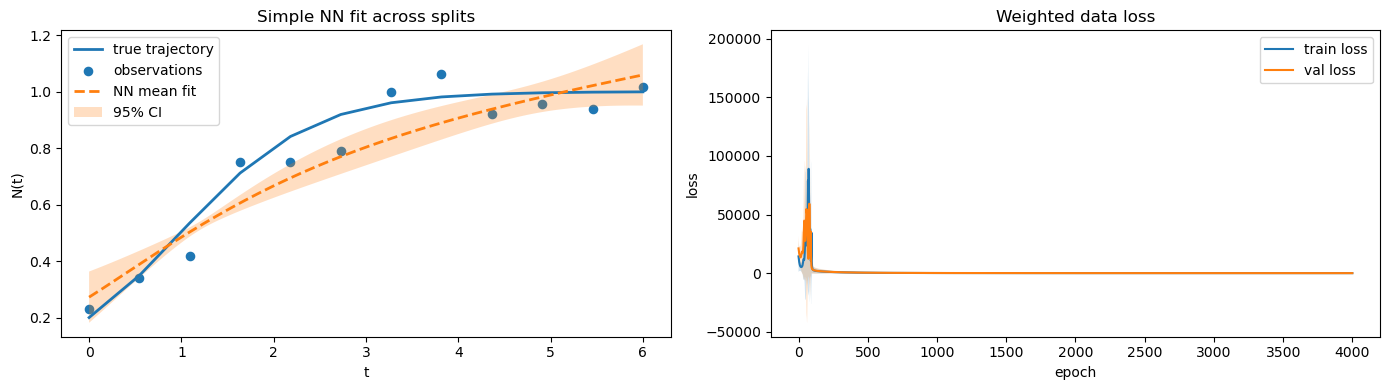

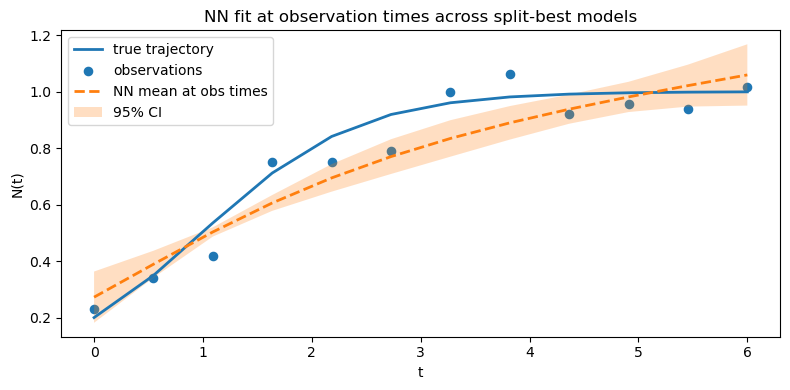

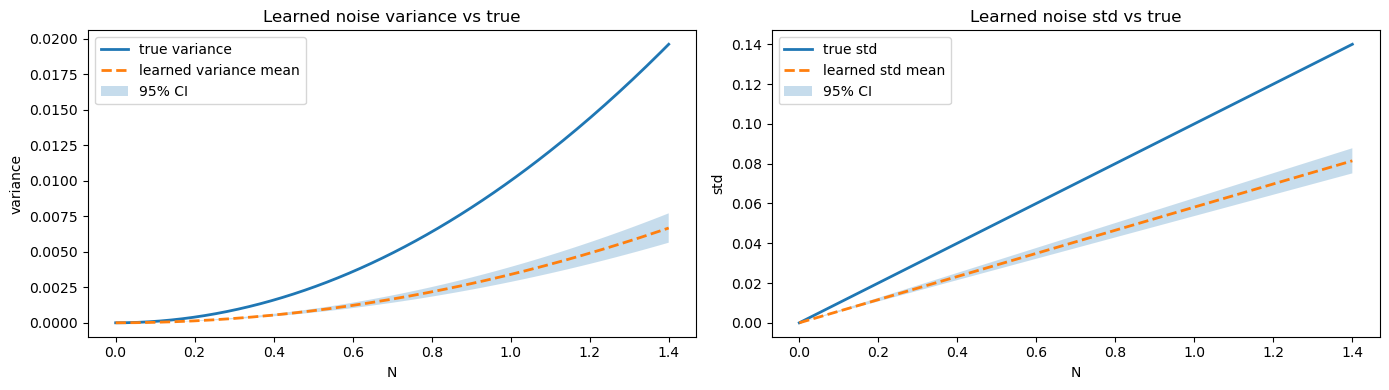


Summary across splits
---------------------
Number of splits: 5
Mean best validation loss: 1.125229e+01
Std  best validation loss: 9.398968e+00
Mean best epoch: 3258.80
Std  best epoch: 1283.88
Mean learned sigma_abs: 0.693148
Std  learned sigma_abs: 0.000000
Mean learned sigma_rel: 0.058155
Std  learned sigma_rel: 0.005148
True sigma_abs: 0.000000
True sigma_rel: 0.100000

Per-split best validation losses:
Split  1 | best val loss = 8.334527e+00 | best epoch =  3263 | sigma_abs = 0.693148 | sigma_rel = 0.057737
Split  2 | best val loss = 2.673924e+01 | best epoch =  3999 | sigma_abs = 0.693148 | sigma_rel = 0.061174
Split  3 | best val loss = 4.045312e+00 | best epoch =  3999 | sigma_abs = 0.693148 | sigma_rel = 0.055206
Split  4 | best val loss = 1.296925e+01 | best epoch =  1034 | sigma_abs = 0.693148 | sigma_rel = 0.051697
Split  5 | best val loss = 4.173099e+00 | best epoch =  3999 | sigma_abs = 0.693148 | sigma_rel = 0.064959


In [271]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system (used only to generate synthetic data)
# ============================================================
r_true = 1.4
N0 = 0.2

t_obs = torch.linspace(0.0, 6.0, 12, device=device).view(-1, 1)  # (12,1)

def G_true(N):
    return r_true * N * (1.0 - N)

def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)  # (12,1)

# Synthetic observation noise:
# y = y_true + sigma_rel * eps1 * y_true + sigma_abs * eps2
true_sigma_abs = 0.0
true_sigma_rel = 0.10

torch.manual_seed(0)
y_data = y_true + true_sigma_rel * torch.randn_like(y_true) * y_true + true_sigma_abs * torch.randn_like(y_true)


# ============================================================
# 2. Simple NN regressor for N(t) only
#    No PINN / no UDE / no physics regularisation
# ============================================================
class DataFitNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)


# ============================================================
# 3. Helpers
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.asarray(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lower = mean.copy()
        upper = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lower = mean - ci * sem
        upper = mean + ci * sem
    return mean, lower, upper


def detach_numpy(x):
    return x.detach().cpu().numpy()


def get_positive_scale(raw, eps=1e-6):
    return torch.nn.functional.softplus(raw) + eps


def weighted_data_loss(y_pred, y_obs, raw_sigma_abs, raw_sigma_rel, eps=1e-6, detach_scale=True):
    """
    Positive heteroscedastic weighted least-squares loss:
        var = sigma_abs^2 + (sigma_rel * y_pred)^2
        loss = mean((y_obs - y_pred)^2 / var)
    """
    #sigma_abs = get_positive_scale(raw_sigma_abs, eps=eps)
    sigma_rel = get_positive_scale(raw_sigma_rel, eps=eps)

    scale_base = y_pred.detach() if detach_scale else y_pred
    #var = sigma_abs**2 + (sigma_rel * scale_base) ** 2 + eps
    var =  (sigma_rel * scale_base) ** 2 + eps
    resid2 = (y_obs - y_pred) ** 2
    return torch.mean(resid2 / var)


# ============================================================
# 4. Experiment settings
# ============================================================
n_splits = 5
val_fraction = 0.5

n_epochs = 4000
learning_rate = 1e-3
hidden_dim = 4

n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_train = n_obs - n_val

t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.4, 200, device=device).view(-1, 1)

# storage across splits
train_total_histories = []
train_data_histories = []

val_total_histories = []
val_data_histories = []

traj_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_sigma_abs = []
best_sigma_rel = []

train_indices_all = []
val_indices_all = []


# ============================================================
# 5. Loop over train/validation splits
# ============================================================
for split in range(n_splits):
    # -------------------------
    # Split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    train_indices_all.append(train_idx.cpu().numpy())
    val_indices_all.append(val_idx.cpu().numpy())

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    # -------------------------
    # Fresh model for this split
    # -------------------------
    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    net = DataFitNet(hidden_dim=hidden_dim).to(device)

    raw_sigma_abs = nn.Parameter(torch.tensor(-3.0, dtype=torch.float32, device=device))
    raw_sigma_rel = nn.Parameter(torch.tensor(-3.0, dtype=torch.float32, device=device))

    optimizer = torch.optim.Adam(
        list(net.parameters()) + [raw_sigma_rel],
        lr=learning_rate,
    )

    # per-split histories
    train_total_history = []
    train_data_history = []

    val_total_history = []
    val_data_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    # -------------------------
    # Training
    # -------------------------
    for epoch in range(n_epochs):
        optimizer.zero_grad()

        y_pred_train = net(t_train)
        train_data_loss = weighted_data_loss(
            y_pred_train, y_train, raw_sigma_abs, raw_sigma_rel, detach_scale=True
        )
        train_loss = train_data_loss

        train_loss.backward()
        optimizer.step()

        # validation
        with torch.no_grad():
            y_pred_val = net(t_val)
            val_data_loss = weighted_data_loss(
                y_pred_val, y_val, raw_sigma_abs, raw_sigma_rel, detach_scale=True
            )
            val_loss = val_data_loss

        train_total_history.append(train_loss.item())
        train_data_history.append(train_data_loss.item())

        val_total_history.append(val_loss.item())
        val_data_history.append(val_data_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "net": copy.deepcopy(net.state_dict()),
                "raw_sigma_abs": raw_sigma_abs.detach().clone()*0,
                "raw_sigma_rel": raw_sigma_rel.detach().clone(),
            }

        if epoch % 500 == 0:
            sigma_abs_now = get_positive_scale(raw_sigma_abs).item()*0
            sigma_rel_now = get_positive_scale(raw_sigma_rel).item()
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch:5d} | "
                f"Train {train_loss.item():.6e} | "
                f"Val {val_loss.item():.6e} | "
                f"sigma_abs {sigma_abs_now:.5f} | "
                f"sigma_rel {sigma_rel_now:.5f}",
                end="\r"
            )

    print(
        f"Split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best val loss = {best_val_loss:.6e} | "
        f"Best sigma_abs = {get_positive_scale(best_state['raw_sigma_abs']).item():.5f} | "
        f"Best sigma_rel = {get_positive_scale(best_state['raw_sigma_rel']).item():.5f}"
    )

    # restore best model
    net.load_state_dict(best_state["net"])
    with torch.no_grad():
        raw_sigma_abs.copy_(best_state["raw_sigma_abs"])
        raw_sigma_rel.copy_(best_state["raw_sigma_rel"])

        y_fit_plot = net(t_plot)
        y_fit_obs = net(t_obs)

        sigma_abs_est = get_positive_scale(raw_sigma_abs).item()
        sigma_rel_est = get_positive_scale(raw_sigma_rel).item()

    # store results
    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)

    traj_histories.append(detach_numpy(y_fit_plot.squeeze(1)))
    obs_fit_histories.append(detach_numpy(y_fit_obs.squeeze(1)))

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_sigma_abs.append(sigma_abs_est)
    best_sigma_rel.append(sigma_rel_est)


# ============================================================
# 6. Aggregate across splits
# ============================================================
train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)

best_val_losses = np.array(best_val_losses)
best_epochs = np.array(best_epochs)
best_sigma_abs = np.array(best_sigma_abs)
best_sigma_rel = np.array(best_sigma_rel)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)

val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)


# ============================================================
# 7. Plots
# ============================================================
epochs = np.arange(n_epochs)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# trajectory fit
axes[0].plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0].scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
axes[0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="NN mean fit",
)
axes[0].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="95% CI",
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("N(t)")
axes[0].set_title("Simple NN fit across splits")
axes[0].legend()

# train/val losses
axes[1].plot(epochs, train_total_mean, label="train loss")
axes[1].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[1].plot(epochs, val_total_mean, label="val loss")
axes[1].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Weighted data loss")
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 8. Observation-time fit with CI
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="NN mean at obs times",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.25,
    label="95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("NN fit at observation times across split-best models")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 9. Learned noise vs true noise
# ============================================================
learned_var_curves = []
learned_std_curves = []

N_grid_np = N_grid.squeeze(1).cpu().numpy()

for sa, sr in zip(best_sigma_abs, best_sigma_rel):
    var_curve = (sr * N_grid_np) ** 2
    std_curve = np.sqrt(var_curve)
    learned_var_curves.append(var_curve)
    learned_std_curves.append(std_curve)

learned_var_curves = np.array(learned_var_curves)
learned_std_curves = np.array(learned_std_curves)

var_mean, var_lo, var_hi = mean_and_ci(learned_var_curves)
std_mean, std_lo, std_hi = mean_and_ci(learned_std_curves)

true_var = true_sigma_abs**2 + (true_sigma_rel * N_grid_np) ** 2
true_std = np.sqrt(true_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(N_grid_np, true_var, linewidth=2, label="true variance")
axes[0].plot(N_grid_np, var_mean, "--", linewidth=2, label="learned variance mean")
axes[0].fill_between(N_grid_np, var_lo, var_hi, alpha=0.25, label="95% CI")
axes[0].set_xlabel("N")
axes[0].set_ylabel("variance")
axes[0].set_title("Learned noise variance vs true")
axes[0].legend()

axes[1].plot(N_grid_np, true_std, linewidth=2, label="true std")
axes[1].plot(N_grid_np, std_mean, "--", linewidth=2, label="learned std mean")
axes[1].fill_between(N_grid_np, std_lo, std_hi, alpha=0.25, label="95% CI")
axes[1].set_xlabel("N")
axes[1].set_ylabel("std")
axes[1].set_title("Learned noise std vs true")
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 10. Summary
# ============================================================
print("\nSummary across splits")
print("---------------------")
print(f"Number of splits: {n_splits}")
print(f"Mean best validation loss: {best_val_losses.mean():.6e}")
print(f"Std  best validation loss: {best_val_losses.std(ddof=1):.6e}")
print(f"Mean best epoch: {best_epochs.mean():.2f}")
print(f"Std  best epoch: {best_epochs.std(ddof=1):.2f}")
print(f"Mean learned sigma_abs: {best_sigma_abs.mean():.6f}")
print(f"Std  learned sigma_abs: {best_sigma_abs.std(ddof=1):.6f}")
print(f"Mean learned sigma_rel: {best_sigma_rel.mean():.6f}")
print(f"Std  learned sigma_rel: {best_sigma_rel.std(ddof=1):.6f}")
print(f"True sigma_abs: {true_sigma_abs:.6f}")
print(f"True sigma_rel: {true_sigma_rel:.6f}")

print("\nPer-split best validation losses:")
for i, (ve, ep, sa, sr) in enumerate(
    zip(best_val_losses, best_epochs, best_sigma_abs, best_sigma_rel), start=1
):
    print(
        f"Split {i:2d} | "
        f"best val loss = {ve:.6e} | "
        f"best epoch = {ep:5d} | "
        f"sigma_abs = {sa:.6f} | "
        f"sigma_rel = {sr:.6f}"
    )

Split  1/3 done | Best epoch =  7282 | Best val loss = 4.233732e-01+00 | Data 3.067511e-01 | Mon 1.818494e-03 | SigFit 2.864387e-06 | sigma_max(obs) 0.06303
Split  2/3 done | Best epoch =  1232 | Best val loss = 5.213097e-01+00 | Data 3.440679e-01 | Mon 6.210178e-04 | SigFit 2.227613e-06 | sigma_max(obs) 0.08046
Split  3/3 done | Best epoch =  4300 | Best val loss = 8.394200e-01+00 | Data 3.518972e-01 | Mon 1.582448e-04 | SigFit 1.852956e-06 | sigma_max(obs) 0.07419


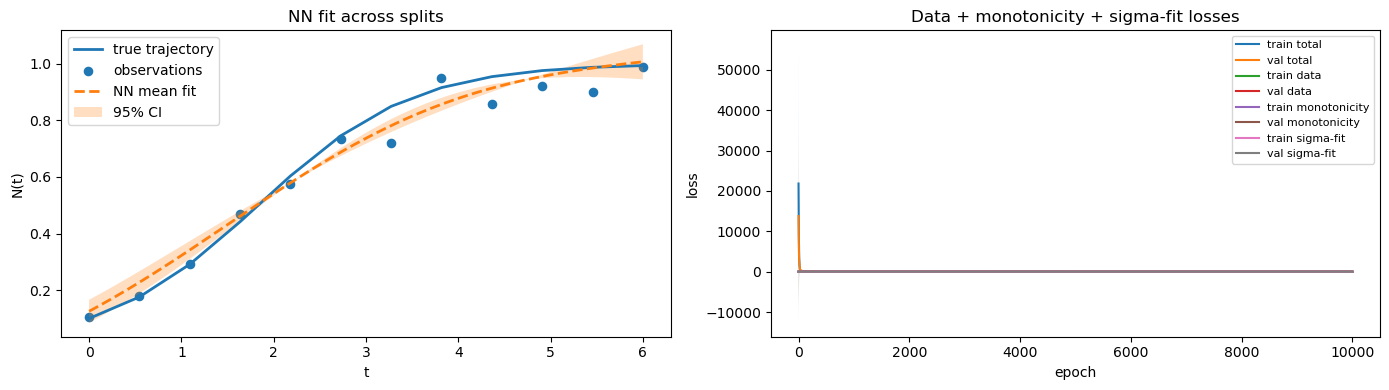

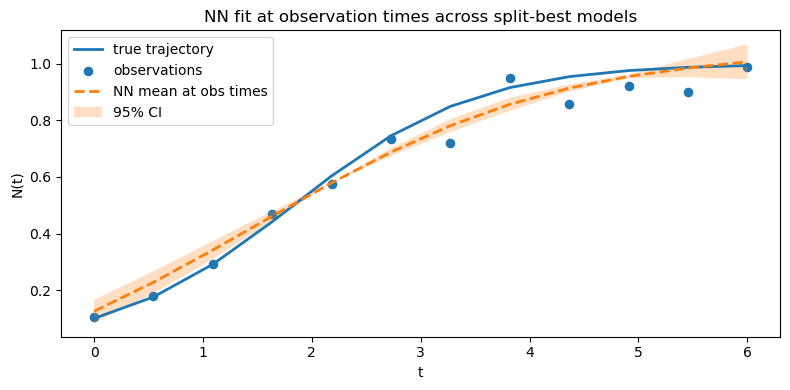

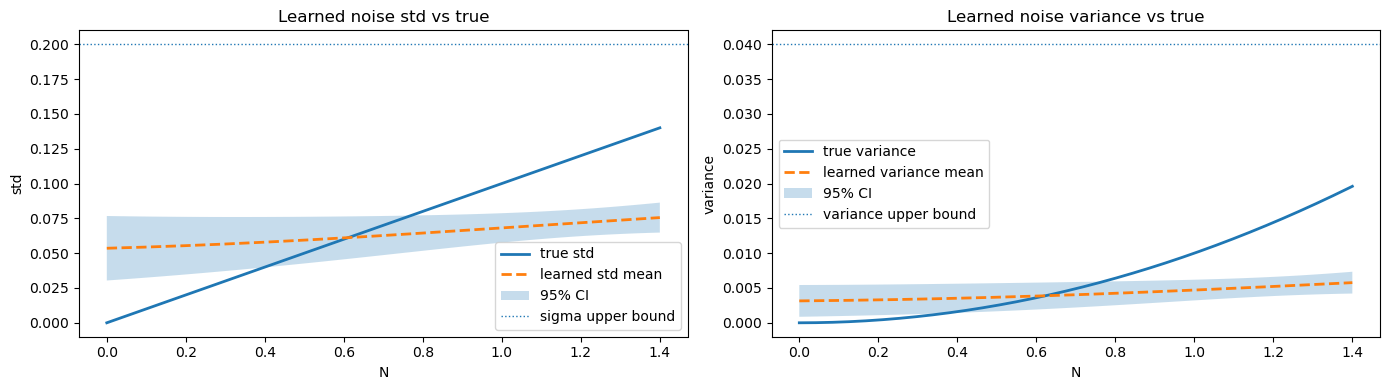

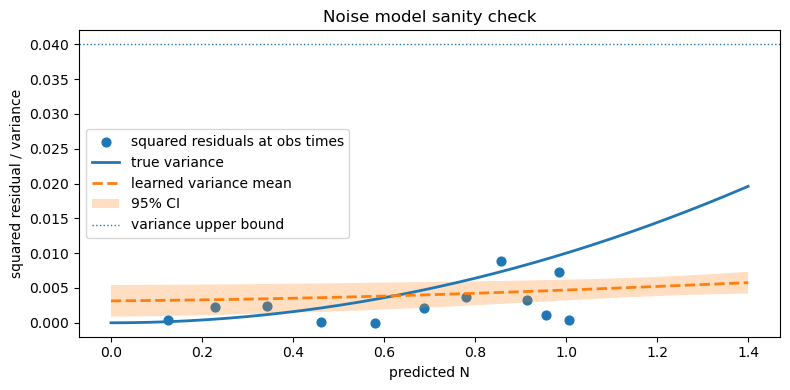


Summary across splits
---------------------
Number of splits: 3
Mean best validation loss: 5.947010e-01
Std  best validation loss: 2.175165e-01
Mean best epoch: 4271.33
Std  best epoch: 3025.10
Mean max learned sigma over N-grid: 0.075539
Std  max learned sigma over N-grid: 0.009505
Final mean train monotonicity loss: 8.822754e-04
Final mean val monotonicity loss: 8.821817e-04
Final mean train sigma-fit loss: 2.214555e-06
Final mean val sigma-fit loss: 1.286730e-05
True sigma_abs: 0.000000
True sigma_rel: 0.100000
Sigma upper bound enforced: 0.200000

Per-split best validation losses:
Split  1 | best val loss = 4.233732e-01 | best epoch =  7282 | max sigma on N-grid = 0.081315
Split  2 | best val loss = 5.213097e-01 | best epoch =  1232 | max sigma on N-grid = 0.080734
Split  3 | best val loss = 8.394200e-01 | best epoch =  4300 | max sigma on N-grid = 0.064568


In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system (used only to generate synthetic data)
# ============================================================
r_true = 1.2
N0 = 0.1

t_obs = torch.linspace(0.0, 6.0, 12, device=device).view(-1, 1)  # (12,1)

def G_true(N):
    return r_true * N * (1.0 - N)

def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)  # (12,1)

# Synthetic observation noise:
# y = y_true + sigma_rel * eps1 * y_true + sigma_abs * eps2
true_sigma_abs = 0.0
true_sigma_rel = 0.10

torch.manual_seed(1)
y_data = y_true + true_sigma_rel * torch.randn_like(y_true) * y_true + true_sigma_abs * torch.randn_like(y_true)


# ============================================================
# 2. Simple NN regressor for N(t)
# ============================================================
class DataFitNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)


# ============================================================
# 3. Tiny NN for learning bounded noise scale sigma(y_pred)
#    sigma is constrained to (0, sigma_max)
# ============================================================
class NoiseNet(nn.Module):
    def __init__(self, hidden_dim=8, sigma_max=0.2, sigma_min=1e-4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

        self.sigma_max = sigma_max
        self.sigma_min = sigma_min

    def forward(self, y):
        raw = self.net(y)
        sigma = self.sigma_min + (self.sigma_max - self.sigma_min) * torch.sigmoid(raw)
        return sigma


# ============================================================
# 4. Helpers
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.asarray(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lower = mean.copy()
        upper = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lower = mean - ci * sem
        upper = mean + ci * sem
    return mean, lower, upper


def detach_numpy(x):
    return x.detach().cpu().numpy()


def gaussian_nll_with_learned_sigma(y_pred, y_obs, sigma_pred, eps=1e-6):
    """
    Gaussian NLL using a learned positive sigma(y_pred):
        0.5 * mean( resid^2 / var + log(var) )
    """
    var = sigma_pred**2 + eps
    resid2 = (y_obs - y_pred) ** 2
    return 0.5 * torch.mean(resid2 / var)# + torch.log(var))


def sigma_residual_fit_loss(y_pred, y_obs, sigma_pred):
    """
    Encourage sigma_pred^2 to match empirical squared residual.
    """
    resid2 = (y_obs - y_pred) ** 2
    var_pred = sigma_pred ** 2
    return torch.mean((var_pred - resid2) ** 2)


def monotonicity_penalty(net, t_grid):
    """
    Penalize negative derivative dN/dt < 0.
    """
    t_req = t_grid.clone().detach().requires_grad_(True)
    y_pred = net(t_req)
    dy_dt = torch.autograd.grad(
        outputs=y_pred,
        inputs=t_req,
        grad_outputs=torch.ones_like(y_pred),
        create_graph=True,
        retain_graph=True,
    )[0]
    violation = torch.relu(-dy_dt)
    return torch.sum(violation ** 2), dy_dt


# ============================================================
# 5. Experiment settings
# ============================================================
n_splits = 3
val_fraction = 0.2

n_epochs = 10000
learning_rate = 1e-3
hidden_dim = 8
noise_hidden_dim = 4

lambda_mon = 10.0
lambda_sigma_fit = 1e5
n_mon_grid = 200

n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_train = n_obs - n_val

t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
t_mon_base = torch.linspace(0.0, 6.0, n_mon_grid, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.4, 200, device=device).view(-1, 1)

# storage across splits
train_total_histories = []
train_data_histories = []
train_mon_histories = []
train_sigma_fit_histories = []

val_total_histories = []
val_data_histories = []
val_mon_histories = []
val_sigma_fit_histories = []

traj_histories = []
obs_fit_histories = []
noise_histories = []

best_val_losses = []
best_epochs = []
best_sigma_max_obs = []

train_indices_all = []
val_indices_all = []


# ============================================================
# 6. Loop over train/validation splits
# ============================================================
for split in range(n_splits):
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    train_indices_all.append(train_idx.cpu().numpy())
    val_indices_all.append(val_idx.cpu().numpy())

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    net = DataFitNet(hidden_dim=hidden_dim).to(device)
    noise_net = NoiseNet(hidden_dim=noise_hidden_dim, sigma_max=0.2, sigma_min=1e-4).to(device)

    optimizer = torch.optim.Adam(
        list(net.parameters()) + list(noise_net.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_mon_history = []
    train_sigma_fit_history = []

    val_total_history = []
    val_data_history = []
    val_mon_history = []
    val_sigma_fit_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        y_pred_train = net(t_train)
        sigma_pred_train = noise_net(y_pred_train.detach())

        train_data_loss = gaussian_nll_with_learned_sigma(
            y_pred_train, y_train, sigma_pred_train
        )
        train_sigma_fit_loss = sigma_residual_fit_loss(
            y_pred_train, y_train, sigma_pred_train
        )
        train_mon_loss, _ = monotonicity_penalty(net, t_mon_base)

        train_loss = (
            train_data_loss
            + lambda_mon * train_mon_loss
            + lambda_sigma_fit * train_sigma_fit_loss
        )

        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            y_pred_val = net(t_val)
            sigma_pred_val = noise_net(y_pred_val.detach())

            val_data_loss = gaussian_nll_with_learned_sigma(
                y_pred_val, y_val, sigma_pred_val
            )
            val_sigma_fit_loss = sigma_residual_fit_loss(
                y_pred_val, y_val, sigma_pred_val
            )

        val_mon_loss, _ = monotonicity_penalty(net, t_mon_base)

        val_loss = (
            val_data_loss
            + lambda_mon * val_mon_loss
            + lambda_sigma_fit * val_sigma_fit_loss
        )

        train_total_history.append(train_loss.item())
        train_data_history.append(train_data_loss.item())
        train_mon_history.append(train_mon_loss.item())
        train_sigma_fit_history.append(train_sigma_fit_loss.item())

        val_total_history.append(val_loss.item())
        val_data_history.append(val_data_loss.item())
        val_mon_history.append(val_mon_loss.item())
        val_sigma_fit_history.append(val_sigma_fit_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "net": copy.deepcopy(net.state_dict()),
                "noise_net": copy.deepcopy(noise_net.state_dict()),
            }

        if epoch % 500 == 0:
            with torch.no_grad():
                sigma_train_now = noise_net(y_pred_train.detach())
                sigma_train_max = sigma_train_now.max().item()
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch:5d} | "
                f"TrainTot {train_loss.item():.6e} | "
                f"ValTot {val_loss.item():.6e} | "
                f"Data {train_data_loss.item():.6e} | "
                f"Mon {train_mon_loss.item():.6e} | "
                f"SigFit {train_sigma_fit_loss.item():.6e} | "
                f"sigma_max(obs) {sigma_train_max:.5f}",
                end="\r"
            )

    print(
        f"Split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best val loss = {best_val_loss:.6e}"
    )

    net.load_state_dict(best_state["net"])
    noise_net.load_state_dict(best_state["noise_net"])

    with torch.no_grad():
        y_fit_plot = net(t_plot)
        y_fit_obs = net(t_obs)
        sigma_plot = noise_net(N_grid)
        sigma_max_est = sigma_plot.max().item()

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_mon_histories.append(train_mon_history)
    train_sigma_fit_histories.append(train_sigma_fit_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_mon_histories.append(val_mon_history)
    val_sigma_fit_histories.append(val_sigma_fit_history)

    traj_histories.append(detach_numpy(y_fit_plot.squeeze(1)))
    obs_fit_histories.append(detach_numpy(y_fit_obs.squeeze(1)))
    noise_histories.append(detach_numpy(sigma_plot.squeeze(1)))

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_sigma_max_obs.append(sigma_max_est)


# ============================================================
# 7. Aggregate across splits
# ============================================================
train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_mon_histories = np.array(train_mon_histories)
train_sigma_fit_histories = np.array(train_sigma_fit_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_mon_histories = np.array(val_mon_histories)
val_sigma_fit_histories = np.array(val_sigma_fit_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
noise_histories = np.array(noise_histories)

best_val_losses = np.array(best_val_losses)
best_epochs = np.array(best_epochs)
best_sigma_max_obs = np.array(best_sigma_max_obs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
train_mon_mean, train_mon_lo, train_mon_hi = mean_and_ci(train_mon_histories)
train_sigma_fit_mean, train_sigma_fit_lo, train_sigma_fit_hi = mean_and_ci(train_sigma_fit_histories)

val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)
val_mon_mean, val_mon_lo, val_mon_hi = mean_and_ci(val_mon_histories)
val_sigma_fit_mean, val_sigma_fit_lo, val_sigma_fit_hi = mean_and_ci(val_sigma_fit_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)

noise_mean, noise_lo, noise_hi = mean_and_ci(noise_histories)

N_grid_np = N_grid.squeeze(1).cpu().numpy()
true_sigma_curve = np.sqrt(true_sigma_abs**2 + (true_sigma_rel * N_grid_np) ** 2)
true_var_curve = true_sigma_abs**2 + (true_sigma_rel * N_grid_np) ** 2
learned_var_histories = noise_histories**2
var_mean, var_lo, var_hi = mean_and_ci(learned_var_histories)


# ============================================================
# 8. Plots
# ============================================================
epochs = np.arange(n_epochs)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0].scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
axes[0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="NN mean fit",
)
axes[0].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="95% CI",
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("N(t)")
axes[0].set_title("NN fit across splits")
axes[0].legend()

axes[1].plot(epochs, train_total_mean, label="train total")
axes[1].fill_between(epochs, train_total_lo, train_total_hi, alpha=0.20)

axes[1].plot(epochs, val_total_mean, label="val total")
axes[1].fill_between(epochs, val_total_lo, val_total_hi, alpha=0.20)

axes[1].plot(epochs, train_data_mean, label="train data")
axes[1].fill_between(epochs, train_data_lo, train_data_hi, alpha=0.20)

axes[1].plot(epochs, val_data_mean, label="val data")
axes[1].fill_between(epochs, val_data_lo, val_data_hi, alpha=0.20)

axes[1].plot(epochs, train_mon_mean, label="train monotonicity")
axes[1].fill_between(epochs, train_mon_lo, train_mon_hi, alpha=0.20)

axes[1].plot(epochs, val_mon_mean, label="val monotonicity")
axes[1].fill_between(epochs, val_mon_lo, val_mon_hi, alpha=0.20)

axes[1].plot(epochs, train_sigma_fit_mean, label="train sigma-fit")
axes[1].fill_between(epochs, train_sigma_fit_lo, train_sigma_fit_hi, alpha=0.20)

axes[1].plot(epochs, val_sigma_fit_mean, label="val sigma-fit")
axes[1].fill_between(epochs, val_sigma_fit_lo, val_sigma_fit_hi, alpha=0.20)

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Data + monotonicity + sigma-fit losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 9. Observation-time fit with CI
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="NN mean at obs times",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.25,
    label="95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("NN fit at observation times across split-best models")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 10. Learned noise vs true noise
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(N_grid_np, true_sigma_curve, linewidth=2, label="true std")
axes[0].plot(N_grid_np, noise_mean, "--", linewidth=2, label="learned std mean")
axes[0].fill_between(N_grid_np, noise_lo, noise_hi, alpha=0.25, label="95% CI")
axes[0].axhline(0.2, linestyle=":", linewidth=1, label="sigma upper bound")
axes[0].set_xlabel("N")
axes[0].set_ylabel("std")
axes[0].set_title("Learned noise std vs true")
axes[0].legend()

axes[1].plot(N_grid_np, true_var_curve, linewidth=2, label="true variance")
axes[1].plot(N_grid_np, var_mean, "--", linewidth=2, label="learned variance mean")
axes[1].fill_between(N_grid_np, var_lo, var_hi, alpha=0.25, label="95% CI")
axes[1].axhline(0.2**2, linestyle=":", linewidth=1, label="variance upper bound")
axes[1].set_xlabel("N")
axes[1].set_ylabel("variance")
axes[1].set_title("Learned noise variance vs true")
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 11. Residual/noise sanity check
# ============================================================
plt.figure(figsize=(8, 4))
residual_sq = (y_data[:, 0].cpu().numpy() - obs_fit_mean) ** 2

plt.scatter(
    obs_fit_mean,
    residual_sq,
    s=40,
    label="squared residuals at obs times"
)
plt.plot(N_grid_np, true_var_curve, linewidth=2, label="true variance")
plt.plot(N_grid_np, var_mean, "--", linewidth=2, label="learned variance mean")
plt.fill_between(N_grid_np, var_lo, var_hi, alpha=0.25, label="95% CI")
plt.axhline(0.2**2, linestyle=":", linewidth=1, label="variance upper bound")
plt.xlabel("predicted N")
plt.ylabel("squared residual / variance")
plt.title("Noise model sanity check")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nSummary across splits")
print("---------------------")
print(f"Number of splits: {n_splits}")
print(f"Mean best validation loss: {best_val_losses.mean():.6e}")
print(f"Std  best validation loss: {best_val_losses.std(ddof=1):.6e}")
print(f"Mean best epoch: {best_epochs.mean():.2f}")
print(f"Std  best epoch: {best_epochs.std(ddof=1):.2f}")
print(f"Mean max learned sigma over N-grid: {best_sigma_max_obs.mean():.6f}")
print(f"Std  max learned sigma over N-grid: {best_sigma_max_obs.std(ddof=1):.6f}")
print(f"Final mean train monotonicity loss: {train_mon_mean[-1]:.6e}")
print(f"Final mean val monotonicity loss: {val_mon_mean[-1]:.6e}")
print(f"Final mean train sigma-fit loss: {train_sigma_fit_mean[-1]:.6e}")
print(f"Final mean val sigma-fit loss: {val_sigma_fit_mean[-1]:.6e}")
print(f"True sigma_abs: {true_sigma_abs:.6f}")
print(f"True sigma_rel: {true_sigma_rel:.6f}")
print(f"Sigma upper bound enforced: 0.200000")

print("\nPer-split best validation losses:")
for i, (ve, ep, sm) in enumerate(
    zip(best_val_losses, best_epochs, best_sigma_max_obs), start=1
):
    print(
        f"Split {i:2d} | "
        f"best val loss = {ve:.6e} | "
        f"best epoch = {ep:5d} | "
        f"max sigma on N-grid = {sm:.6f}"
    )

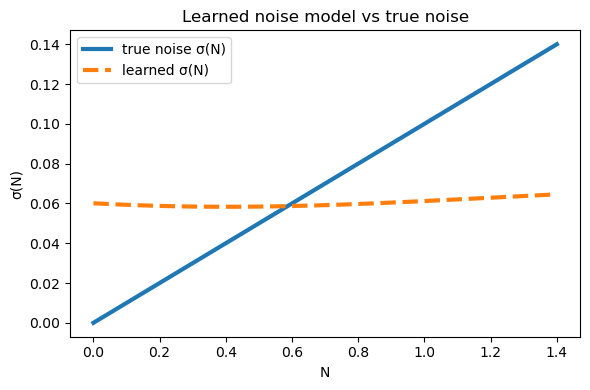

In [267]:
# ============================================================
# Plot learned sigma(N) vs true sigma(N)
# ============================================================

# Grid of N values
N_plot = torch.linspace(0.0, 1.4, 200, device=device).view(-1, 1)

with torch.no_grad():
    sigma_learned = noise_net(N_plot).cpu().numpy().squeeze()

N_plot_np = N_plot.cpu().numpy().squeeze()

# True noise model used to generate the data
sigma_true = np.sqrt(true_sigma_abs**2 + (true_sigma_rel * N_plot_np)**2)

plt.figure(figsize=(6,4))

plt.plot(
    N_plot_np,
    sigma_true,
    linewidth=3,
    label="true noise σ(N)"
)

plt.plot(
    N_plot_np,
    sigma_learned,
    "--",
    linewidth=3,
    label="learned σ(N)"
)

plt.xlabel("N")
plt.ylabel("σ(N)")
plt.title("Learned noise model vs true noise")
plt.legend()
plt.tight_layout()
plt.show()